# 7 · Classification — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch07_classification/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 7.Q1 à 7.Q11, 7.R1 à 7.R3, 7.1 à 7.6 | vérifier tes réponses courtes | 🧠 🔁 ✏️ ∂ | ★ à ★★★ | |
| A | 7.11 | Des œufs en 2D : données, régions et frontière de décision | 📦 | ★ | 15 |
|  | 7.12 | k-means sur deux lunes : où tombera la coupure ? | 🔮 | ★ | 10 |
|  | 7.13 | Distances au carré vectorisées : pairwise_sq_distances | 🔨 | ★★ | 20 |
|  | 7.14 | Le classifieur du centroïde le plus proche | 🔨 | ★★ | 30 |
|  | 7.15 | Carte de probabilité et politique de seuil pour les œufs | 📈 | ★★ | 25 |
|  | 7.16 | Un-contre-tous avec des centroïdes : quelle classe sera sacrifiée ? | 🔮 | ★★ | 15 |
| B | 7.17 | Manchots sans labels : k-means face aux espèces | 📦 | ★★ | 25 |
|  | 7.18 | Formes arbitraires et bruit : DBSCAN et HDBSCAN | 📦 | ★★ | 25 |
|  | 7.19 | Distance au plus proche voisin quand la dimension grimpe | 🔮 | ★★ | 15 |
|  | 7.20 | Densité, plus proche voisin et concentration des distances | 🔬 | ★★ | 30 |
|  | 7.21 | Reproduire les figures 7.27 et 7.30 (boule/cube, hyper-orange) | 🎨 | ★★ | 25 |
| C | 7.22 | Un-contre-tous générique : OneVsRestClassifier | 🔨 | ★★★ | 40 |
|  | 7.23 | Un-contre-un générique : OneVsOneClassifier | 🔨 | ★★★ | 45 |
|  | 7.24 | OvR, OvO ou multi-classe natif : accuracy, nombre de modèles, temps | 🔬 | ★★★ | 35 |
| D | 7.25 | Initialisation k-means++ | 🔨 | ★★★ | 35 |
|  | 7.26 | k-means de Lloyd : la classe KMeans | 🔨 | ★★★★ | 120 |
|  | 7.27 | k-means piégé : quatre bugs à débusquer | 🐛 | ★★★ | 30 |
|  | 7.28 | Coefficient de silhouette | 🔨 | ★★★ | 40 |
|  | 7.29 | Choisir k : coude de l'inertie et silhouette, de k = 2 à 7 | 🔬 | ★★★ | 35 |
|  | 7.30 | Phénomène de Hughes : des features de bruit qui font chuter l'accuracy | 🔬 | ★★★ | 40 |
|  | 7.31 | Défi : retrouver les espèces de manchots sans labels | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        conflicts = subprocess.run(["git", "-C", str(DRIVE_DIR), "diff", "--name-only", "--diff-filter=U"],
                                   capture_output=True, text=True).stdout.split()
        if conflicts:  # a file changed outside mon_travail/ AND by Claude: git leaves conflict markers in it
            print("⚠️ Tes modifications de " + ", ".join(conflicts) + " (hors de mon_travail/) entrent en conflit "
                  "avec la nouvelle version ; elles sont gardées dans `git stash`. Pour reprendre la version du "
                  "dépôt : git restore --source=HEAD --staged --worktree <fichier> (00_setup/COLAB.md, « Problèmes "
                  "fréquents »).")
        elif pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Lire des régions et des frontières de décision, et régler un seuil d'après le coût des erreurs.
- Traiter plusieurs classes avec des classifieurs binaires : un-contre-tous et un-contre-un.
- Programmer le centroïde le plus proche et k-means (Lloyd, k-means++), et choisir $k$ avec l'inertie et la silhouette ; savoir quand préférer DBSCAN ou HDBSCAN.
- Mesurer ce que la dimension fait aux densités et aux distances.

**Rappel express.** $N_{\text{OvR}} = K$, $N_{\text{OvO}} = \frac{K(K-1)}{2}$ ; seuil de coût minimal $t^* = \frac{C_{FP}}{C_{FP} + C_{FN}}$ ; $\lVert \mathbf{a} - \mathbf{b} \rVert^2 = \lVert \mathbf{a} \rVert^2 - 2\,\mathbf{a} \cdot \mathbf{b} + \lVert \mathbf{b} \rVert^2$ ; inertie $J = \sum_i \lVert \mathbf{x}_i - \boldsymbol{\mu}_{c_i} \rVert^2$ ; silhouette $s = \frac{b - a}{\max(a, b)}$ ; densité $\rho = \frac{n}{b^d}$ ; peau d'une boule $1 - (1 - \varepsilon)^d$. En Python : `sklearn.cluster.KMeans`, `DBSCAN`, `HDBSCAN`, `sklearn.metrics.silhouette_score`, `sklearn.multiclass`, `rng.choice(n, p=w / w.sum())`.

## Partie 0 · Vérifier tes réponses courtes (quiz, rappels, ✏️ 7.1 à 7.4, ∂ 7.5 et 7.6)

Fais d'abord les quiz, les rappels et les exercices de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse courte ici : **la valeur** que tu as trouvée, pas l'expression Python, sinon tu ne vérifies rien. Un nombre : `42` ou `0.375` (en Python, le séparateur décimal est un **point** ; `0,375` sans guillemets serait un couple de deux nombres) ; un vrai ou faux : `True` ou `False` ; un choix : la lettre seule, entre guillemets (`"D"`) ; plusieurs nombres : une liste (`[2, 5]`). Arrondis comme l'énoncé le demande, et seulement à la fin du calcul. Les réponses pas encore remplies affichent ⏳. Les questions « dans ta copie », le quiz Q10, ∂ 7.7, la réflexion et l'entretien se corrigent avec `05_solutions.md`.

In [2]:
# The short answers only use the numbers of their statements (02_exercices.md)
import math

import numpy as np


def entropy_bits(p):
    """Entropy in bits of a distribution (counts or proportions), with 0 log 0 = 0."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0] / p.sum()
    return float(-(p * np.log2(p)).sum())


def posterior(prior, f1, f0):
    """Bayes rule for two classes: P(class 1 | x) from the prior and the two densities at x."""
    return prior * f1 / (prior * f1 + (1 - prior) * f0)


def n_ovo(k):
    """Number of one-versus-one duels for k classes."""
    return k * (k - 1) // 2


A_R3, B_R3 = np.array([3, -1, 2]), np.array([1, 2, 0])            # 7.R3

# 7.2: the six duels in the order A-B, A-C, A-D, B-C, B-D, C-D and the index of each winner
WINNERS_72A = [1, 0, 3, 1, 1, 3]                                    # first point
WINNERS_72B = [0, 2, 0, 1, 3, 2]                                    # second point


def votes(winners):
    counts = np.zeros(4, dtype=int)
    for winner in winners:
        counts[winner] += 1
    return counts


# 7.3: Lloyd's algorithm by hand, k = 2, starting centres P1 and P3
P_73 = np.array([[1, 1], [2, 1], [1, 3], [5, 4], [6, 5], [7, 4]], dtype=float)


def assign(points, centres):
    return ((points[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)


def update(points, labels, k):
    return np.array([points[labels == j].mean(axis=0) for j in range(k)])


def inertia(points, centres, labels):
    return float(((points - centres[labels]) ** 2).sum())


C0_73 = P_73[[0, 2]]
L1_73 = assign(P_73, C0_73)
C1_73 = update(P_73, L1_73, 2)
L2_73 = assign(P_73, C1_73)
C2_73 = update(P_73, L2_73, 2)
L3_73 = assign(P_73, C2_73)

# 7.4: densities n / b**d
N_74, B_74 = 360, 6
EMPTY_74 = (124 / 125) ** 10                                        # the book's 10 eggs in 125 small cubes

# 7.6: volume of the unit ball, V_d = 2 pi / d V_(d-2)
V = {1: 2.0, 2: math.pi}
for d in range(3, 101):
    V[d] = 2 * math.pi / d * V[d - 2]

**7.Q1 — Label, prédiction, vérité terrain : le vocabulaire**

In [3]:
wb.record("7.Q1a", "C", mistakes={"le label (étiquette) est la classe fixée par l'expert": "A",
          "la vérité terrain est la classe que l'on tient pour juste, celle de l'expert": "B",
          "le livre donne la valeur réelle (actual value) comme un autre nom du label": "D"})
wb.record("7.Q1b", True, mistakes={"le mirage est un savoir-faire humain : un mireur ne peut-il jamais se tromper sur un œuf ambigu ?": False})
wb.record("7.Q1c", False, mistakes={"ce qui compte est la réussite sur des œufs que le modèle n'a jamais vus (ch. 1)": True})

WB_ANSWER {"hash": "d935b4ffcd9143d9cd40a822c1ba33f4aeda1235894297225802891ec3736cc6", "id": "7.Q1a", "kind": "str", "mistakes": {"4ce76d5031ee3b2937c74aa705abec83dd0cb5b279ec05ba26f65121bdd723a9": "le livre donne la valeur réelle (actual value) comme un autre nom du label", "4ef79991ac627b1d82e15d6d7cf11b87ca8ff1a6c7427be055494238ed91202c": "la vérité terrain est la classe que l'on tient pour juste, celle de l'expert", "d4f5bcbe9acb78241bbea31d7cd2a28cf3b2a82d642e85c7584551629a77dbd6": "le label (étiquette) est la classe fixée par l'expert"}}
📝 Ex 7.Q1a : réponse enregistrée (str).
WB_ANSWER {"hash": "d478b6ee1560c730a6a68cb690040ea80f108a2d2a96ade93e42eb33aa73320c", "id": "7.Q1b", "kind": "bool", "mistakes": {"5cc46a4b367ca01fc35fe7c1428578f90fb0623aea7d220b9da58d9210798c80": "le mirage est un savoir-faire humain : un mireur ne peut-il jamais se tromper sur un œuf ambigu ?"}}
📝 Ex 7.Q1b : réponse enregistrée (bool).
WB_ANSWER {"hash": "4dc52254afed2cfc4028ba97143a14884b9da19f6901f1ff

**7.Q2 — Binaire, multi-classe ou multi-étiquette ? Cinq situations**

In [4]:
wb.record("7.Q2a", "B", mistakes={"spam ou non : il n'y a que deux classes": "C",
          "un e-mail ne reçoit qu'une seule réponse parmi deux": "E"})
wb.record("7.Q2b", "C", mistakes={"trois espèces possibles : plus de deux classes": "B",
          "un manchot n'a qu'une espèce : une seule classe par exemple": "E"})
wb.record("7.Q2c", "E", mistakes={"une photo peut recevoir plusieurs mots-clés à la fois": "C",
          "il y a bien plus de deux mots-clés possibles, et une photo peut en avoir plusieurs": "B"})
wb.record("7.Q2d", "C", mistakes={"dix chiffres possibles : plus de deux classes": "B",
          "une image ne montre qu'un seul chiffre : une seule classe par exemple": "E"})
wb.record("7.Q2e", "B", mistakes={"fécondé ou non : il n'y a que deux classes": "C",
          "un œuf est fécondé ou ne l'est pas : une seule réponse parmi deux": "E"})

WB_ANSWER {"hash": "ff5a6f7efb5ab25bea5f8a8687c99e66d20b7aa60c8b29037ec0cc4530e339a0", "id": "7.Q2a", "kind": "str", "mistakes": {"28430519e5ba0f690d68482ddbaf5a828c42497cb701b2b1199196476db36080": "spam ou non : il n'y a que deux classes", "e776ec23db6e2134c80c097e5382dd244fcebc76d84d314fc3b25a65b53ab613": "un e-mail ne reçoit qu'une seule réponse parmi deux"}}
📝 Ex 7.Q2a : réponse enregistrée (str).
WB_ANSWER {"hash": "30a27bec0b654be256093804613529f460d0a94c51354de35c82e937a085d616", "id": "7.Q2b", "kind": "str", "mistakes": {"0bb78474b690d6a6c47168c370820a0c585f7b08eaa592e1aed805e9066b1529": "un manchot n'a qu'une espèce : une seule classe par exemple", "4c17868468537037c63fe09c61859ffb1299a9eae71c1ef85dc80a09f7e0f07a": "trois espèces possibles : plus de deux classes"}}
📝 Ex 7.Q2b : réponse enregistrée (str).
WB_ANSWER {"hash": "6693e82dc6661f2f6fc63fc06cbffe61ebd589e90a804a2cadb06d070206fca1", "id": "7.Q2c", "kind": "str", "mistakes": {"a91bcf0fb7ca8a57172f7b1286bfce2f91589eaab43c

**7.Q3 — Régions et frontières de décision**

In [5]:
wb.record("7.Q3a", False, mistakes={"regarde la figure 7.3 du livre, ou le panneau (b) de la figure des trois situations de la fiche": True})
wb.record("7.Q3b", 3, mistakes={"chaque classe que le classifieur peut prédire occupe au moins un morceau du plan": 2})
wb.record("7.Q3c", True, mistakes={"rien n'oblige une classe à n'occuper qu'un seul morceau : imagine deux paquets d'œufs viables séparés par des quitters": False})
wb.record("7.Q3d", False, mistakes={"un classifieur rend une seule classe par point, même sur la frontière : une convention tranche": True})
wb.record("7.Q3e", False, mistakes={"fais tourner très légèrement la droite entre deux nuages bien séparés : sépare-t-elle encore les deux classes ?": True})

WB_ANSWER {"hash": "bd525834c8ef8aca28271d9c33762b15d1f3c1c66ceb8e5e40c73625f796dd01", "id": "7.Q3a", "kind": "bool", "mistakes": {"293443f723f0a3b18a5236b9c259b72ee7832aa39d98191d368c69d115cd62ce": "regarde la figure 7.3 du livre, ou le panneau (b) de la figure des trois situations de la fiche"}}
📝 Ex 7.Q3a : réponse enregistrée (bool).
WB_ANSWER {"hash": "ba7dfabd87ef91eaa17047f7d45213fe5e24f62c39e0871a6d34566673730cc6", "id": "7.Q3b", "kind": "int", "magnitude": 0, "mistakes": {"d862d063b49b84cacbbbcd7fae6235a5c62880e3d353372faccd63d71bbf1f9a": "chaque classe que le classifieur peut prédire occupe au moins un morceau du plan"}, "sign": 1}
📝 Ex 7.Q3b : réponse enregistrée (int).
WB_ANSWER {"hash": "552688f521f7c54def9363e28107e582e0d38d5cc032c5aca54b4214fe6c439d", "id": "7.Q3c", "kind": "bool", "mistakes": {"ef255289285774e86f68e0edd7fafa226473d031bcfa4dba592fe449762c5cbb": "rien n'oblige une classe à n'occuper qu'un seul morceau : imagine deux paquets d'œufs viables séparés par des 

**7.Q4 — Classes qui se recouvrent : probabilités et politique de seuil**

In [6]:
wb.record("7.Q4a", True, mistakes={"tout point où P ≥ 0,5 vérifie aussi P ≥ 0,2 : un œuf fécondé déjà repéré peut-il être perdu ?": False})
wb.record("7.Q4b", True, mistakes={"les œufs déclarés fécondés au seuil 0,5 le restent au seuil 0,2, qu'ils le soient vraiment ou non : un faux positif peut-il disparaître ?": False})
wb.record("7.Q4c", "A", mistakes={"compare les ensembles {P ≥ 0,5} et {P ≥ 0,2} : l'un contient l'autre": "B",
          "tout point de la région au seuil 0,5 y reste au seuil 0,2 : elle ne peut pas rétrécir": "C"})
wb.record("7.Q4d", 1 / (1 + 7), decimals=3, mistakes={"le seuil est C_FP / (C_FP + C_FN) : il BAISSE quand les faux négatifs coûtent cher": 7 / (1 + 7),
          "le dénominateur est la SOMME des deux coûts, pas l'un des deux": 1 / 7,
          "0,5 ne convient que si les deux erreurs coûtent autant : calcule C_FP / (C_FP + C_FN)": 0.5,
          "0,2 est le seuil choisi au début de l'énoncé : calcule celui qui minimise le coût moyen": 0.2})

WB_ANSWER {"hash": "e8a53fe8dafac63624f20b17dd631631655bc2e44c8302124c45a7ee0f5c6513", "id": "7.Q4a", "kind": "bool", "mistakes": {"48dfddcd715e2d1e236cd7bddd35cbda129e6932726e630751a4ded55a8e87a4": "tout point où P ≥ 0,5 vérifie aussi P ≥ 0,2 : un œuf fécondé déjà repéré peut-il être perdu ?"}}
📝 Ex 7.Q4a : réponse enregistrée (bool).
WB_ANSWER {"hash": "82092022132ac4ef0204a08c00d0a6476622e639f17f8d7eb2f58c71e2f7a979", "id": "7.Q4b", "kind": "bool", "mistakes": {"cb965ab8952a03a58a2985c580a8b57eb8e0f47ec14ca5cb4396c224bae17097": "les œufs déclarés fécondés au seuil 0,5 le restent au seuil 0,2, qu'ils le soient vraiment ou non : un faux positif peut-il disparaître ?"}}
📝 Ex 7.Q4b : réponse enregistrée (bool).
WB_ANSWER {"hash": "d234ea8c9ff76751055fc0a5877ddbf9e36127fb3084b70d44f65583eeb5d878", "id": "7.Q4c", "kind": "str", "mistakes": {"3b080f74d00cef4a59f0c28095500b43c913cfebb8baf7e8ee972d374b2610fd": "compare les ensembles {P ≥ 0,5} et {P ≥ 0,2} : l'un contient l'autre", "cb6ffdd18

**7.Q5 — Cinq mesures par œuf : ce que change (ou non) la dimension**

In [7]:
wb.record("7.Q5a", 5, mistakes={"une dimension par feature : la classe n'est pas une feature": 6})
wb.record("7.Q5b", True, mistakes={"une distance euclidienne est la racine de la somme des carrés des écarts, quel que soit le nombre de coordonnées": False})
wb.record("7.Q5c", False, mistakes={"chaque feature ajoute un terme à chaque distance et à chaque moyenne : le calcul peut-il coûter autant ?": True})
wb.record("7.Q5d", 4, mistakes={"une frontière a une dimension de MOINS que l'espace (une droite dans le plan)": 5})

WB_ANSWER {"hash": "11985c5bdc4f3def1f7951ff7a64c96d2d68ed1463b0a2b128cf992464fe9b42", "id": "7.Q5a", "kind": "int", "magnitude": 0, "mistakes": {"4bc0bc6704cbf90139ea00c93eac339ff2a7668d8cbe18edc8fe823d5e2d0c54": "une dimension par feature : la classe n'est pas une feature"}, "sign": 1}
📝 Ex 7.Q5a : réponse enregistrée (int).
WB_ANSWER {"hash": "8a8386b35a59fcde23e898381f4c06917b257c23f7c3518119dae4de9f80f19c", "id": "7.Q5b", "kind": "bool", "mistakes": {"040148a890b4e2dbdfd19941b039b26fd71f6dcb5e5a4e53497e47d534793ffd": "une distance euclidienne est la racine de la somme des carrés des écarts, quel que soit le nombre de coordonnées"}}
📝 Ex 7.Q5b : réponse enregistrée (bool).
WB_ANSWER {"hash": "d1233d9bf8ff9a5fa9b2b50fbf539a039eefefd37b74ed7910df01320bd0a9a4", "id": "7.Q5c", "kind": "bool", "mistakes": {"bfb271b6a90e20dd1de8514feef3d763a49305b99feaa4f726ec9912960b7311": "chaque feature ajoute un terme à chaque distance et à chaque moyenne : le calcul peut-il coûter autant ?"}}
📝 Ex 7

**7.Q6 — Un-contre-tous : combien de modèles, quelle décision ?**

In [8]:
wb.record("7.Q6a", 7, mistakes={"un-contre-tous : un classifieur par CLASSE, pas un par paire": 21})
wb.record("7.Q6b", "B", mistakes={"compare 0,55 et 0,52": "C", "on prédit la classe de plus GRAND score": "D",
          "0,30 n'est pas le plus grand score": "A"})
wb.record("7.Q6c", False, mistakes={"additionne les quatre probabilités de b)": True})
wb.record("7.Q6d", "B", mistakes={"le plus grand de quatre nombres négatifs est le plus proche de 0": "C",
          "compare −1,2 et −0,4 : lequel est le plus grand ?": "A",
          "compare −0,9 et −0,4 : lequel est le plus grand ?": "D"})

WB_ANSWER {"hash": "e51f060c8e2152670004d0bc2c095e0b05efd69a2790291594ad65c8da353ebe", "id": "7.Q6a", "kind": "int", "magnitude": 0, "mistakes": {"c28eb1d7f2f84c816aabb8563f6dbc92ac52f94f16a4710e6c9a5cb2c3169aee": "un-contre-tous : un classifieur par CLASSE, pas un par paire"}, "sign": 1}
📝 Ex 7.Q6a : réponse enregistrée (int).
WB_ANSWER {"hash": "256d3bf431924a3a3fff7d5abfa660ed59902d3b658e87652cfff017303ed11b", "id": "7.Q6b", "kind": "str", "mistakes": {"36b6d688853b5d7e0fd764e0425598eb47cc5e4876add5491f6fed82eb05ce4e": "0,30 n'est pas le plus grand score", "49b9743e6f0191561f6769e78002630edacac1d104637b71572295b09cb99bbd": "compare 0,55 et 0,52", "6f824dadd7ebb5a283ffb749b997e9f39ddfcec0cb7d38769e3ec7e3da833dbb": "on prédit la classe de plus GRAND score"}}
📝 Ex 7.Q6b : réponse enregistrée (str).
WB_ANSWER {"hash": "ec96e3cd5b3362766dacf2457883dda6b8c412bc094d7b9036c3bd434cf3f074", "id": "7.Q6c", "kind": "bool", "mistakes": {"b8bc62f0894016d7593e83481394ae3e9de613db63ae03982e9ddc56e3

**7.Q7 — Un-contre-un : duels, votes et coût**

In [9]:
wb.record("7.Q7a", n_ovo(6), mistakes={"A-B et B-A sont le même duel : divise par 2": 30,
          "un-contre-un : un duel par PAIRE de classes, pas un par classe": 6,
          "K × K compte aussi les duels d'une classe contre elle-même, et chaque paire deux fois": 36,
          "c'est le nombre de duels pour 5 classes": 10})
wb.record("7.Q7b", False, mistakes={"un duel ne voit que les échantillons de ses deux classes : les autres sont ignorés": True})
wb.record("7.Q7c", True, mistakes={"calcule 3 × 2 / 2 et compare à 3": False})
wb.record("7.Q7d", "A", mistakes={"A et B sont à égalité : la règle de mylearn garde la classe de plus petit indice": "B",
          "C n'a qu'une voix": "C", "D n'a qu'une voix": "D"})
wb.record("7.Q7e", False, mistakes={"développe K(K − 1)/2 et compare-le à K²/2": True})

WB_ANSWER {"hash": "fb1fa851ada2f896161127be687ac61b54b44c88a5feac2f9cbd2b2d874fbc03", "id": "7.Q7a", "kind": "int", "magnitude": 1, "mistakes": {"4b41d8b820af325e322ece472d01222b5db9b54119f9e0ca1636a4e487af7e01": "un-contre-un : un duel par PAIRE de classes, pas un par classe", "6942939a625631b3af0549ff0d1cbc0b2f9400b44ee52b4fb9d9e8ec4e4876cc": "A-B et B-A sont le même duel : divise par 2", "9915865760b0bd09fd8ef537ef45331f512a61eb2ab94f63783f1eada845974c": "K × K compte aussi les duels d'une classe contre elle-même, et chaque paire deux fois", "e09e0a7f56b2933d5440c46798c1e48842fb6b1800ffa35f0fe1c29e1c48825c": "c'est le nombre de duels pour 5 classes"}, "sign": 1}
📝 Ex 7.Q7a : réponse enregistrée (int).
WB_ANSWER {"hash": "4ae1d4b3250cd483b8f4cb01325778f8f55fd3d0db31c9640a6e81893eed91e3", "id": "7.Q7b", "kind": "bool", "mistakes": {"5722d2af0e0b6a1503f4b92c40e57f508670cdcdda3b3a0e7d61d6c63dea96b1": "un duel ne voit que les échantillons de ses deux classes : les autres sont ignorés"}}

**7.Q8 — Ce que k-means ne peut pas deviner tout seul**

In [10]:
wb.record("7.Q8a", False, mistakes={"k-means est non supervisé : il ne voit que les points": True})
wb.record("7.Q8b", "B", mistakes={"k est fixé AVANT l'entraînement : il n'est pas appris": "A",
          "k est un nombre de clusters, pas une classe": "C"})
wb.record("7.Q8c", False, mistakes={"k-means rend exactement k clusters": True})
wb.record("7.Q8d", False, mistakes={"le résultat dépend des centres de départ : relis « minimum local »": True})
wb.record("7.Q8e", False, mistakes={"que vaut l'inertie quand chaque point est seul dans son cluster ?": True})

WB_ANSWER {"hash": "d8bcb3cb1e722cc30a2473e411ba29f53a4b3aad03d4032dd80da76663b7e81d", "id": "7.Q8a", "kind": "bool", "mistakes": {"efddb26a4148f37a3ee41e5ffd6af84c6b7c6bdb692ab94f572b715e35b6e97b": "k-means est non supervisé : il ne voit que les points"}}
📝 Ex 7.Q8a : réponse enregistrée (bool).
WB_ANSWER {"hash": "77295ebaae00b5271405763d3f4afa4bb02933431a3e7d19b97fd5cf15bdc01f", "id": "7.Q8b", "kind": "str", "mistakes": {"b112e972059e4db32525c2df3b142f9f8592a3eef0e38bc72c285e0788c3fbc8": "k est un nombre de clusters, pas une classe", "e71ff859342531558b746cc2e00a23079abe186f58e1615b5b64ed1a202d1443": "k est fixé AVANT l'entraînement : il n'est pas appris"}}
📝 Ex 7.Q8b : réponse enregistrée (str).
WB_ANSWER {"hash": "79aadf13d9029fc1ef8dac91e57338d8a086fcd5f57660ee8a877c571fa4c340", "id": "7.Q8c", "kind": "bool", "mistakes": {"2190c40e30503da033b261b6c046c6f0299d864f9b674dfe6f4cb4050d629280": "k-means rend exactement k clusters"}}
📝 Ex 7.Q8c : réponse enregistrée (bool).
WB_ANSWER {"

**7.Q9 — Densité d'échantillons quand les features s'accumulent**

In [11]:
wb.record("7.Q9a", 20 // 4, fractional="divise le nombre d'échantillons par le nombre de cases")
wb.record("7.Q9b", 20 / 4 ** 2, decimals=2, mistakes={"en dimension 2, il y a 4 × 4 cases, pas 4 × 2": 20 / 8})
wb.record("7.Q9c", 20 / 4 ** 3, decimals=4, mistakes={"en dimension 3, il y a 4³ = 64 cases, pas 4 × 3": 20 / 12,
          "il y a 4 cases par axe : 4³ cases, pas 3⁴": 20 / 3 ** 4,
          "arrondi trop tôt, ou trop peu de décimales : l'énoncé en demande 4": 0.31})
wb.record("7.Q9d", True, mistakes={"la densité est le nombre d'échantillons divisé par le nombre de cases": False})
wb.record("7.Q9e", True, mistakes={"chaque feature multiplie le nombre de cases par le nombre de cases par axe": False})

WB_ANSWER {"fractional": "divise le nombre d'échantillons par le nombre de cases", "hash": "c3c73f2192ecc7ad635472d45d54ec2f3302d2558d2f499e29407a33a9711dbb", "id": "7.Q9a", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 7.Q9a : réponse enregistrée (int).
WB_ANSWER {"alt_coarse": ["156f1d559e7959761f313b106dacd0a6df9d39e56308361ea9a572a7f15df9da"], "decimals": 2, "hash": "312119563f8dd14c616920085c1c32c725a97fd5cf863a0d50d4ef08364b03c9", "hash_coarse": "b94d9e99e73b8a40246fec2a6465a2ad598c03335cd0c12845fdf79c935d2c20", "id": "7.Q9b", "kind": "float", "magnitude": 0, "mistakes": {"b62f4a440d6aa0ec98f7ff01b6080d89418dd5ef56dfee6780479ae222f02462": "en dimension 2, il y a 4 × 4 cases, pas 4 × 2"}, "sign": 1}
📝 Ex 7.Q9b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"alt_coarse": ["d7a85df4ca4286609a178789066b93023e4336eba0eb385223ae48dd73d1dfd5"], "decimals": 4, "hash": "27b3c3dcd1586494b474d6cb667e4a05c8982d34762f1f8d172c4f9586c2bb90", "hash_coarse": "c58c825e80b46d5668f25cf086

**7.Q11 — Géométrie déroutante en grande dimension**

In [12]:
wb.record("7.Q11a", 1 - 0.97 ** 100 > 0.99, mistakes={"calcule 1 − 0,97¹⁰⁰ et compare-le à 0,99": True})
wb.record("7.Q11b", math.sqrt(10) - 1 > 2, mistakes={"relis les valeurs du livre, ou calcule √10 − 1": False})
wb.record("7.Q11c", True, mistakes={"le coin a toutes ses coordonnées égales à ±1/2 : calcule sa distance au centre en dimension d": False})
wb.record("7.Q11d", "B", mistakes={"en grande dimension, le plus proche voisin s'éloigne vite : relis la concentration des distances": "A",
          "la distance au plus proche voisin ne diminue pas quand la dimension grandit": "C"})

WB_ANSWER {"hash": "7675da64dac18961eb0c4084679bd4928b1765fd87211030824cfdbc2c662b3f", "id": "7.Q11a", "kind": "bool", "mistakes": {"6bc91948e127ebc8091e7827d2060772590893f550da1ff8193371f36efc1eb8": "calcule 1 − 0,97¹⁰⁰ et compare-le à 0,99"}}
📝 Ex 7.Q11a : réponse enregistrée (bool).
WB_ANSWER {"hash": "bcbf9f7418d37c63fc87421bf0f74e4fd1ecc97d1cb092ab20040e6b37626d00", "id": "7.Q11b", "kind": "bool", "mistakes": {"a08d52094ea6363189fcf6a7e630e6496bf07793da7b2bc0488e7df3cf9c81ee": "relis les valeurs du livre, ou calcule √10 − 1"}}
📝 Ex 7.Q11b : réponse enregistrée (bool).
WB_ANSWER {"hash": "58a29bc542c4f425112d49cb4bd7637d7eade180ffb1d02b8a181ae178a750eb", "id": "7.Q11c", "kind": "bool", "mistakes": {"4bdcce7775dc218212639c344bc28e8b20ae834c3391b56eb4217c1558f3409a": "le coin a toutes ses coordonnées égales à ±1/2 : calcule sa distance au centre en dimension d"}}
📝 Ex 7.Q11c : réponse enregistrée (bool).
WB_ANSWER {"hash": "b7462d675e563056d37be6f3705f9360be14666ed279d7bb66acbc6d03ad

**7.R1 — Ch. 6 : entropie d'un cluster pur et d'un cluster mélangé**

In [13]:
wb.record("7.R1a", round(entropy_bits([30])), mistakes={"une seule espèce : il n'y a aucune incertitude": 1})
wb.record("7.R1b", round(entropy_bits([20, 20])), fractional="l'entropie se mesure ici en bits (log2, pas ln), avec un terme par espèce")
wb.record("7.R1c", entropy_bits([0.5, 0.25, 0.25]), decimals=2, mistakes={"en bits, avec log2 (tu as obtenu des nats, avec ln)": 1.5 * math.log(2)})
wb.record("7.R1d", entropy_bits([0.7, 0.2, 0.1]), decimals=3, mistakes={"en bits, avec log2 (tu as obtenu des nats, avec ln)": entropy_bits([0.7, 0.2, 0.1]) * math.log(2),
          "n'oublie pas le signe moins devant la somme": -entropy_bits([0.7, 0.2, 0.1])})
wb.record("7.R1e", math.log2(3), decimals=3, mistakes={"en bits, avec log2 (tu as obtenu des nats, avec ln)": math.log(3),
          "avec trois espèces, la distribution uniforme est [1/3, 1/3, 1/3]": 1.0})

WB_ANSWER {"hash": "4efb43682b7fc5dc0684d501a87dbf224fbb36f08f5126c8d8432842334194a5", "id": "7.R1a", "kind": "int", "magnitude": null, "mistakes": {"2e0753299df316885db9b60ef8c7efdd2ef1cf1593c62a1c19342a2ddf10aad8": "une seule espèce : il n'y a aucune incertitude"}, "sign": 0}
📝 Ex 7.R1a : réponse enregistrée (int).
WB_ANSWER {"fractional": "l'entropie se mesure ici en bits (log2, pas ln), avec un terme par espèce", "hash": "8cd181688961b3a55e794683e7ca464ab7762f732b14d76dac0c1b17edcf1e5d", "id": "7.R1b", "kind": "int", "magnitude": 0, "sign": 1}
📝 Ex 7.R1b : réponse enregistrée (int).
WB_ANSWER {"decimals": 2, "hash": "20ec0874b32a3b3fcbce616b29aeaba8006879cf940b2ac9f7e2ea09cf130d0b", "hash_coarse": "d01570ff72c6b86440203df7f38bb39da880137819ebe60de625012285cdcf45", "id": "7.R1c", "kind": "float", "magnitude": 0, "mistakes": {"269db4b391624101afd2da9cd27cfdd0c9c5e2be8b5109da1ab1de1c70bfcee9": "en bits, avec log2 (tu as obtenu des nats, avec ln)"}, "sign": 1}
📝 Ex 7.R1c : réponse enre

**7.R2 — Ch. 4 : probabilité a posteriori « fécondé » par la règle de Bayes**

In [14]:
wb.record("7.R2a", posterior(0.3, 0.08, 0.04), decimals=3, mistakes={"tu as oublié l'a priori π = 0,3 : multiplie chaque densité par la probabilité de sa classe": posterior(0.5, 0.08, 0.04),
          "c'est le numérateur seul : divise par la somme des deux termes": 0.3 * 0.08,
          "c'est la probabilité de NE PAS être fécondé": 1 - posterior(0.3, 0.08, 0.04)})
wb.record("7.R2b", posterior(0.3, 0.08, 0.04) >= 0.5, mistakes={"compare ta réponse de a) au seuil de 0,5": True})
wb.record("7.R2c", posterior(0.5, 0.08, 0.04), decimals=3, mistakes={"c'est le résultat avec l'a priori de 30 % : refais le calcul avec 0,5 et 0,5": posterior(0.3, 0.08, 0.04)})
wb.record("7.R2d", 0.7 / 0.3, decimals=3, mistakes={"c'est π / (1 − π) : pour une classe RARE, le rapport f1/f0 doit compenser l'a priori défavorable": 0.3 / 0.7,
          "un rapport de 1 ne donne P = 0,5 que si les deux classes sont aussi fréquentes : tiens compte de l'a priori": 1})

WB_ANSWER {"decimals": 3, "hash": "f53d82cf7731873176ee054046b841653d771e41e9b47c1f159625217553ef15", "hash_coarse": "2566fef2ee0c05f12979af55fbdd59cc7c5768d42e80333c5473871f64f71f0f", "id": "7.R2a", "kind": "float", "magnitude": -1, "mistakes": {"3d0b5b4a0166d9d8a57397a1d17ce3ee9cfac9d466667638e42ca448c8dfbcd7": "tu as oublié l'a priori π = 0,3 : multiplie chaque densité par la probabilité de sa classe", "849e82799f94e9c56c0c50a58ac7042ed7106b6ab9a41f85a50bc798519b6aa9": "c'est le numérateur seul : divise par la somme des deux termes", "fbad87117fa6b3f6a71a41945ed66f45929f2e773c2e96d2909d4ed5e2dafb32": "c'est la probabilité de NE PAS être fécondé"}, "sign": 1}
📝 Ex 7.R2a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"hash": "204b386f07a0ffc36f73e1c0a7a3926b61a04586e2ced985c95e23efdafca9f9", "id": "7.R2b", "kind": "bool", "mistakes": {"75bf55d1d089a0199ddecd21cce8cb44a637e1eb9ac7c14c8b0f5ad3ee4d8b1b": "compare ta réponse de a) au seuil de 0,5"}}
📝 Ex 7.R2b : réponse enregist

**7.R3 — 0B : développer ‖a − b‖² avec le produit scalaire**

In [15]:
wb.record("7.R3a", int(A_R3 @ A_R3), fractional="‖a‖² est le CARRÉ de la norme : la somme des carrés des coordonnées, sans racine",
          mistakes={"‖a‖² est la somme des CARRÉS des coordonnées": 4})
wb.record("7.R3b", int(A_R3 @ B_R3), mistakes={"a · b = a1 b1 + a2 b2 + a3 b3 : attention au signe de la deuxième coordonnée de a": 5})
wb.record("7.R3c", int(B_R3 @ B_R3), fractional="‖b‖² est le CARRÉ de la norme : la somme des carrés des coordonnées, sans racine",
          mistakes={"‖b‖² est la somme des CARRÉS des coordonnées": 3})
wb.record("7.R3d", int((A_R3 - B_R3) @ (A_R3 - B_R3)), fractional="on demande le CARRÉ de la distance : la somme des carrés des coordonnées de a − b, sans racine",
          mistakes={"le terme croisé vaut −2 a·b, pas −a·b": 18, "tu as oublié le terme croisé −2 a·b": 19,
          "le terme croisé est MOINS 2 a·b": 21})

WB_ANSWER {"fractional": "‖a‖² est le CARRÉ de la norme : la somme des carrés des coordonnées, sans racine", "hash": "9d238c5f73856945247db10355d8ae9da53cde4316235f782dbe81e0c6218f76", "id": "7.R3a", "kind": "int", "magnitude": 1, "mistakes": {"d5176b15ffe1aee4dff674c4f005d78ded73cf9f19773a05bfee2c411c91548c": "‖a‖² est la somme des CARRÉS des coordonnées"}, "sign": 1}
📝 Ex 7.R3a : réponse enregistrée (int).
WB_ANSWER {"hash": "21d178dd598f00f83a9270dba43db5e667773797c57956a4d71f2c91862b3851", "id": "7.R3b", "kind": "int", "magnitude": 0, "mistakes": {"b9ae4435d2cd656e939384f7b35a6c3b0d1705bff6e0b2097aca210634080741": "a · b = a1 b1 + a2 b2 + a3 b3 : attention au signe de la deuxième coordonnée de a"}, "sign": 1}
📝 Ex 7.R3b : réponse enregistrée (int).
WB_ANSWER {"fractional": "‖b‖² est le CARRÉ de la norme : la somme des carrés des coordonnées, sans racine", "hash": "9774742e3883c460aa72c92a78871effe1fbc6baee45d53624f2e96114b51cac", "id": "7.R3c", "kind": "int", "magnitude": 0, "mista

**Ex 7.1 — Compter les classifieurs OvR et OvO**

In [16]:
wb.record("7.1a", [3, n_ovo(3)], mistakes={"A-B et B-A sont le même duel : divise K(K − 1) par 2": [3, 6]})
wb.record("7.1b", [10, n_ovo(10)], mistakes={"A-B et B-A sont le même duel : divise K(K − 1) par 2": [10, 90],
          "l'ordre demandé est [N_OvR, N_OvO]": [45, 10],
          "une classe ne se bat pas contre elle-même, et chaque paire ne compte qu'une fois": [10, 100]})
wb.record("7.1c", [26, n_ovo(26)], mistakes={"A-B et B-A sont le même duel : divise K(K − 1) par 2": [26, 650],
          "l'ordre demandé est [N_OvR, N_OvO]": [325, 26]})
wb.record("7.1d", [100, n_ovo(100)], mistakes={"A-B et B-A sont le même duel : divise K(K − 1) par 2": [100, 9900],
          "l'ordre demandé est [N_OvR, N_OvO]": [4950, 100],
          "K²/2 compte aussi les duels d'une classe contre elle-même : c'est K(K − 1)/2": [100, 5000]})
wb.record("7.1e", next(k for k in range(2, 1000) if n_ovo(k) > 10_000), fractional="cherche le plus petit ENTIER K tel que K(K − 1)/2 dépasse 10 000",
          mistakes={"avec 141 classes, il n'y a encore que 9 870 duels : il en faut PLUS de 10 000": 141,
          "n'oublie pas de diviser par 2 : il faut K(K − 1)/2 > 10 000, c'est-à-dire K(K − 1) > 20 000": 101})
wb.record("7.1f", 10 * 50_000, mistakes={"chaque classifieur voit TOUTES les images, et il y a 10 classifieurs": 50_000,
          "chaque classifieur de l'un-contre-tous voit TOUTES les images, pas seulement celles de deux chiffres": 45 * 10_000})
wb.record("7.1g", n_ovo(10) * 2 * 5_000, mistakes={"un duel ne voit que les images de ses DEUX chiffres (10 000), pas toutes": 45 * 50_000,
          "un duel ne voit que les images de ses deux chiffres : compte les duels, puis les images de chacun": 10 * 50_000,
          "chaque duel voit les images de ses DEUX chiffres : 2 × 5 000": 45 * 5_000,
          "A-B et B-A sont le même duel : il y a K(K − 1)/2 duels, pas K(K − 1)": 90 * 10_000})
wb.record("7.1h", (10 * 50_000 ** 2) / (n_ovo(10) * 10_000 ** 2), decimals=1, mistakes={"c'est le rapport inverse : divise le coût de l'un-contre-tous par celui de l'un-contre-un": (n_ovo(10) * 10_000 ** 2) / (10 * 50_000 ** 2),
          "le coût d'un modèle est m² : élève au carré le nombre d'exemples de CHAQUE modèle avant d'additionner": (10 * 50_000) / (n_ovo(10) * 10_000)})

WB_ANSWER {"decimals": 0, "element_hashes": ["a43db5f0b6ea562cc6e2e84aca4313e80c932139ae8f67ffbdc96446d95c5964", "1481379faafd96ae112495f43aada42eeeeedb6581c6b80140bf2d17af3c3571"], "hash": "76e0c9d0be8f81b3761c37bd2643004d6570a3bbf3a37c518b418ffa7b4e1428", "id": "7.1a", "integer": true, "kind": "array", "mistakes": {"7edf908edb39d31fb72fbde3c7e54ecd0e5f508e9f3fa5fb581c167716c059eb": "A-B et B-A sont le même duel : divise K(K − 1) par 2"}, "shape": [2]}
📝 Ex 7.1a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["defee9aebd0ac54a780278bf8837b73fb5b3c12cbfa9e4952f27322eba697d08", "ab325613c4876bb9b8b37d5c41894d56cfa1bbcf52793cafad44eb41015cb125"], "hash": "01c62b41ff33d3fd2bf015f269aef66b68789d7db57c96c880827619f5fb4053", "id": "7.1b", "integer": true, "kind": "array", "mistakes": {"1368887bd75fa3222737799d7a6458bdea2fc4332ab846999e3ced18643ca525": "A-B et B-A sont le même duel : divise K(K − 1) par 2", "1f920e958c18bb951e4dd5495dff7ff7cd2d00ca23

**Ex 7.2 — Dépouiller les votes d'un un-contre-un à quatre classes**

In [17]:
wb.record("7.2a", votes(WINNERS_72A).tolist(), mistakes={"tu as compté les défaites : une voix par duel GAGNÉ": (3 - votes(WINNERS_72A)).tolist()})
wb.record("7.2b", "B", mistakes={"compte les voix de a) : D n'en a pas le plus": "D", "A ne gagne qu'un duel": "A",
          "C ne gagne aucun duel": "C"})
wb.record("7.2c", int(votes(WINNERS_72A).sum()), mistakes={"chaque duel donne UNE voix, à son vainqueur seulement": 12})
wb.record("7.2d", votes(WINNERS_72B).tolist(), mistakes={"tu as compté les défaites : une voix par duel GAGNÉ": (3 - votes(WINNERS_72B)).tolist()})
wb.record("7.2e", "A", mistakes={"A et C sont à égalité : la règle de mylearn garde la classe de plus petit INDICE": "C",
          "B n'a qu'une voix": "B", "D n'a qu'une voix": "D"})
wb.record("7.2f", "C", mistakes={"regarde qui a gagné le duel A-C": "A", "B n'a qu'une voix": "B", "D n'a qu'une voix": "D"})
wb.record("7.2g", False, mistakes={"une classe qui gagne ses K − 1 duels a K − 1 voix ; combien au plus pour chacune des autres, qui ont toutes perdu contre elle ?": True})
wb.record("7.2h", False, mistakes={"6 voix pour 4 classes : combien chacune en aurait-elle en cas d'égalité parfaite ?": True})

WB_ANSWER {"decimals": 0, "element_hashes": ["8134a2bc4355003cf267f92cf51bc39547900c4d5a48e3b12ec514f1b1d54f0e", "5288910204d5d8d0d19bef38ff58c13527e9f7f0ba686eca3e8dab2486b5d8e7", "d646624910401ca495f110a98df6c9981ae3a58689789bd17ef9f3db28ed331f", "78e23d9aebc80421f7bef0f776f2bd7e66c681dc558daa9b555ba7a17491ea38"], "hash": "e8be76ec0859fda512ba9fb0c7185a7e7192f836d7e859d44f493c89ef62c13e", "id": "7.2a", "integer": true, "kind": "array", "mistakes": {"9d4d0587af8fbf4fb5fa647aaf605c94da0180d00acffe0f6f04b76e9fc3566a": "tu as compté les défaites : une voix par duel GAGNÉ"}, "shape": [4]}
📝 Ex 7.2a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"hash": "7df79092ec6f34dc4022724fe826bd2eb50cbc22f4fc722f9580aedb3708f7c0", "id": "7.2b", "kind": "str", "mistakes": {"4ffb580d8c7ed2f9e20f341b6ce66da098086ca1a59c3ffd897949c209800478": "compte les voix de a) : D n'en a pas le plus", "789e1a33d5281b34172a28a31d428f24a59a2ccd4e7f92b76f15220b3ff0ff50": "A ne gagne qu'un duel", "ddab88569a7a

**Ex 7.3 — Une itération de k-means à la main**

In [18]:
wb.record("7.3a", (L1_73 + 1).tolist(), mistakes={"numérote les clusters 1 et 2, comme l'énoncé": L1_73.tolist(),
          "P2 est à 1 de c1 et à 5 de c2 (distances au carré)": [1, 2, 2, 2, 2, 2],
          "numérote les clusters comme l'énoncé : le cluster 1 est celui du centre de départ c1 = P1": (2 - L1_73).tolist()})
wb.record("7.3b", round(inertia(P_73, C0_73, L1_73)), fractional="l'inertie de b) se calcule avec les centres de DÉPART (P1 et P3) et des distances AU CARRÉ : avec ces coordonnées entières, elle est entière",
          mistakes={"l'inertie est une SOMME, pas une moyenne": round(inertia(P_73, C0_73, L1_73) / 6)})
wb.record("7.3c", C1_73.tolist(), decimals=2, mistakes={"c2 est la moyenne de P3, P4, P5 ET P6 : P3 est encore dans le cluster 2": [[1.5, 1.0], [6.0, 13 / 3]],
          "dans l'ordre [c1, c2] : c1 est le centre du cluster de P1": C1_73[::-1].tolist()})
wb.record("7.3d", inertia(P_73, C1_73, L1_73), decimals=2, mistakes={"garde l'affectation de a) : P3 est encore dans le cluster 2 à cette étape": inertia(P_73, C1_73, L2_73)})
wb.record("7.3e", int(np.flatnonzero(L2_73 != L1_73)[0]) + 1, mistakes={"recalcule les distances de P4 aux deux centres de c) : il reste bien plus près de c2": 4})
wb.record("7.3f", C2_73.tolist(), decimals=3, mistakes={"ce sont les centres de c) : refais la mise à jour avec la nouvelle affectation": C1_73.tolist(),
          "dans l'ordre [c1, c2] : c1 est le centre du cluster de P1": C2_73[::-1].tolist()})
wb.record("7.3g", inertia(P_73, C2_73, L2_73), decimals=2, mistakes={"c'est l'inertie de d) : recalcule-la avec les centres de f)": inertia(P_73, C1_73, L1_73),
          "c'est l'inertie avant la dernière mise à jour : recalcule-la avec les centres de f)": inertia(P_73, C1_73, L2_73)})
wb.record("7.3h", bool((L3_73 != L2_73).any()), mistakes={"recalcule les distances de P3 et de P4 aux centres de f) : changent-ils encore de cluster ?": True})
wb.record("7.3i", True, mistakes={"relis les inerties de b), d) et g) : ont-elles augmenté ?": False})

WB_ANSWER {"decimals": 0, "element_hashes": ["bdc9fdf84894b8e88e0deca7550f8b7bad1d6c91eb62ee43a72afe04a24fc462", "3b656aa8071ad6605e3f4f6cafae5feb3573110b070c55c3b7067cabf5607bac", "fba299d6cdb2a92a9111fca5b786a2514cf762f95b06519bbafda711359998d0", "0251284671519ba015c343c2840ed5379c0b75dfbd8f3e47b0f0bb2c32873a96", "be1d9af98494559cb417c1913190f714d393582c60fd2fccb3ac47ed7094f2cd", "82ae1144593c72c8e092fbc858f2b0f1b1d5a51c354c82fb1f69521c1ae250d3"], "hash": "fef85e41b8deb59a7433408df1e92590b6bdffef39b5db96d7df907100983b51", "id": "7.3a", "integer": true, "kind": "array", "mistakes": {"41fb2a3c1d9828d13e9d0ce659de823c79cf198140eba628e2f215c10152071d": "numérote les clusters comme l'énoncé : le cluster 1 est celui du centre de départ c1 = P1", "dcf2714ed2afee30d71882ddfb6ed46f2af57ffd69f4bab42fe25126cf7bd2da": "numérote les clusters 1 et 2, comme l'énoncé", "df2ecad49d81fd6aec4659211f75dfa7d15fd0f7ed381750cc66226f96a5777d": "P2 est à 1 de c1 et à 5 de c2 (distances au carré)"}, "shape": 

**Ex 7.4 — Densité d'échantillons et nombre d'œufs nécessaires**

In [19]:
wb.record("7.4a", [N_74 / B_74 ** d for d in range(1, 5)], decimals=3, mistakes={"en dimension d, il y a 6^d cases, pas 6 × d": [N_74 / (B_74 * d) for d in range(1, 5)]})
wb.record("7.4b", 2 * B_74 ** 3, mistakes={"n = ρ × b^d, pas ρ × b × d": 2 * B_74 * 3, "multiplie le nombre de cases par la densité 2": B_74 ** 3})
wb.record("7.4c", 2 * B_74 ** 6, mistakes={"multiplie le nombre de cases par la densité 2": B_74 ** 6, "n = ρ × b^d, pas ρ × b × d": 2 * B_74 * 6})
wb.record("7.4d", 2 * 10 ** 6, mistakes={"multiplie le nombre de cases par la densité 2": 10 ** 6})
wb.record("7.4e", next(d for d in range(1, 30) if 10 ** 6 / B_74 ** d < 1), fractional="une dimension est un nombre entier : prends le plus petit entier d tel que 10⁶ / 6^d < 1",
          mistakes={"en dimension 7, la densité vaut encore 10⁶ / 6⁷ ≈ 3,6 : elle n'est pas sous 1": 7})
wb.record("7.4f", EMPTY_74, decimals=3, mistakes={"c'est la probabilité qu'il soit OCCUPÉ : on demande celle qu'il soit vide": 1 - EMPTY_74,
          "il y a 10 œufs indépendants : chacun doit éviter le cube": 124 / 125,
          "1 − 0,08 ? la densité n'est pas une probabilité : chaque œuf doit éviter ce cube, indépendamment des autres (si tu as seulement arrondi, donne 3 décimales)": 1 - 10 / 125})
wb.record("7.4g", 125 * (1 - EMPTY_74), decimals=2, mistakes={"deux œufs peuvent tomber dans le même cube : multiplie 125 par la probabilité qu'un cube soit occupé": 10.0,
          "c'est le nombre moyen de cubes VIDES": 125 * EMPTY_74,
          "tu as utilisé la valeur arrondie de f) : garde sa valeur exacte jusqu'au bout": 9.62,
          "tu as arrondi f) avant de t'en servir : garde toutes ses décimales jusqu'à la fin du calcul": 9.63})

WB_ANSWER {"decimals": 3, "element_coarse": [["0c6e1a42e7bf3596d4547474cd6342337a44d13d9326b0e934de7ba5f16de9d2"], ["b397fa142184fce55764204f8739ab2d8c761bc64f33698eea68ce3dbb3b93de"], ["e22f73f7898b7a1d43b393a9aec93739188a8be10ab816952a09054f60847756"], ["1fffbcc9fce82e290ac5f66bf43a378fd77dbbf1c7f75cc260c69cfcfc9e9956"]], "element_hashes": ["21873f784bb31f167ba78e6ee9a06e3f027336bc3af58ddb38163245bc986d9a", "d9bb416ad6fd87d5891bc0031bf7fc4c1240a26500c2fba4fb14265bc1f84a3b", "4478611144b4af6bc2f6d87149755d136fc93389cfc7285e8b4cd7832a5e17cc", "75fbd3774ce15e196716ce4d18be437ab5c5f5fe450cc6cd9254bbbbfa60465b"], "hash": "558d7f645a0c1a03452605d37ab16f852eb74b85716a12527b7ab6e60d529254", "id": "7.4a", "kind": "array", "mistakes": {"3cbbc2e3daf54ce7d2abfebee6a74d027747ab28fe7058f0ce031e96a1df55c7": "en dimension d, il y a 6^d cases, pas 6 × d"}, "shape": [4]}
📝 Ex 7.4a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"hash": "694328edcef44925d2c8827e51816b30bd5f8956b76cdfd52ad5c672

**Ex 7.5 — Le rayon de l'hyper-orange : r(d) = √d − 1**

In [20]:
wb.record("7.5a", math.sqrt(2) - 1, decimals=3, mistakes={"le rayon de l'orange est √d − 1 : il faut retirer le rayon d'un ballon": math.sqrt(2),
          "c'est le diamètre de l'orange : on demande son rayon": 2 * (math.sqrt(2) - 1)})
wb.record("7.5b", math.sqrt(3) - 1, decimals=3, mistakes={"le rayon de l'orange est √d − 1 : il faut retirer le rayon d'un ballon": math.sqrt(3),
          "c'est le diamètre de l'orange : on demande son rayon": 2 * (math.sqrt(3) - 1)})
wb.record("7.5c", 2 ** 12, mistakes={"un ballon par coin : chaque coordonnée d'un coin vaut −1 ou +1, indépendamment des autres : combien de choix en tout ?": 2 * 12,
          "12² ne compte que des paires : chaque coordonnée d'un coin vaut −1 ou +1, indépendamment des autres : combien de choix en tout ?": 12 ** 2})
wb.record("7.5d", next(d for d in range(1, 100) if math.sqrt(d) - 1 >= 1.5), fractional="une dimension est un nombre entier : prends le plus petit entier qui convient",
          mistakes={"en dimension 6, r = √6 − 1 ≈ 1,45 : pas encore 1,5": 6,
          "r = √d − 1 : n'oublie pas de retirer le rayon d'un ballon": 3})
wb.record("7.5e", next(d for d in range(1, 100) if math.sqrt(d) - 1 > 2.5), fractional="une dimension est un nombre entier : prends le plus petit entier qui convient",
          mistakes={"en dimension 12, r = √12 − 1 ≈ 2,46 : pas encore 2,5": 12,
          "r = √d − 1 : n'oublie pas de retirer le rayon d'un ballon": 7,
          "c'est le seuil r > 2 du livre (l'orange sort de la boîte) : ici, on demande r > 2,5": 10})
wb.record("7.5f", math.sqrt(50) - 1, decimals=3, mistakes={"le rayon de l'orange est √d − 1 : il faut retirer le rayon d'un ballon": math.sqrt(50),
          "c'est le diamètre de l'orange : on demande son rayon": 2 * (math.sqrt(50) - 1)})

WB_ANSWER {"decimals": 3, "hash": "ec9cfc181b1856b59fc57d6635e84264c4b5d32ed199cff12635b2fd5ac57d9c", "hash_coarse": "bfbb2aeb21d5d39f6c0b0dcfeee37cf4aae6d9f83f048ad1f9ad40edb707285b", "id": "7.5a", "kind": "float", "magnitude": -1, "mistakes": {"43ce692f83f196540101171baab3e9e5543e5edde8b9469f363f577a18ec255b": "le rayon de l'orange est √d − 1 : il faut retirer le rayon d'un ballon", "846c3156afbbbe462601401ba8a986cf5d9944046fcafde693438ae93eab620f": "c'est le diamètre de l'orange : on demande son rayon"}, "sign": 1}
📝 Ex 7.5a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "134a5ac116dfa12fbd80d778d8892975d60d141d596a0cd735ffd870b60dc96b", "hash_coarse": "e503228bcdc271a4439e29193fb178735720d3303b6e333363c35cc5091a7e08", "id": "7.5b", "kind": "float", "magnitude": -1, "mistakes": {"005536c878f919394272afb05155692b25d24c177abdca91ea12ffe049ab0d09": "c'est le diamètre de l'orange : on demande son rayon", "e2a73eb761d91a980f93a1d4f731c6f98fc395b10e7b3af5e

**Ex 7.6 — Boule dans un cube : rapport des volumes par récurrence**

In [21]:
wb.record("7.6a", V[4], decimals=3, mistakes={"la récurrence saute de deux dimensions : V4 = (2π/4) V2, pas (2π/4) V3": 2 * math.pi / 4 * V[3]})
wb.record("7.6b", V[5], decimals=3, mistakes={"la récurrence saute de deux dimensions : V5 = (2π/5) V3, pas (2π/5) V4": 2 * math.pi / 5 * V[4]})
wb.record("7.6c", V[4] / 2 ** 4, decimals=3, mistakes={"le cube de côté 2 a pour volume 2⁴ = 16 en dimension 4": V[4] / 4,
          "le cube de côté 2 a pour volume 2^d : ici 2⁴": V[4] / 2 ** 5,
          "la boule de rayon 1 tient dans le cube de côté 2, pas 1 : divise par le volume de ce cube": V[4]})
wb.record("7.6d", 100 * V[10] / 2 ** 10, decimals=3, mistakes={"c'est une proportion : l'énoncé demande un pourcentage, avec 3 décimales": 0.002,
          "multiplie par 100 : l'énoncé demande un pourcentage, pas une proportion": 0.003,
          "la boule de rayon 1 tient dans le cube de côté 2, pas 1 : divise par le volume de ce cube": V[10],
          "le cube qui contient la boule de rayon 1 a pour côté 2 : divise V10 par son volume, puis multiplie par 100": 100 * V[10]})
wb.record("7.6e", max(range(1, 30), key=lambda d: V[d]), mistakes={"tu n'as peut-être calculé que les dimensions paires : la récurrence saute de deux en deux, calcule aussi V3, V5 et V7": 6,
          "tu t'es peut-être arrêté trop tôt : calcule V1 à V8 avant de chercher le maximum": 4})
wb.record("7.6f", 1 - 0.95 ** 100, decimals=3, mistakes={"c'est la part du cœur, l'intérieur de rayon 0,95 : on demande celle de la peau": 0.95 ** 100,
          "le volume est proportionnel à r^d : la peau contient bien plus que 5 % du volume (relis « Tout est dans l'écorce »)": 0.05,
          "c'est la valeur de la fiche pour une peau de 10 % en dimension 50 : ici, la peau fait 5 % et d = 100": 0.995})

WB_ANSWER {"decimals": 3, "hash": "d66c8039fd02e31c089ce16a0db053d85caf3f0030c785baabe071729ec7a118", "hash_coarse": "a7de23364510c6067a055534b992c82a9c63051778f4acc247cff49744538a0f", "id": "7.6a", "kind": "float", "magnitude": 0, "mistakes": {"e69d6a34ed6ad97f454efbb568c6ba33afe9f37b6acb36bcbdaeb9e874eb372f": "la récurrence saute de deux dimensions : V4 = (2π/4) V2, pas (2π/4) V3"}, "sign": 1}
📝 Ex 7.6a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "770cf144685cd48d927e89875917c1fa9f0be07cc4de618367eeb7bcbdf25bf1", "hash_coarse": "eebb61f9ebafdc1c505a0dc2046644e2db61066be536129f3ec563ab902fbb9c", "id": "7.6b", "kind": "float", "magnitude": 0, "mistakes": {"d7af25d019a1314d37518f1b9d3ddcde2b97eaeb6c4e29a25b7479f6fa819989": "la récurrence saute de deux dimensions : V5 = (2π/5) V3, pas (2π/5) V4"}, "sign": 1}
📝 Ex 7.6b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "4205893cfaa95357f72f532d8cda2d319f51954260710a83553d5d8

## Partie A · Frontières, distances, centroïde le plus proche, carte de probabilité, un-contre-tous

Fiche §7.2 à §7.5 (jusqu'à « Combien de clusters ? »). Tu entraînes un premier classifieur sur des œufs imaginaires, tu prévois où k-means coupera deux lunes, tu écris tes premières fonctions de `mylearn.cluster` (les distances, puis le classifieur du centroïde le plus proche), tu dessines une carte de probabilité avec deux seuils, et tu prévois ce que l'un-contre-tous fait de quatre classes. Dans tous les exercices de code, donne les valeurs calculées **sans les arrondir** : la vérification arrondit elle-même (sauf quand l'énoncé fixe un nombre de décimales). La cellule ci-dessous charge les outils de tout le notebook : exécute-la d'abord.

In [22]:
# Tools for the notebook exercises (parts A to D)
import copy
import itertools
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
from scipy.spatial.distance import pdist
from threadpoolctl import threadpool_limits
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score as sklearn_silhouette_score
from sklearn.neighbors import NearestCentroid as SklearnNearestCentroid


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def fr(x, digits=3):
    """A number written the French way, with a decimal comma (for the messages in French)."""
    return f"{x:.{digits}f}".replace(".", ",")


def returned(ex_id, name, value):
    """False, with a ❌ message, when the function `name` returned None (a forgotten return); True otherwise."""
    if value is None:
        print(f"❌ Ex {ex_id} : {name} renvoie None : as-tu oublié le return ?")
        return False
    return True


def fitted(model, X, y=None):
    """The model after model.fit(X) or model.fit(X, y): no chained call, so that a fit that forgets
    `return self` (the tests report it) does not stop the check cells."""
    if y is None:
        model.fit(X)
    else:
        model.fit(X, y)
    return model


def run_mylearn_tests(module, keyword, impl="learner"):
    """Run the tests of mylearn.<module> ("cluster" or "multiclass") selected by `keyword` (on YOUR code by default)."""
    test_file = f"tests/test_ch07_{module}.py"
    command = [sys.executable, "-m", "pytest", test_file, "-k", keyword, "-q", "-p", "no:cacheprovider",
               "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    failed.sort(key=lambda line: "returns_self" not in line and "copies" not in line)   # the clearest tests first
    if any("'NoneType' object has no attribute" in line for line in failed):
        print("💡 un attribut est lu sur None : une méthode (souvent fit) oublie-t-elle son return (return self) ?")
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix(f"FAILED {test_file}::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


def show_clusters(ax, X, labels, title="", centres=None):
    """Scatter the 2-D points X, one colour per label (-1, the noise of DBSCAN and HDBSCAN, in grey)."""
    labels = np.asarray(labels)
    colours = wb.plot.class_colors(max(len(set(labels.tolist()) - {-1}), 1))
    for i, label in enumerate(sorted(set(labels.tolist()) - {-1})):
        ax.scatter(*X[labels == label].T, s=12, color=colours[i % len(colours)], label=f"cluster {label}")
    if (labels == -1).any():
        ax.scatter(*X[labels == -1].T, s=12, color="lightgray", label="noise (-1)")
    if centres is not None:
        ax.scatter(*np.asarray(centres).T, marker="X", s=200, color="black", label="centres")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="datalim")

### Ex 7.11 — Des œufs en 2D : données, régions et frontière de décision 📦 ★ ⏱️ 15 min
**Objectif :** entraîner un premier classifieur avec scikit-learn, dessiner ses régions de décision et mesurer sa généralisation.  
**Prérequis :** fiche §7.2, §7.2.1 et l'encadré 🧮 sur le centroïde le plus proche (§7.5) · ch. 1 (entraînement et test) · **Fil rouge :** synthétique (œufs) · **Parcours :** R, C

`make_eggs(n, seed)` (fourni) fabrique des œufs imaginaires, décrits par deux features : le poids (en g) et la longueur (en mm). Le label vaut 1 si l'œuf est fécondé, 0 sinon. Les nombres sont inventés : le livre ne donne aucune donnée, c'est son expérience de pensée du §7.2.1, en vrai.

a) `n_fertile_11` : combien des 200 œufs d'entraînement (`X_11`, `y_11`) sont fécondés ?
b) entraîne `model_11 = SklearnNearestCentroid()`, le classifieur du centroïde le plus proche de scikit-learn (`sklearn.neighbors.NearestCentroid`), sur ces œufs (`fit`) ; `train_acc_11` : son accuracy sur ces mêmes œufs (`model_11.score`) ;
c) `new_acc_11` : son accuracy sur 400 œufs nouveaux (`X_new_11`, `y_new_11`) ;
d) `pred_11` : ses prédictions pour les trois œufs de `EGGS_11`, sous forme de liste (`.tolist()`).

La dernière cellule dessine les deux régions de décision et les trois œufs de d).

Dans tes notes : quelle forme a la frontière ? Où sont les œufs mal classés ? Les accuracies de b) et c) diffèrent : laquelle t'intéresse vraiment, et pourquoi ?

In [23]:
def make_eggs(n, seed):
    """n imaginary eggs: weight (g), length (mm) and label (1 = fertilised, 0 = not), two Gaussian clouds."""
    rng = np.random.default_rng(seed)
    y = (rng.random(n) < 0.5).astype(int)
    mean = np.where(y[:, None] == 1, [62.0, 56.0], [57.0, 58.5])     # fertilised eggs: heavier and shorter
    X = mean + rng.normal(0.0, [2.2, 1.2], (n, 2))
    return X, y


X_11, y_11 = make_eggs(200, seed=723)               # the eggs of the farm, candled by an expert (the labels)
X_new_11, y_new_11 = make_eggs(400, seed=1723)      # new eggs, never seen during training
EGGS_11 = np.array([[55.5, 59.5], [64.0, 55.0], [58.0, 59.0]])   # three eggs to classify in d)
print("first eggs (weight, length):", X_11[:3].round(1).tolist(), "· labels:", y_11[:3].tolist())

first eggs (weight, length): [[63.0, 55.4], [59.8, 54.6], [64.8, 56.5]] · labels: [1, 1, 1]


In [24]:
n_fertile_11 = int(y_11.sum())
model_11 = SklearnNearestCentroid().fit(X_11, y_11)
train_acc_11 = model_11.score(X_11, y_11)
new_acc_11 = model_11.score(X_new_11, y_new_11)
pred_11 = model_11.predict(EGGS_11).tolist()
print(n_fertile_11, train_acc_11, new_acc_11, pred_11)
print("centroids (weight, length):", model_11.centroids_.round(2).tolist())

108 0.935 0.9175 [0, 1, 0]
centroids (weight, length): [[56.52, 58.63], [61.92, 55.97]]


In [25]:
wb.record("7.11a", n_fertile_11, mistakes={"c'est le nombre d'œufs NON fécondés : le label 1 marque les œufs fécondés": len(y_11) - n_fertile_11})
wb.record("7.11b", train_acc_11, decimals=4, mistakes={"c'est l'accuracy sur les œufs NOUVEAUX : b) la mesure sur les œufs d'entraînement": new_acc_11})
wb.record("7.11c", new_acc_11, decimals=4, mistakes={"c'est l'accuracy sur les œufs d'ENTRAÎNEMENT : c) la mesure sur X_new_11, y_new_11": train_acc_11})
wb.record("7.11d", pred_11, mistakes={"tu as inversé les labels : 1 = fécondé": [1 - p for p in pred_11]})

WB_ANSWER {"hash": "8e5a6006bda23df0e78383c17bb8b4826c4d048b8d68f3d2b062d8c2ec2f6e6b", "id": "7.11a", "kind": "int", "magnitude": 2, "mistakes": {"fb372c08a51686d30bc9b1ddc897d79e66a0e15d093eb39d0cac0e9a04310899": "c'est le nombre d'œufs NON fécondés : le label 1 marque les œufs fécondés"}, "sign": 1}
📝 Ex 7.11a : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "0fe5045f37c9aeb501db373ec3819b7815c213fa5b3a56b3378feb57122646bc", "hash_coarse": "f4a3b87ef13467cb681f58db720923bc80b40e2bc2abefbf4cc25066109a0518", "id": "7.11b", "kind": "float", "magnitude": -1, "mistakes": {"edd2354e69453e8134b2a23536c97b16a23e55f425d5924197d20b0cabd6fa01": "c'est l'accuracy sur les œufs NOUVEAUX : b) la mesure sur les œufs d'entraînement"}, "sign": 1}
📝 Ex 7.11b : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"alt_coarse": ["254982142634537a9a8135f318ca026667a8c0bea604410ec7ce7c8b91ac997a"], "decimals": 4, "hash": "96520c32ff7b8702a95b779622307a655e826ff5b2849d04bcb65092b27a396b", "h

**Les régions de décision** : exécute la cellule une fois `model_11` entraîné.

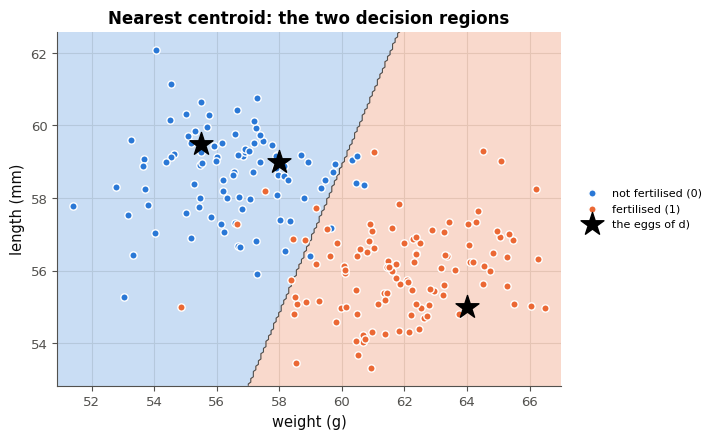

In [26]:
if filled(model_11):
    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    wb.plot.plot_decision_boundary(model_11, X_11, y_11, ax=ax, class_names=["not fertilised (0)", "fertilised (1)"])
    ax.scatter(EGGS_11[:, 0], EGGS_11[:, 1], marker="*", s=300, color="black", zorder=5, label="the eggs of d)")
    ax.set(xlabel="weight (g)", ylabel="length (mm)", title="Nearest centroid: the two decision regions")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)   # outside: its star is not an egg
    plt.show()
else:
    print("⏳ Ex 7.11 : entraîne d'abord model_11 (question b), puis relance cette cellule.")

💡 108 œufs fécondés sur 200. Accuracy de 0,935 sur les œufs d'entraînement et de 0,9175 sur les œufs nouveaux : c'est la seconde qui compte, celle qui prédit le comportement du classifieur sur les œufs de demain (ch. 1, et ch. 8). L'écart, petit, est normal : le classifieur a été réglé sur ces 200 œufs-là. La frontière est une droite, la médiatrice du segment qui joint les deux centroïdes (∂ 7.7) ; les œufs mal classés sont tous près d'elle, dans la zone où les deux nuages se recouvrent. Une droite mieux orientée, qui tient compte des dispersions, fait un peu mieux (0,955 sur les mêmes œufs nouveaux, avec les features standardisées : variante de 7.14), mais aucune ne classe tout : c'est le troisième cas de la fiche (§7.2.1).

### Ex 7.12 — k-means sur deux lunes : où tombera la coupure ? 🔮 ★ ⏱️ 10 min
**Objectif :** prévoir la forme des clusters de k-means sur deux groupes emboîtés, avant de lire la section qui l'explique.  
**Prérequis :** fiche §7.5 jusqu'à « Combien de clusters ? » (pas encore « Quand k-means échoue ») · Ex 7.11 · **Fil rouge :** synthétique (lunes) · **Parcours :** R, C

Fais cet exercice **avant** de lire la section « Quand k-means échoue » de la fiche. Les 300 points de `X_12` forment deux lunes entrelacées (`wb.synth.make_moons`). On lance k-means avec $k = 2$ (`SklearnKMeans`, scikit-learn), qui ne voit que les points, pas leur lune.

Prédis, dans la cellule ci-dessous, **avant** d'exécuter l'expérience :
a) `shape_12` : la frontière entre les deux clusters sera `"A"` une courbe qui suit les lunes, `"B"` une droite, ou `"C"` un cercle ;
b) `agree_12` : la part des points rangés dans le même cluster que les autres points de leur lune (au mieux des deux numérotations des clusters) sera proche de `0.5`, `0.75` ou `1.0`.

Puis exécute l'expérience : elle colore les clusters, marque les deux centres et affiche la part de b).

Dans tes notes : compare avec tes prédictions. Avec l'algorithme de Lloyd (fiche, encadré 🧮), explique la forme de la frontière : que fait l'étape d'affectation de chaque point du plan ? Lis ensuite la section « Quand k-means échoue ».

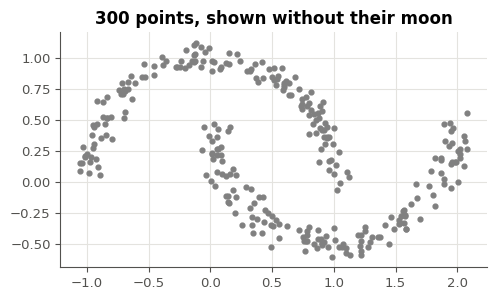

In [27]:
X_12, moon_12 = wb.synth.make_moons(n=300, noise=0.06, seed=712)   # moon_12: the moon each point comes from
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.scatter(X_12[:, 0], X_12[:, 1], s=12, color="gray")
ax.set(title="300 points, shown without their moon", aspect="equal")
plt.show()

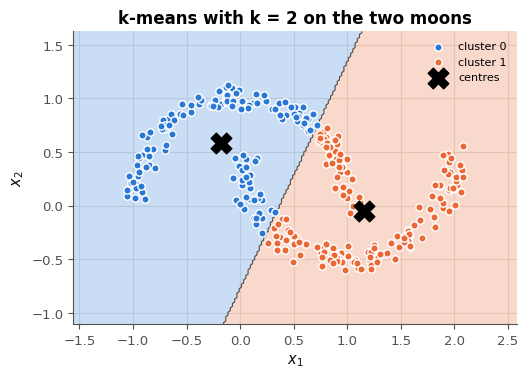

share of the points clustered with their own moon: 0.733
your predictions: a) B   b) 0.75


In [28]:
shape_12, agree_12 = "B", 0.75                        # the answers, for the record
km_12 = SklearnKMeans(n_clusters=2, n_init=10, random_state=0).fit(X_12)
labels_12 = km_12.labels_
agreement_12 = max(np.mean(labels_12 == moon_12), np.mean(labels_12 != moon_12))   # the better of the two numberings
fig, ax = plt.subplots(figsize=(6, 3.8))
wb.plot.plot_decision_boundary(km_12, X_12, labels_12, ax=ax, class_names=["cluster 0", "cluster 1"])
ax.scatter(*km_12.cluster_centers_.T, marker="X", s=220, color="black", zorder=5, label="centres")
ax.set(title="k-means with k = 2 on the two moons", aspect="equal")
ax.legend(fontsize=8)
plt.show()
print(f"share of the points clustered with their own moon: {agreement_12:.3f}")
print(f"your predictions: a) {shape_12}   b) {agree_12}")

💡 La frontière est une **droite** (B) et elle coupe chaque lune en deux : seuls 73 % des points sont rangés avec leur lune (≈ 0,75). À la fin, chaque point rejoint le centre le plus proche : la frontière entre deux clusters est donc la médiatrice des deux centres, comme pour le centroïde le plus proche (∂ 7.7), et chaque cluster est un demi-plan, une région convexe. Aucune droite ne sépare deux lunes entrelacées : k-means ne peut pas les trouver, quel que soit son départ. Remarque aussi les centres : la moyenne d'une forme courbée tombe dans le creux de la courbe, là où il n'y a presque pas de points. DBSCAN et HDBSCAN (Ex 7.18) suivent la forme des données.

### Ex 7.13 — Distances au carré vectorisées : pairwise_sq_distances 🔨 ★★ ⏱️ 20 min
**Objectif :** calculer toutes les distances au carré entre deux nuages de points sans boucle Python.  
**Prérequis :** rappel 7.R3 · 0A (broadcasting, réductions par axe) · fiche §7.5 (encadré 🧮 « toutes les distances d'un coup ») · **Fil rouge :** synthétique · **mylearn :** `cluster.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/cluster.py` (créé par `python tools/start_chapter.py 7`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy est permis ; SciPy et scikit-learn non : `scipy.spatial.distance.cdist` et les classes de scikit-learn sont les **oracles** des tests. La cellule de vérification recharge ta librairie, affiche quelques valeurs, puis lance les tests de tes fonctions ; `python -m pytest tests/test_ch07_cluster.py -q` les lance tous dans un terminal.

Écris `pairwise_sq_distances(A, B)` (lis sa docstring) :
- convertis `A` et `B` en tableaux de flottants (`np.asarray(..., dtype=float)`), et lève une `ValueError` si l'un d'eux n'est pas à deux dimensions, ou s'ils n'ont pas le même nombre de colonnes ;
- calcule toutes les distances au carré **sans boucle Python**, d'une de ces deux façons : par broadcasting, `A[:, None, :] - B[None, :, :]` donne toutes les différences, un tableau de forme $(n_a, n_b, p)$ dont tu sommes les carrés sur le dernier axe ; ou par l'identité du rappel 7.R3, avec les normes au carré des lignes (`(A ** 2).sum(axis=1)`), **un** produit matriciel `A @ B.T` et le broadcasting ;
- remplace les minuscules valeurs négatives dues aux arrondis par 0 (`np.maximum(D, 0.0)`).

Les deux façons sont justes, mais garde de préférence l'identité : tu réutiliseras ta fonction sur des images de 784 pixels (7.20), où le tableau intermédiaire du broadcasting pèserait plus d'un gigaoctet.

La cellule de vérification affiche l'exemple de la docstring, compare ta fonction à une double boucle Python et mesure leurs vitesses, puis lance les tests.

Dans tes notes : pour 10 000 points contre 10 000 points en dimension 784, combien de nombres chaque méthode stocke-t-elle au plus fort du calcul ? Pourquoi l'identité peut-elle donner des valeurs négatives, et pourquoi faut-il s'en soucier avant de prendre une racine carrée ?

In [29]:
if True:
    A_13 = np.array([[0.0, 0.0], [1.0, 1.0]])
    B_13 = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 4.0]])
    print("the example of the docstring:\n", mylearn.cluster.pairwise_sq_distances(A_13, B_13))
    rng_13 = np.random.default_rng(713)
    P_13, Q_13 = rng_13.normal(size=(300, 5)), rng_13.normal(size=(200, 5))
    start_13 = time.perf_counter()
    loop_13 = np.array([[((p - q) ** 2).sum() for q in Q_13] for p in P_13])     # 60 000 Python iterations
    loop_time_13 = time.perf_counter() - start_13
    start_13 = time.perf_counter()
    fast_13 = mylearn.cluster.pairwise_sq_distances(P_13, Q_13)
    fast_time_13 = time.perf_counter() - start_13
    if returned("7.13", "pairwise_sq_distances", fast_13):
        verdict("7.13", np.shape(fast_13) == (300, 200) and np.allclose(fast_13, loop_13),
                "les mêmes distances que la double boucle.",
                "tes distances ne sont pas celles de la double boucle (forme (300, 200) attendue) : relis la docstring.")
        print(f"double loop: {loop_time_13 * 1000:.0f} ms · yours: {fast_time_13 * 1000:.2f} ms, "
              f"about {loop_time_13 / max(fast_time_13, 1e-9):.0f} times faster")
    run_mylearn_tests("cluster", "test_pairwise_sq_distances_", impl="ref")

the example of the docstring:
 [[ 1.  4. 25.]
 [ 1.  2. 13.]]
✅ Ex 7.13 : les mêmes distances que la double boucle.
double loop: 155 ms · yours: 1.55 ms, about 100 times faster


pytest: 14 passed, 75 deselected in 1.01s


💡 La référence (`solutions/mylearn_ref/cluster.py`, à lire **après** avoir réussi les tests) utilise l'identité : normes au carré, un produit `A @ B.T`, puis `np.maximum(..., 0.0)`. Pour 10 000 × 10 000 points en dimension 784, le broadcasting crée un tableau intermédiaire de $10^4 \times 10^4 \times 784 \approx 7{,}8 \times 10^{10}$ nombres (plus de 600 Go en float64) : impossible ; l'identité ne stocke que des tableaux de $10^8$ nombres (800 Mo) : le produit `A @ B.T` et le résultat. Les valeurs négatives viennent d'une soustraction de deux grands nombres presque égaux (deux points très proches loin de l'origine) : `np.sqrt` d'un nombre négatif donne `nan`, qui contamine ensuite les moyennes.

### Ex 7.14 — Le classifieur du centroïde le plus proche 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire un premier classifieur « à la scikit-learn » : fit, decision_function, predict et score.  
**Prérequis :** Ex 7.13 · ∂ 7.7 · fiche §7.3 et §7.5 (encadré 🧮 sur le centroïde le plus proche) · **Fil rouge :** synthétique (œufs) · **mylearn :** `cluster.py` · **Parcours :** R, C

> **mylearn** : dans `mon_travail/mylearn/cluster.py`, mêmes règles qu'en 7.13 (NumPy permis, SciPy et scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris la classe `NearestCentroid` (lis ses docstrings). C'est ta première classe « à la scikit-learn » : `__init__` ne fait rien (pas d'hyperparamètre), `fit` apprend et renvoie `self`, et les attributs appris finissent par `_`.
- `fit(X, y)` : `classes_` est le tableau **trié** des labels distincts (`np.unique`) ; `centroids_[k]` est la moyenne des lignes de `X` de la classe `classes_[k]`, dans le même ordre. Lève une `ValueError` s'il y a moins de deux classes, ou si `X` et `y` n'ont pas le même nombre de lignes ;
- `decision_function(X)` : réutilise ta `pairwise_sq_distances` (7.13). Avec deux classes, un score par ligne, $d^2(\mathbf{x}, \boldsymbol{\mu}_0) - d^2(\mathbf{x}, \boldsymbol{\mu}_1)$, positif quand la classe `classes_[1]` est la plus proche ; avec $K > 2$ classes, une colonne par classe, $-d^2(\mathbf{x}, \boldsymbol{\mu}_k)$ ;
- `predict(X)` : le label du centroïde le plus proche. En cas d'égalité de distances, **la première classe** de `classes_` gagne : c'est ce que fait `np.argmin`, qui garde le premier minimum ;
- `score(X, y)` : l'accuracy de `predict(X)`, un `float` Python.

Puis la vérification entraîne ta classe sur les trois classes d'œufs du livre (§7.3 : `"viable"`, `"clair"` pour le *yolker*, `"mort"` pour le *quitter*) et vérifie :
a) son accuracy sur 600 œufs nouveaux ;
b) le centroïde de la classe `"mort"` ;
enfin, elle compare tes prédictions à celles de scikit-learn, dessine les trois régions et lance les tests.

Dans tes notes : pourquoi les frontières sont-elles des morceaux de droites (∂ 7.7) ? Quelles classes se confondent le plus, et pourquoi ?

In [30]:
def make_egg_classes(n, seed):
    """n imaginary eggs of the three classes of the book (§7.3): weight (g), length (mm) and class name."""
    rng = np.random.default_rng(seed)
    names = np.array(["viable", "clair", "mort"])      # fertilised and alive / never fertilised / dead embryo
    means = np.array([[62.0, 56.0], [56.5, 58.5], [60.0, 59.5]])
    which = rng.integers(0, 3, n)
    X = means[which] + rng.normal(0.0, [1.8, 1.0], (n, 2))
    return X, names[which]


X_14, y_14 = make_egg_classes(300, seed=714)
X_new_14, y_new_14 = make_egg_classes(600, seed=1714)
print({str(name): int(count) for name, count in zip(*np.unique(y_14, return_counts=True))})

{'clair': 101, 'mort': 92, 'viable': 107}


classes_: ['clair', 'mort', 'viable']
a) accuracy on the new eggs: 0.84 · b) centroid of "mort": [59.8359 59.3436]
predicted  clair  mort  viable
true                          
clair        161    34       1
mort          36   151       9
viable         7     9     192
same predictions as scikit-learn: True


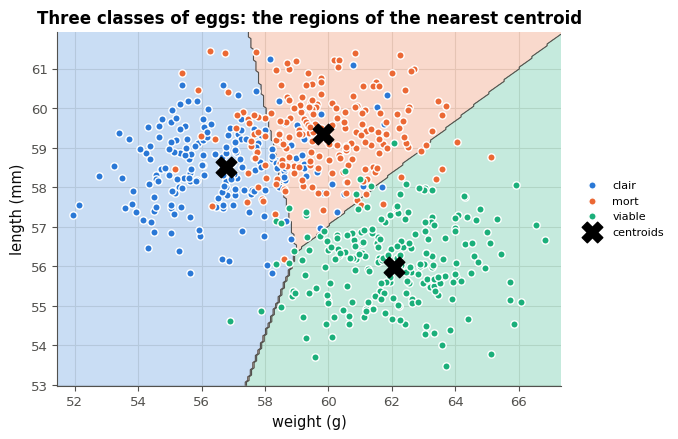

pytest: 19 passed, 70 deselected in 1.01s


In [31]:
model_14 = mylearn.cluster.NearestCentroid().fit(X_14, y_14)
classes_14 = model_14.classes_.tolist()
print("classes_:", classes_14)
print("a) accuracy on the new eggs:", model_14.score(X_new_14, y_new_14),
      "· b) centroid of \"mort\":", model_14.centroids_[classes_14.index("mort")].round(4))
print(pd.crosstab(y_new_14, model_14.predict(X_new_14), rownames=["true"], colnames=["predicted"]))
print("same predictions as scikit-learn:",
      np.array_equal(model_14.predict(X_new_14), SklearnNearestCentroid().fit(X_14, y_14).predict(X_new_14)))
fig, ax = plt.subplots(figsize=(6.5, 4.6))
wb.plot.plot_decision_boundary(model_14, X_new_14, y_new_14, ax=ax, class_names=classes_14)
ax.scatter(*model_14.centroids_.T, marker="X", s=220, color="black", zorder=5, label="centroids")
ax.set(xlabel="weight (g)", ylabel="length (mm)", title="Three classes of eggs: the regions of the nearest centroid")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()
run_mylearn_tests("cluster", "test_nearest_centroid_", impl="ref")

In [32]:
wb.record("7.14a", model_14.score(X_new_14, y_new_14), decimals=4)
wb.record("7.14b", model_14.centroids_[list(model_14.classes_).index("mort")], decimals=4,
          mistakes={"c'est le centroïde de la classe « clair » : prends la ligne de classes_ qui vaut « mort »": model_14.centroids_[list(model_14.classes_).index("clair")],
                    "c'est le centroïde de la classe « viable » : prends la ligne de classes_ qui vaut « mort »": model_14.centroids_[list(model_14.classes_).index("viable")]})

WB_ANSWER {"decimals": 4, "hash": "dbfe469e6a91a2fc3fa57a766cc31c6d298226887a4c8a8fb6a59f2896089430", "hash_coarse": "a5fbb5f44abf8e8dc97cb86a7575b084761dfaebe99b97d0d1795c699313c621", "id": "7.14a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 7.14a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["cd5dc3a05c3666f400c110e7f480e882347443b05b2c23f0e2b2a944dae4a628"], ["2d88f049839d019eef357ce7128a7c9de7b4749164457efd0398f8753d61f384"]], "element_hashes": ["c8dc2be1a040763ad9bef37d41898aff9f97725b7e88701272809c5422379ac1", "b0a5dbb418890902e21d959e35b0c87d8d0423242042505c1f6c748a5edd78a1"], "hash": "5b8abdb36bdf5c0e3bad95e7a35ee475f4df1eabc0496a47435f11bd1a7d8096", "id": "7.14b", "kind": "array", "mistakes": {"554879d88b194d86a9ca3beab9dfac5b5e71c4cdda4e0c4c116c471fe7184c00": "c'est le centroïde de la classe « viable » : prends la ligne de classes_ qui vaut « mort »", "59d637c2ce9cc253ac9fa99575cf874d381fe6dbb78f78aadf2cbed722e7c612": "c'es

💡 `classes_` vaut `['clair', 'mort', 'viable']` : l'ordre alphabétique de `np.unique`, pas l'ordre d'apparition. Accuracy de 0,84 sur les œufs nouveaux. Les classes `"clair"` et `"mort"` se confondent le plus (70 erreurs sur 96) : leurs centres ne sont qu'à 3,5 g et 1 mm l'un de l'autre, alors que les œufs `"viable"`, plus lourds et plus courts, sont à part. Les frontières sont des morceaux des médiatrices des trois paires de centroïdes, qui se coupent en un même point (∂ 7.7, question 4).

### Ex 7.15 — Carte de probabilité et politique de seuil pour les œufs 📈 ★★ ⏱️ 25 min
**Objectif :** calculer une carte de probabilité par la règle de Bayes, y lire l'effet d'un seuil, et chiffrer le coût de deux politiques.  
**Prérequis :** rappel 7.R2 · ch. 2 (loi normale) · ch. 3 (seuil, faux positifs et faux négatifs) · fiche §7.2.1 (encadré 🧮 sur le seuil de coût minimal) · **Fil rouge :** synthétique (œufs) · **Parcours :** M, C

Dans une autre ferme, 35 % des œufs sont fécondés (`PRIOR_15`). Les mesures (poids, longueur) suivent une loi normale à deux dimensions dans chaque classe, de moyennes et de matrices de covariance données (`MEAN_1_15`, `COV_1_15` pour les œufs fécondés, `MEAN_0_15`, `COV_0_15` pour les autres). `scipy.stats.multivariate_normal(mean, cov).pdf(X)` donne la densité de cette loi en chaque ligne de `X` (ch. 2 : c'est la courbe en cloche, en deux dimensions). Garder un œuf non fécondé dans l'incubateur coûte 1 (un faux positif), vendre un œuf fécondé coûte 6 (un faux négatif).

a) écris `posterior_15(X)`, qui renvoie $P(\text{fécondé} \mid \mathbf{x})$ pour chaque ligne de `X` par la règle de Bayes (fiche §7.2.1, rappel 7.R2) ; la vérification l'appelle sur les quatre œufs A, B, C, D de `POINTS_15` ;
b) `t_star_15` : le seuil qui minimise le coût moyen (fiche, encadré 🧮), sous forme de calcul ou avec 3 décimales.

Une cellule plus bas, après la vérification, dessine la carte de $P(\text{fécondé} \mid \mathbf{x})$, ses deux lignes de niveau (au seuil 0,5 et au seuil $t^*$) et les quatre œufs. **Lis la carte**, puis réponds :
c) `changes_15` : l'ensemble des lettres des œufs dont la décision change quand on passe du seuil 0,5 au seuil $t^*$ (par exemple `{"X", "Y"}`) ;
d) `counts_15` : sur les 2 000 œufs simulés `eggs_15` (dont la vérité est `truth_15`), déclare « fécondé » quand $P \ge t$ ; donne `[[FN, FP] au seuil 0,5, [FN, FP] au seuil t*]` ;
e) `costs_15` : le coût moyen par œuf à chacun des deux seuils, `[coût à 0,5, coût à t*]`, avec les coûts de l'énoncé.

Dans tes notes : pourquoi la frontière est-elle courbe, alors que celle du centroïde le plus proche est une droite ? Qui devrait choisir les deux coûts (⚖️ 7.10) ?

In [33]:
PRIOR_15 = 0.35                                    # share of fertilised eggs in this farm
MEAN_1_15, COV_1_15 = np.array([61.0, 56.0]), np.array([[4.0, 1.2], [1.2, 1.5]])     # fertilised eggs
MEAN_0_15, COV_0_15 = np.array([57.0, 58.0]), np.array([[5.0, -1.0], [-1.0, 2.0]])   # non-fertilised eggs
COST_FP_15, COST_FN_15 = 1.0, 6.0                  # keep a non-fertilised egg (FP) / sell a fertilised one (FN)
POINTS_15 = {"A": (62.0, 55.5), "B": (59.5, 57.0), "C": (58.5, 56.5), "D": (59.2, 58.0)}   # four eggs to read

rng_15 = np.random.default_rng(715)                # 2000 simulated eggs of this farm, with their truth
truth_15 = (rng_15.random(2000) < PRIOR_15).astype(int)
eggs_15 = np.where(truth_15[:, None] == 1, rng_15.multivariate_normal(MEAN_1_15, COV_1_15, 2000),
                   rng_15.multivariate_normal(MEAN_0_15, COV_0_15, 2000))
print(f"{truth_15.sum()} fertilised eggs among {len(truth_15)}")

720 fertilised eggs among 2000


In [34]:
def posterior_15(X):
    """P(fertilised | x) for every row x of X, by Bayes' rule: an array of shape (n,)."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    f_1 = scipy.stats.multivariate_normal(MEAN_1_15, COV_1_15).pdf(X)
    f_0 = scipy.stats.multivariate_normal(MEAN_0_15, COV_0_15).pdf(X)
    return np.atleast_1d(PRIOR_15 * f_1 / (PRIOR_15 * f_1 + (1 - PRIOR_15) * f_0))


t_star_15 = COST_FP_15 / (COST_FP_15 + COST_FN_15)
p_points_15 = posterior_15(np.array(list(POINTS_15.values())))
print({name: round(float(p), 3) for name, p in zip(POINTS_15, p_points_15)}, "· t* =", round(t_star_15, 4))

{'A': 0.92, 'B': 0.313, 'C': 0.246, 'D': 0.049} · t* = 0.1429


In [35]:
wb.record("7.15a", p_points_15, decimals=4, mistakes={
    "tu as oublié l'a priori : multiplie chaque densité par la probabilité de sa classe (0,35 et 0,65)": 0.5 * scipy.stats.multivariate_normal(MEAN_1_15, COV_1_15).pdf(np.array(list(POINTS_15.values()))) / (0.5 * scipy.stats.multivariate_normal(MEAN_1_15, COV_1_15).pdf(np.array(list(POINTS_15.values()))) + 0.5 * scipy.stats.multivariate_normal(MEAN_0_15, COV_0_15).pdf(np.array(list(POINTS_15.values())))),
    "c'est la probabilité de NE PAS être fécondé : on demande P(fécondé | x)": 1 - p_points_15})
wb.record("7.15b", t_star_15, decimals=3, mistakes={
    "c'est l'inverse : le seuil BAISSE quand les faux négatifs coûtent cher (fiche, encadré 🧮 du §7.2.1)": COST_FN_15 / (COST_FP_15 + COST_FN_15),
    "le dénominateur est la SOMME des deux coûts": COST_FP_15 / COST_FN_15,
    "0,5 ne minimise le coût que si les deux erreurs coûtent autant": 0.5})

WB_ANSWER {"decimals": 4, "element_coarse": [["552ceb05fc81f59f2700a0efd141ac091e72d0c3c2b846ab19264e3db925add5"], ["3bcbb8a056582550f20071d3f0ac8c6f7f6d6e4f4384ccd949bd7ef4b22866af"], ["78395bfe293fbfcc1446a83bbfde38a1abc00a994aa0a168539be32d7f8cc70a"], ["3c79678d0ef1084c552f7ea6ae4f579a9144fb27340334ff906430594461f86c"]], "element_hashes": ["7a5518541b50d8d5d60502946383e377ae770d54f184868ead72fb70486b09e7", "1b587bafccdb353b1cd33cc02193a0e25f85343474f7257ca313a655cc725d20", "b7ba068710a5e169a69efe5cf4c0803a88460703435b6e54be2142a96e7ab39a", "ef896d923af93c72328003aecbd21ce7931b7357f30f8a245d28ebb2cd6a90af"], "hash": "726964fe0111d3bce15208aeeddeb699234b45cb7886df0f58cf2670c762e768", "id": "7.15a", "kind": "array", "mistakes": {"867dfed6cf01de75db530522cabad3edf992c16bfee0822e4d5ef3b9dbb18d15": "c'est la probabilité de NE PAS être fécondé : on demande P(fécondé | x)", "97a71ef18914f7f4c9a889711efe5d18f3b9e867483e92fc86e3155166703ca5": "tu as oublié l'a priori : multiplie chaque densit

**La carte** : exécute la cellule une fois `posterior_15` et `t_star_15` écrits.

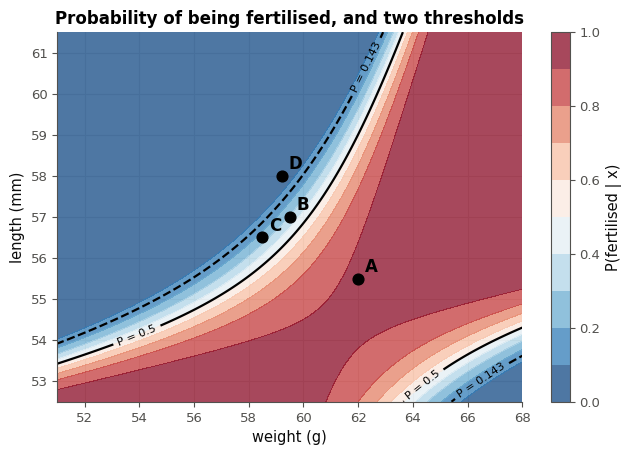

In [36]:
with wb.attempt("7.15"):
    if not filled(t_star_15):
        raise NotImplementedError("write t_star_15 first (question b)")
    weights_15, lengths_15 = np.meshgrid(np.linspace(51, 68, 240), np.linspace(52.5, 61.5, 200))
    grid_15 = np.column_stack([weights_15.ravel(), lengths_15.ravel()])
    p_grid_15 = posterior_15(grid_15)
    if returned("7.15", "posterior_15", p_grid_15):
        p_grid_15 = np.asarray(p_grid_15, dtype=float).reshape(weights_15.shape)
        fig, ax = plt.subplots(figsize=(7.5, 4.8))
        shade_15 = ax.contourf(weights_15, lengths_15, p_grid_15, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.75)
        plt.colorbar(shade_15, ax=ax, label="P(fertilised | x)")
        lines_15 = ax.contour(weights_15, lengths_15, p_grid_15, levels=sorted([t_star_15, 0.5]), colors="black",
                              linestyles=["--", "-"] if t_star_15 < 0.5 else ["-", "--"], linewidths=1.6)
        ax.clabel(lines_15, fmt=lambda level: f"P = {level:.3f}".rstrip("0"), fontsize=8)
        for name, (w, l) in POINTS_15.items():
            ax.scatter(w, l, marker="o", s=60, color="black", zorder=5)
            ax.annotate(name, (w, l), xytext=(5, 5), textcoords="offset points", fontsize=12, weight="bold")
        ax.set(xlabel="weight (g)", ylabel="length (mm)", title="Probability of being fertilised, and two thresholds")
        plt.show()

Lis la carte, puis réponds aux questions c) à e).

In [37]:
changes_15 = {"B", "C"}                                # read on the map: between the two level lines
p_eggs_15 = posterior_15(eggs_15)
counts_15, costs_15 = [], []
for threshold in [0.5, t_star_15]:
    declared = p_eggs_15 >= threshold
    fn = int(np.sum(~declared & (truth_15 == 1)))       # fertilised eggs sold
    fp = int(np.sum(declared & (truth_15 == 0)))        # non-fertilised eggs kept
    counts_15.append([fn, fp])
    costs_15.append((fn * COST_FN_15 + fp * COST_FP_15) / len(truth_15))
print(counts_15, np.round(costs_15, 4))

[[66, 134], [12, 255]] [0.265  0.1635]


In [38]:
wb.record("7.15c", changes_15, mistakes={
    "un œuf de ton ensemble reste du même côté des deux lignes de niveau : sa décision ne change pas": {"A", "B", "C"},
    "un des œufs choisis garde la même décision aux deux seuils : relis sa position par rapport aux lignes": {"B", "C", "D"},
    "il manque un œuf : cherche tous ceux qui sont entre les deux lignes de niveau": {"B"},
    "ton ensemble est incomplet : relis la position de chaque œuf par rapport aux deux lignes": {"C"}})
wb.record("7.15d", counts_15, mistakes={"l'ordre est [FN, FP] pour chaque seuil": [[fp, fn] for fn, fp in counts_15],
                                        "l'ordre des seuils est [0,5, t*]": counts_15[::-1]})
wb.record("7.15e", costs_15, decimals=4, mistakes={
    "un faux NÉGATIF (œuf fécondé vendu) coûte 6, un faux positif 1": [(fn * COST_FP_15 + fp * COST_FN_15) / len(truth_15) for fn, fp in counts_15],
    "c'est le coût total : divise par le nombre d'œufs (2 000)": [fn * COST_FN_15 + fp * COST_FP_15 for fn, fp in counts_15]})

WB_ANSWER {"hash": "e23ba317c47d53c146e275dcd191684ca3f5f66bf6ffad708ca212c89273e66e", "id": "7.15c", "kind": "set", "mistakes": {"17f9990d83f24166710e2c50a4d585395f3fc77f44444b1ccf8e6c2178c4d82d": "un des œufs choisis garde la même décision aux deux seuils : relis sa position par rapport aux lignes", "971bd7f04fdb30ae4afb0eff19e9246472cac387a47dba27328c2a48a09497f0": "un œuf de ton ensemble reste du même côté des deux lignes de niveau : sa décision ne change pas", "99f71b0d4b0cfdf1d7a2be22dd32bb6fb4e92b420849844ee1d549190419b469": "il manque un œuf : cherche tous ceux qui sont entre les deux lignes de niveau", "e90ed3b4ac5ff2294bf2c0ee23231b5bdc5c194b519e526202b31439e4c3d03c": "ton ensemble est incomplet : relis la position de chaque œuf par rapport aux deux lignes"}}
📝 Ex 7.15c : réponse enregistrée (set).
WB_ANSWER {"decimals": 0, "element_hashes": ["12041b6b56a2e54661750d7215443c3396310a95318e2a53ba76b026b3093565", "c7335be4141b97a1631bf1451d64b80f795f2b0564ec239a0eafdf1511f39094",

💡 $t^* = \frac{1}{1 + 6} \approx 0{,}143$. Sur la carte, A est franchement « fécondé » ($P \approx 0{,}92$), D franchement non ($P \approx 0{,}05$) ; B ($P \approx 0{,}31$) et C ($P \approx 0{,}25$) sont entre les deux lignes de niveau : non fécondés au seuil 0,5, fécondés au seuil $t^*$. Sur les 2 000 œufs, passer de 0,5 à $t^*$ divise les faux négatifs par plus de cinq (66 → 12) et double presque les faux positifs (134 → 255) : le coût moyen par œuf passe de 0,265 à 0,1635. La frontière est courbe parce que les deux classes n'ont pas la même matrice de covariance : la règle de Bayes compare deux formes de cloches différentes, alors que le centroïde le plus proche ne regarde que deux moyennes. C'est aussi ce qui dessine d'autres lignes de niveau en bas à droite : très lourds et très courts, les œufs y redeviennent « non fécondés », parce que la cloche des œufs non fécondés, plus étalée en poids, l'emporte loin des deux moyennes.

### Ex 7.16 — Un-contre-tous avec des centroïdes : quelle classe sera sacrifiée ? 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir quelle classe l'un-contre-tous traite le plus mal, et pourquoi.  
**Prérequis :** Ex 7.14 · fiche §7.4.1 · **Fil rouge :** synthétique · **Parcours :** C

Quatre classes A, B, C et D (figure ci-dessous). On les classe de deux façons, toutes deux avec **ton** `NearestCentroid` (7.14) :
- le **centroïde le plus proche multi-classe** : un seul modèle, quatre centroïdes ;
- l'**un-contre-tous** (fiche §7.4.1) : pour chaque classe $k$, un `NearestCentroid` binaire apprend « $k$ » (label 1) contre « tout le reste » (label 0). Il a donc deux centroïdes : celui de la classe $k$, et celui de **toutes les autres classes réunies**. Son score, `decision_function`, est positif quand le centroïde de $k$ est le plus proche ; on prédit la classe du plus grand des quatre scores.

On compare le **recall** de chaque classe (la part de ses points de test bien classés) dans les deux cas.

Prédis, **avant** d'exécuter l'expérience :
a) `sacrificed_16` : la lettre de la classe dont le recall baissera le plus avec l'un-contre-tous ;
b) `recall_16` : son recall avec l'un-contre-tous sera proche de `0.9`, `0.6` ou `0.3` ?

Indice pour raisonner : pour chaque classe, où tombe le centroïde de « tout le reste » ?

Dans tes notes : compare avec tes prédictions, et explique ce qui arrive au classifieur binaire de la classe sacrifiée. Tu écriras en 7.22 un un-contre-tous générique, qui refera ce calcul pour n'importe quel classifieur binaire.

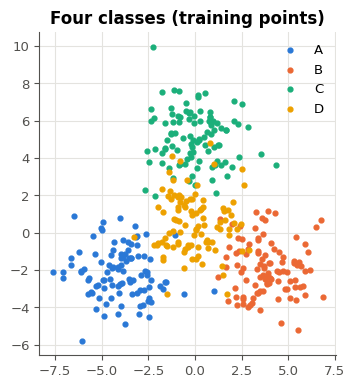

In [39]:
LAYOUT_16 = {"A": (-4.0, -2.0), "B": (4.0, -2.0), "C": (0.0, 5.0), "D": (0.0, 0.33)}   # the centre of each class


def make_four_16(n, seed):
    """n points of each of the four classes of LAYOUT_16 (standard deviation 1.4)."""
    rng = np.random.default_rng(seed)
    X = np.vstack([rng.normal(centre, 1.4, (n, 2)) for centre in LAYOUT_16.values()])
    return X, np.repeat(np.array(list(LAYOUT_16)), n)


X_16, y_16 = make_four_16(100, seed=716)            # training points
X_test_16, y_test_16 = make_four_16(300, seed=1716)  # test points
fig, ax = plt.subplots(figsize=(5, 4.2))
for name in LAYOUT_16:
    ax.scatter(*X_16[y_16 == name].T, s=12, label=name)
ax.set(title="Four classes (training points)", aspect="equal")
ax.legend()
plt.show()

recall        A      B      C      D
native NC 0.933  0.967  0.917  0.843
OvR       0.963  0.997  0.990  0.590


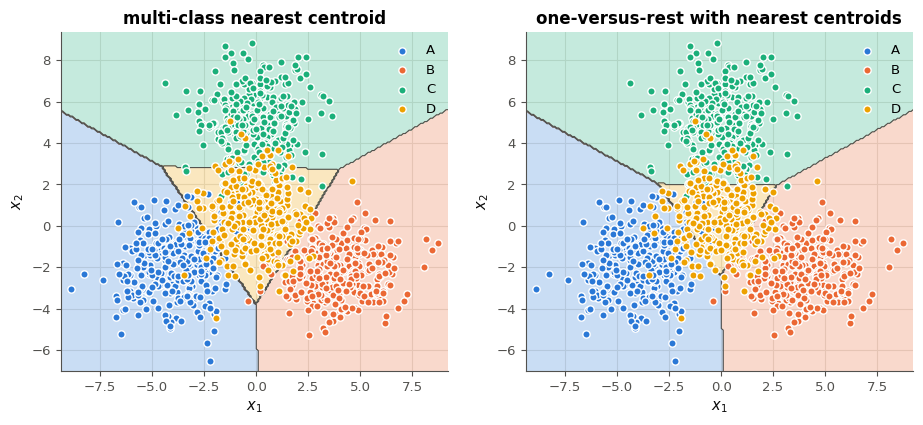

your predictions: a) D   b) 0.6


In [40]:
sacrificed_16, recall_16 = "D", 0.6                    # the answers, for the record
if True:
    classes_16 = np.unique(y_16)
    native_16 = fitted(mylearn.cluster.NearestCentroid(), X_16, y_16)          # one multi-class model
    binary_16 = [fitted(mylearn.cluster.NearestCentroid(), X_16, (y_16 == c).astype(int))
                 for c in classes_16]                                           # "c against the rest", for each c


    def by_hand_16(points):
        """One-versus-rest by hand: the class of the highest of the four binary scores."""
        return classes_16[np.column_stack([model.decision_function(points) for model in binary_16]).argmax(axis=1)]


    ovr_16 = by_hand_16(X_test_16)
    pred_native_16 = np.asarray(native_16.predict(X_test_16))
    print("recall    " + "  ".join(f"{c:>5}" for c in classes_16))
    print("native NC " + "  ".join(f"{np.mean(pred_native_16[y_test_16 == c] == c):5.3f}" for c in classes_16))
    print("OvR       " + "  ".join(f"{np.mean(ovr_16[y_test_16 == c] == c):5.3f}" for c in classes_16))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    wb.plot.plot_decision_boundary(native_16, X_test_16, y_test_16, ax=axes[0], class_names=list(classes_16))
    axes[0].set_title("multi-class nearest centroid")
    wb.plot.plot_decision_boundary(by_hand_16, X_test_16, y_test_16, ax=axes[1], class_names=list(classes_16))
    axes[1].set_title("one-versus-rest with nearest centroids")
    plt.show()
    print(f"your predictions: a) {sacrificed_16}   b) {recall_16}")

💡 La classe **D**, au milieu des trois autres, est sacrifiée : son recall passe de 0,84 à 0,59 (≈ 0,6), alors que celui des trois autres monte. Le centroïde de « tout sauf D » est la moyenne des classes A, B et C, qui entourent D : il tombe presque sur le centroïde de D. Le classifieur « D contre le reste » compare donc deux points presque confondus, et son score reste proche de 0 partout. D ne gagne que là où les trois autres scores sont négatifs : une petite zone au centre. Les scores de l'un-contre-tous viennent de modèles entraînés séparément : un modèle faible sur une classe difficile la fait perdre partout (fiche §7.4.1).

## Partie B · k-means, DBSCAN et HDBSCAN avec scikit-learn, puis la grande dimension

Fiche §7.5 (« Quand k-means échoue ») et §7.6, puis §7.6.1 **après** le 🔮 7.19. Tu cherches les espèces de manchots avec k-means, tu compares k-means au clustering par densité sur des formes quelconques, puis tu mesures ce que la dimension fait aux densités et aux distances. La cellule ci-dessous charge les manchots du ch. 1.

In [41]:
penguins = wb.datasets.load_penguins(dropna=True)          # ch. 1: the 333 complete penguins
FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_peng = penguins[FEATURES].to_numpy(dtype=float)
species = penguins["species"].to_numpy()                   # never shown to k-means: only used to judge it
order_peng = np.random.default_rng(42).permutation(len(penguins))   # the split of ch. 1
TEST_PENG, TRAIN_PENG = order_peng[:100], order_peng[100:]
print(X_peng.shape, {str(name): int(count) for name, count in zip(*np.unique(species, return_counts=True))})

(333, 4) {'Adelie': 146, 'Chinstrap': 68, 'Gentoo': 119}


### Ex 7.17 — Manchots sans labels : k-means face aux espèces 📦 ★★ ⏱️ 25 min
**Objectif :** regrouper des données réelles avec k-means, mesurer l'effet de la standardisation et juger les clusters avec des labels gardés de côté.  
**Prérequis :** ch. 2 (z-scores) · ch. 3 (`pd.crosstab`) · fiche §7.5 (pureté, « Quand k-means échoue ») · **Fil rouge :** Penguins · **Parcours :** R, C

Les 333 manchots complets du ch. 1 sont décrits par quatre mesures (`X_peng` : longueur et épaisseur du bec en mm, longueur de la nageoire en mm, masse en g). Leur espèce (`species`) n'est **jamais** montrée à k-means : elle sert seulement à juger les clusters trouvés.

a) écris `purity_17(labels, truth)`, la **pureté** d'un clustering (fiche §7.5) : chaque cluster prend sa classe la plus fréquente, et la pureté est la part des points qui portent cette classe. `pd.crosstab(labels, truth)` (ch. 3) donne le tableau des effectifs, une ligne par cluster. La vérification l'essaie sur un petit découpage (`TOY_LABELS_17`, `TOY_TRUTH_17`) ;
b) `raw_labels_17` : les clusters de `SklearnKMeans(n_clusters=3, n_init=10, random_state=0)` sur les mesures **brutes** `X_peng` (`.fit(...).labels_`) ; `raw_purity_17` : leur pureté ;
c) `Z_17` : les mesures **standardisées**, colonne par colonne (z-scores du ch. 2, avec la moyenne et l'écart-type de NumPy, `ddof=0`) ; `std_labels_17` et `std_purity_17` : les mêmes questions sur `Z_17` ;
d) `ari_17` : l'**indice de Rand ajusté** de c), `adjusted_rand_score(species, std_labels_17)`. Il vaut 1 pour deux découpages identiques et environ 0 pour un découpage au hasard, et il ne dépend pas de la numérotation des clusters ;
e) `split_17` : dans le découpage de c), le nom de l'espèce **la plus partagée** entre plusieurs clusters, celle dont la plus petite part des manchots se trouve dans son cluster principal (lis le tableau croisé affiché).

Dans tes notes : pourquoi les mesures brutes donnent-elles de si mauvais clusters ? Quelle mesure domine les distances, et pourquoi ? Un cluster est-il une espèce ?

In [42]:
TOY_LABELS_17 = np.array([0, 0, 0, 1, 1, 2, 2, 2])                      # a small clustering, to test purity_17
TOY_TRUTH_17 = np.array(["x", "x", "y", "x", "x", "y", "y", "z"])

In [43]:
def purity_17(labels, truth):
    """Purity of a clustering: each cluster takes its most frequent true class; share of the points that carry it."""
    table = pd.crosstab(np.asarray(labels), np.asarray(truth))
    return float(table.max(axis=1).sum() / len(labels))


raw_labels_17 = SklearnKMeans(n_clusters=3, n_init=10, random_state=0).fit(X_peng).labels_
raw_purity_17 = purity_17(raw_labels_17, species)
Z_17 = (X_peng - X_peng.mean(axis=0)) / X_peng.std(axis=0)
std_labels_17 = SklearnKMeans(n_clusters=3, n_init=10, random_state=0).fit(Z_17).labels_
std_purity_17 = purity_17(std_labels_17, species)
ari_17 = adjusted_rand_score(species, std_labels_17)
table_17 = pd.crosstab(std_labels_17, species, rownames=["cluster"], colnames=["species"])
split_17 = (table_17.max(axis=0) / table_17.sum(axis=0)).idxmin()   # the smallest share in its main cluster
print(f"raw: {raw_purity_17:.4f} · standardised: {std_purity_17:.4f} · ARI {ari_17:.4f} · most split: {split_17}")
print(pd.crosstab(raw_labels_17, species, rownames=["cluster (raw)"], colnames=["species"]))
print(table_17)

raw: 0.6787 · standardised: 0.9189 · ARI 0.7994 · most split: Adelie
species        Adelie  Chinstrap  Gentoo
cluster (raw)                           
0                   0          0      70
1                 108         52       1
2                  38         16      48
species  Adelie  Chinstrap  Gentoo
cluster                           
0           124          5       0
1             0          0     119
2            22         63       0


In [44]:
def purity_by_class_17(labels, truth):
    """The slip of taking the maximum of each CLASS (column) instead of each cluster (row)."""
    return float(pd.crosstab(np.asarray(labels), np.asarray(truth)).max(axis=0).sum() / len(labels))


wb.record("7.17a", purity_17(TOY_LABELS_17, TOY_TRUTH_17), decimals=4, mistakes={
    "tu prends le maximum de chaque classe (colonne) : la pureté prend celui de chaque CLUSTER (ligne)": purity_by_class_17(TOY_LABELS_17, TOY_TRUTH_17)})
wb.record("7.17b", raw_purity_17, decimals=4, mistakes={"c'est la pureté sur les mesures STANDARDISÉES : b) porte sur les mesures brutes": std_purity_17,
                                                       "tu prends le maximum de chaque classe (colonne) : la pureté prend celui de chaque CLUSTER (ligne)": purity_by_class_17(raw_labels_17, species)})
wb.record("7.17c", std_purity_17, decimals=4, mistakes={"c'est la pureté sur les mesures BRUTES : standardise chaque colonne de X_peng": raw_purity_17})
wb.record("7.17d", ari_17, decimals=4, mistakes={"c'est l'ARI des mesures brutes : prends std_labels_17": adjusted_rand_score(species, raw_labels_17)})
wb.record("7.17e", split_17, mistakes={"Gentoo est l'espèce la mieux regroupée (tous dans un même cluster) : lis la plus petite part": "Gentoo",
                                      "Chinstrap n'est pas la plus partagée : compare la part de chaque espèce dans son cluster principal": "Chinstrap"})

WB_ANSWER {"decimals": 4, "hash": "3d98aeb511aa084d7ac3b2bd9b4e355909974bc756422494361f35f6390d42da", "hash_coarse": "28622b1e9b0941372267b7d6362fbf6d07f75fac62721de0ac4e6f9d1806bc68", "id": "7.17a", "kind": "float", "magnitude": -1, "mistakes": {"c0df0b97d049d515237e127197a8241d5ef5bd019bd5327e682ee4a66aa44cb6": "tu prends le maximum de chaque classe (colonne) : la pureté prend celui de chaque CLUSTER (ligne)"}, "sign": 1}
📝 Ex 7.17a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "78b412853129ee62d96ca5ebdb6c39714272cb96ecbc9d44d1f33816aaa0ea4b", "hash_coarse": "0f4f349c7eeac8746332d4762d3c586a2fd9795c870c084090fa7a2e9a9ab524", "id": "7.17b", "kind": "float", "magnitude": -1, "mistakes": {"1e2703760ae59c71e5159e62300053876d546c58f6e1ee8a97b8e0b5ec9b1cb9": "c'est la pureté sur les mesures STANDARDISÉES : b) porte sur les mesures brutes", "4e4b6106d17213e0d448a7f2378831b9ac09efec34b67bd42087cf39112c0a36": "tu prends le maximum de chaque classe (colonne) 

💡 Sur les mesures brutes, la pureté n'est que de 0,679 : la masse, en grammes (environ 4 000), écrase les trois autres mesures (une quinzaine à quelques centaines de mm) dans les distances, et k-means découpe presque seulement selon la masse. Standardisées, les quatre mesures pèsent pareil : pureté 0,919, ARI 0,799 ; les Gentoo forment un cluster à eux seuls, et 22 des 146 Adélie rejoignent les Chinstrap (Adélie est l'espèce la plus partagée). Un cluster n'est pas une espèce : k-means ne connaît ni le nom des espèces ni leur nombre ; il trouve des groupes de manchots semblables, que l'on compare ensuite aux espèces. Tu iras plus loin dans le défi 🏆 7.31.

### Ex 7.18 — Formes arbitraires et bruit : DBSCAN et HDBSCAN 📦 ★★ ⏱️ 25 min
**Objectif :** comparer k-means et le clustering par densité sur des groupes de formes et de densités différentes, avec du bruit.  
**Prérequis :** Ex 7.12 · Ex 7.17 (indice de Rand ajusté) · fiche §7.5 (« Quand k-means échoue », 🕰️ sur DBSCAN et HDBSCAN) · **Fil rouge :** synthétique · **Parcours :** R, C

`X_18` réunit quatre groupes : deux lunes (300 points), un grand groupe étalé (100 points), un petit groupe très serré (60 points), et 30 points dispersés, du bruit. `group_18` donne la vérité (−1 pour le bruit) : les algorithmes ne la voient pas.

a) écris `summary_18(labels)`, qui renvoie le triplet `(nombre de clusters, nombre de points de bruit, ARI)` : on ne compte pas −1 comme un cluster, et l'ARI (`adjusted_rand_score`, 7.17) compare `labels` à `group_18` sur les seuls points qui ne sont **pas** du bruit dans `group_18` ;
b) `km_labels_18` : les clusters de `SklearnKMeans(n_clusters=4, n_init=10, random_state=0)` ;
c) `db_labels_18` : ceux de `DBSCAN(eps=0.2, min_samples=5)` (`.fit_predict(X_18)` ; −1 marque le bruit) ;
d) `scan_18` : un dictionnaire `{eps: summary_18(labels)}` pour chaque `eps` de `EPS_18`, avec `min_samples=5` ;
e) `hdb_labels_18` : ceux de `HDBSCAN(min_cluster_size=10)`, qui n'a pas d'`eps`.

La vérification affiche les tableaux et les trois découpages.

Dans tes notes : pourquoi k-means échoue-t-il, même avec le bon nombre de groupes ? Pourquoi aucun `eps` de DBSCAN ne convient-il à la fois aux deux lunes, denses et proches l'une de l'autre, et au grand groupe étalé ? Que fait HDBSCAN de différent (fiche, 🕰️) ? Lesquels des trois algorithmes ont une méthode `predict` pour un point nouveau ?

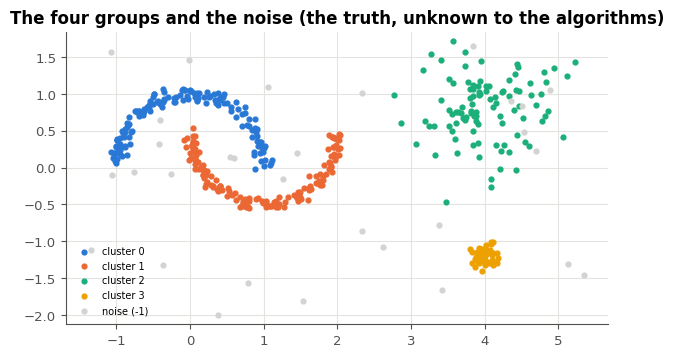

In [45]:
moons_18, moon_label_18 = wb.synth.make_moons(n=300, noise=0.05, seed=718)
rng_18 = np.random.default_rng(718)
X_18 = np.vstack([moons_18,
                  rng_18.normal((4.0, 0.8), 0.45, (100, 2)),          # a wide, sparse blob
                  rng_18.normal((4.0, -1.2), 0.08, (60, 2)),          # a small, very dense blob
                  rng_18.uniform([-1.5, -2.0], [5.5, 2.0], (30, 2))])  # 30 scattered points: noise
group_18 = np.concatenate([moon_label_18, np.full(100, 2), np.full(60, 3), np.full(30, -1)])   # -1: noise
EPS_18 = [0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
fig, ax = plt.subplots(figsize=(7, 3.8))
show_clusters(ax, X_18, group_18, "The four groups and the noise (the truth, unknown to the algorithms)")
ax.legend(fontsize=7, loc="lower left")
plt.show()

✅ Ex 7.18 : summary_18 compte bien les clusters (sans le bruit) et les points de bruit.
✅ Ex 7.18 : son ARI ne compare que les points qui ne sont pas du bruit dans group_18.
                 clusters  noise points    ARI
k-means, k=4            4             0  0.585
DBSCAN, eps=0.2         5            60  0.939
HDBSCAN, 10             4            22  0.993

      clusters  noise points    ARI
0.10        10           103  0.561
0.15         5            86  0.938
0.20         5            60  0.939
0.30         3            27  0.552
0.40         3            15  0.567
0.50         3            14  0.567

✅ Ex 7.18 : HDBSCAN retrouve les quatre groupes (ARI 0,993).
✅ Ex 7.18 : aucun eps de DBSCAN ne retrouve les quatre groupes (le meilleur ARI, 0,939, vient de eps = 0,20).


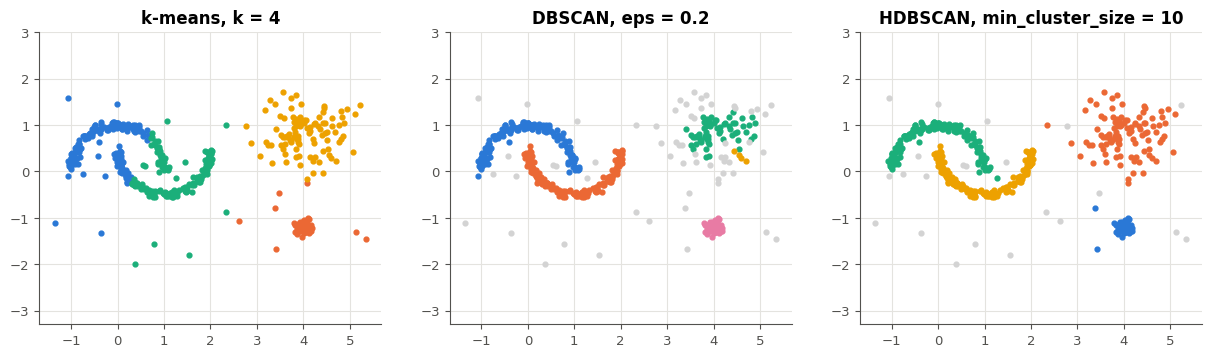

In [46]:
def summary_18(labels):
    """(number of clusters, number of noise points, ARI with group_18 on its non-noise points)."""
    labels = np.asarray(labels)
    real = group_18 != -1
    return (len(set(labels.tolist()) - {-1}), int(np.sum(labels == -1)),
            float(adjusted_rand_score(group_18[real], labels[real])))


km_labels_18 = SklearnKMeans(n_clusters=4, n_init=10, random_state=0).fit(X_18).labels_
db_labels_18 = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_18)
scan_18 = {eps: summary_18(DBSCAN(eps=eps, min_samples=5).fit_predict(X_18)) for eps in EPS_18}
hdb_labels_18 = HDBSCAN(min_cluster_size=10).fit_predict(X_18)
if True:
    toy_18 = summary_18(np.where(group_18 == 3, 2, group_18))           # the two blobs merged into one cluster
    toy_ok_18 = toy_18 is not None and np.size(toy_18) == 3 and list(toy_18)[0] == 3 and list(toy_18)[1] == 30
    if returned("7.18", "summary_18", toy_18):
        verdict("7.18", toy_ok_18,
                "summary_18 compte bien les clusters (sans le bruit) et les points de bruit.",
                "summary_18(labels) doit renvoyer (nombre de clusters sans compter -1, nombre de points -1, ARI) ; "
                f"sur un découpage test, j'attends 3 clusters et 30 points de bruit, j'obtiens {toy_18}.")
    if toy_ok_18:
        real_18 = group_18 != -1
        toy_ari_18 = adjusted_rand_score(group_18[real_18], np.where(group_18 == 3, 2, group_18)[real_18])
        toy_ok_18 = abs(float(list(toy_18)[2]) - toy_ari_18) < 1e-9
        verdict("7.18", toy_ok_18, "son ARI ne compare que les points qui ne sont pas du bruit dans group_18.",
                "l'ARI de summary_18 ne compare pas les bons points : seulement ceux qui ne sont PAS du bruit dans "
                "group_18 (le bruit des algorithmes, lui, reste compté).")
    if toy_ok_18 and not (scan_18 is ... or isinstance(scan_18, dict)):
        print("❌ Ex 7.18 : scan_18 doit être un dictionnaire {eps: summary_18(labels)}, une entrée par valeur de EPS_18.")
        toy_ok_18 = False
    if not toy_ok_18:
        pass
    elif filled(km_labels_18, db_labels_18, scan_18, hdb_labels_18):
        table_18 = pd.DataFrame({name: summary_18(labels) for name, labels in
                                 [("k-means, k=4", km_labels_18), ("DBSCAN, eps=0.2", db_labels_18),
                                  ("HDBSCAN, 10", hdb_labels_18)]},
                                index=["clusters", "noise points", "ARI"]).T
        scan_table_18 = pd.DataFrame(scan_18, index=["clusters", "noise points", "ARI"]).T
        for table in (table_18, scan_table_18):
            table[["clusters", "noise points"]] = table[["clusters", "noise points"]].astype(int)
            print(table.round(3), end="\n\n")
        best_eps_18 = max(scan_18, key=lambda eps: scan_18[eps][2])
        verdict("7.18", summary_18(hdb_labels_18)[0] == 4 and summary_18(hdb_labels_18)[2] > 0.95,
                f"HDBSCAN retrouve les quatre groupes (ARI {fr(summary_18(hdb_labels_18)[2])}).",
                "avec HDBSCAN(min_cluster_size=10), j'attends quatre clusters et un ARI au-dessus de 0,95.")
        verdict("7.18", not any(s[0] == 4 and s[2] > 0.95 for s in scan_18.values()),
                f"aucun eps de DBSCAN ne retrouve les quatre groupes (le meilleur ARI, {fr(scan_18[best_eps_18][2])}, "
                f"vient de eps = {fr(best_eps_18, 2)}).",
                "relis ton balayage : un même eps ne peut pas convenir aux deux lunes, proches l'une de l'autre, et au "
                "grand groupe épars.")
        fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
        for ax, (title, labels) in zip(axes, [("k-means, k = 4", km_labels_18), ("DBSCAN, eps = 0.2", db_labels_18),
                                             ("HDBSCAN, min_cluster_size = 10", hdb_labels_18)]):
            show_clusters(ax, X_18, labels, title)
        plt.show()
    else:
        print("⏳ Ex 7.18 : remplis d'abord km_labels_18, db_labels_18, scan_18 et hdb_labels_18.")

💡 k-means (ARI ≈ 0,59) découpe le plan en quatre régions convexes : il coupe les lunes en travers. DBSCAN avec `eps = 0.2` sépare bien les deux lunes et le petit groupe serré, mais émiette le grand groupe étalé : 37 de ses points deviennent du bruit, et un petit groupe de 4 points (3 du groupe étalé, 1 point de bruit) forme un cinquième cluster (5 clusters, 60 points de bruit, ARI 0,939, le meilleur du balayage). Dès `eps = 0.3`, le groupe étalé se reforme, mais les deux lunes, trop proches, fusionnent en un seul cluster : un même `eps` ne convient pas à des groupes de densités si différentes, et aucun ne donne les quatre groupes. HDBSCAN essaie en quelque sorte toutes les valeurs d'`eps` et garde les clusters les plus stables : quatre clusters, ARI ≈ 0,99, et une vingtaine de points de bruit. Ni DBSCAN ni HDBSCAN n'ont de `predict` : seul k-means sait affecter un point nouveau (au centre le plus proche).

### Ex 7.19 — Distance au plus proche voisin quand la dimension grimpe 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir comment la distance au plus proche voisin et la distance moyenne évoluent avec la dimension.  
**Prérequis :** fiche §7.6 (pas encore la §7.6.1) · 0B (distance en dimension d) · Ex 2.25 · **Fil rouge :** synthétique · **Parcours :** M, C

Fais cet exercice **avant** de lire la §7.6.1 du livre et de la fiche : elle y répond. On tire 500 points uniformément dans le cube $[0, 1]^d$, pour $d$ = 1, 2, 5, 10, 20, 50 et 100, et l'on mesure deux moyennes : la distance entre deux points quelconques, et la distance de chaque point à son plus proche voisin.

Prédis, **avant** d'exécuter l'expérience :
a) `mean_grows_19` : la distance moyenne entre deux points grandit-elle avec $d$ ? (`True` ou `False`)
b) `nn_grows_19` : la distance moyenne au plus proche voisin grandit-elle avec $d$ ? (`True` ou `False`)
c) `ratio_19` : en dimension 100, le rapport (distance au plus proche voisin) / (distance moyenne) sera proche de `0.05`, `0.3` ou `0.8` ?

Dans tes notes : compare avec tes prédictions. Que dit ce rapport de la notion de « plus proche voisin » ? Lis ensuite la §7.6.1, et l'encadré ⚠️ sur la figure 7.25.

  d  nearest neighbour  mean distance  ratio
  1              0.001          0.330  0.003
  2              0.023          0.521  0.044
  5              0.203          0.874  0.232
 10              0.550          1.264  0.435
 20              1.096          1.809  0.606
 50              2.181          2.890  0.755
100              3.377          4.065  0.831


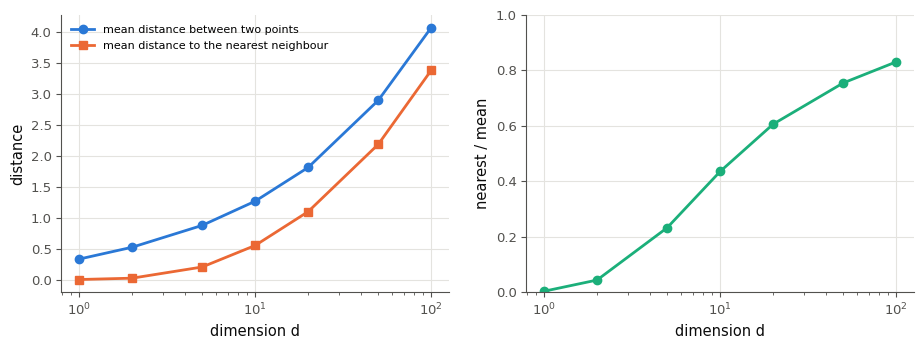

your predictions: a) True   b) True   c) 0.8


In [47]:
mean_grows_19, nn_grows_19, ratio_19 = True, True, 0.8     # the answers, for the record
DIMS_19 = [1, 2, 5, 10, 20, 50, 100]
rng_19 = np.random.default_rng(719)
nearest_19, mean_19 = [], []
for d in DIMS_19:
    points_19 = rng_19.random((500, d))                       # 500 points, uniform in the cube [0, 1]^d
    D_19 = pdist(points_19)                                   # the distances of the 124 750 pairs
    square_19 = np.full((500, 500), np.inf)
    square_19[np.triu_indices(500, k=1)] = D_19
    square_19 = np.minimum(square_19, square_19.T)            # symmetric, with inf on the diagonal
    nearest_19.append(square_19.min(axis=1).mean())
    mean_19.append(D_19.mean())
print(pd.DataFrame({"d": DIMS_19, "nearest neighbour": nearest_19, "mean distance": mean_19,
                    "ratio": np.array(nearest_19) / np.array(mean_19)}).round(3).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(DIMS_19, mean_19, "o-", label="mean distance between two points")
axes[0].plot(DIMS_19, nearest_19, "s-", label="mean distance to the nearest neighbour")
axes[0].set(xscale="log", xlabel="dimension d", ylabel="distance")
axes[0].legend(fontsize=8)
axes[1].plot(DIMS_19, np.array(nearest_19) / np.array(mean_19), "o-", color="C2")
axes[1].set(xscale="log", xlabel="dimension d", ylabel="nearest / mean", ylim=(0, 1))
plt.show()
print(f"your predictions: a) {mean_grows_19}   b) {nn_grows_19}   c) {ratio_19}")

💡 Les deux distances grandissent (a et b : `True`), mais pas au même rythme. La distance moyenne grandit à peu près comme $\sqrt{d/6}$ ; la distance au plus proche voisin, minuscule en dimension 1, la rattrape : dès la dimension 10, l'écart entre les deux reste d'environ 0,7, alors que la moyenne continue de grandir. Leur rapport monte donc de 0,003 en dimension 1 à environ 0,8 en dimension 100 (c). Avec 500 points, le plus proche voisin n'est plus « proche » : il est presque aussi loin que n'importe quel autre point. C'est la concentration des distances (fiche §7.6.1), mesurée en 7.20.

### Ex 7.20 — Densité, plus proche voisin et concentration des distances 🔬 ★★ ⏱️ 30 min
**Objectif :** mesurer la densité d'échantillons et la concentration des distances quand la dimension grandit, et comparer avec des données réelles.  
**Prérequis :** Ex 7.19 · ✏️ 7.4 · Ex 7.13 · Ex 2.25 (contraste) · fiche §7.6, §7.6.1 · **Fil rouge :** synthétique/MNIST · **Parcours :** M, C

Trois mesures de la malédiction de la dimension, avec tes fonctions.

a) écris `occupied_cells_20(X, bins)` : le nombre de cases **non vides** quand chaque axe de $[0, 1]^d$ est découpé en `bins` cases égales. Le numéro de case d'une coordonnée $x$ est la partie entière de $x \times$ `bins` (`np.floor`), sans dépasser `bins - 1` ; une case est une ligne de numéros, et `np.unique(..., axis=0)` garde les lignes distinctes. La vérification tire 1 000 points dans $[0, 1]^8$ et compte les cases occupées en dimension 1 à 8, avec 4 cases par axe ; elle vérifie les valeurs en dimension 5 et 8 ;
b) `expected_20` : avec la formule de ✏️ 7.4, le nombre **moyen** de cases occupées par 1 000 points en dimension 5, avec 4 cases par axe (2 décimales) ;
c) écris `nn_and_mean_20(X)` : le couple (distance moyenne de chaque point à son plus proche voisin, distance moyenne entre deux points distincts), avec ta `pairwise_sq_distances` (7.13) et une racine carrée. L'identité laisse sur la diagonale de minuscules valeurs au lieu de 0 : mets-la à 0 (`np.fill_diagonal`), puis écarte-la des minimums et des moyennes, car un point n'est pas son propre voisin. La vérification calcule le rapport des deux en dimension 2, 10, 50 et 200, pour 500 points uniformes, et vérifie celui de la dimension 50 ;
d) écris `contrast_20(X)` : la moyenne, sur tous les points, du contraste de 2.25, $\frac{d_{\max} - d_{\min}}{d_{\min}}$ (plus grande et plus petite distance du point aux **autres** points). La vérification le compare pour 500 points uniformes de $[0, 1]^{784}$ et pour 500 images de MNIST, qui ont aussi 784 pixels.

Dans tes notes : en a), à partir de quelle dimension la plupart des cases sont-elles vides ? Que dit le rapport de c) sur un classifieur des plus proches voisins ? Pourquoi les images de MNIST gardent-elles un contraste bien plus grand que des points uniformes (fiche, bénédiction de la structure) ?

In [48]:
def occupied_cells_20(X, bins):
    """Number of non-empty cells when each axis of [0, 1]^d is cut into `bins` equal cells."""
    cells = np.minimum(np.floor(np.asarray(X) * bins).astype(int), bins - 1)   # a coordinate 1.0 goes to the last cell
    return len(np.unique(cells, axis=0))


def _distances_20(X):
    """Euclidean distances between all the rows of X, with mylearn (Ex 7.13)."""
    D = np.sqrt(mylearn.cluster.pairwise_sq_distances(X, X))
    np.fill_diagonal(D, 0.0)
    return D


def nn_and_mean_20(X):
    """(mean distance from each point to its nearest neighbour, mean distance between two distinct points)."""
    D = _distances_20(X)
    off_diagonal = ~np.eye(len(X), dtype=bool)
    return float(np.where(off_diagonal, D, np.inf).min(axis=1).mean()), float(D[off_diagonal].mean())


def contrast_20(X):
    """Mean over the points of (d_max - d_min) / d_min, the contrast of Ex 2.25 seen from every point."""
    D = _distances_20(X)
    off_diagonal = ~np.eye(len(X), dtype=bool)
    d_min = np.where(off_diagonal, D, np.inf).min(axis=1)
    d_max = np.where(off_diagonal, D, -np.inf).max(axis=1)
    return float(np.mean((d_max - d_min) / d_min))


m_20 = 4 ** 5
expected_20 = m_20 * (1 - (1 - 1 / m_20) ** 1000)           # Ex 7.4: each cell is empty with probability (1 - 1/m)^n
print("expected number of occupied cells in dimension 5:", round(expected_20, 2))
U_20 = np.random.default_rng(720).random((1000, 8))         # 1000 points, uniform in [0, 1]^8
cells_20 = [occupied_cells_20(U_20[:, :d], 4) for d in range(1, 9)]
print(pd.DataFrame({"d": range(1, 9), "cells": [4 ** d for d in range(1, 9)], "occupied": cells_20,
                    "density n / 4^d": [round(1000 / 4 ** d, 4) for d in range(1, 9)]}).to_string(index=False))
rng_20 = np.random.default_rng(7201)
ratios_20 = {}
for d in [2, 10, 50, 200]:
    nn_20, mean_20 = nn_and_mean_20(rng_20.random((500, d)))
    ratios_20[d] = nn_20 / mean_20
print("nearest / mean:", {d: round(float(r), 3) for d, r in ratios_20.items()})
digits_20, _ = wb.datasets.load_mnist("train", n=500, flatten=True, normalize=True, seed=0)
random_20 = np.random.default_rng(7202).random((500, 784))
contrasts_20 = [contrast_20(random_20), contrast_20(digits_20.astype(float))]
print(f"contrast: uniform points in [0, 1]^784 {contrasts_20[0]:.3f} · MNIST {contrasts_20[1]:.3f}")

expected number of occupied cells in dimension 5: 638.54
 d  cells  occupied  density n / 4^d
 1      4         4         250.0000
 2     16        16          62.5000
 3     64        64          15.6250
 4    256       248           3.9062
 5   1024       641           0.9766
 6   4096       882           0.2441
 7  16384       973           0.0610
 8  65536       990           0.0153
nearest / mean: {2: 0.043, 10: 0.438, 50: 0.752, 200: 0.879}


contrast: uniform points in [0, 1]^784 0.125 · MNIST 1.637


In [49]:
wb.record("7.20a", [cells_20[4], cells_20[7]], mistakes={"ce sont les nombres de cases (4^d), pas les cases occupées": [4 ** 5, 4 ** 8]})
wb.record("7.20b", expected_20, decimals=2, mistakes={
    "c'est le nombre moyen de cases VIDES : prends le complément": m_20 * (1 - 1 / m_20) ** 1000,
    "c'est la densité 1000 / 4^5 : on demande un nombre de cases occupées": 1000 / m_20,
    "c'est l'approximation m (1 - e^(-n/m)) : utilise la formule exacte de ✏️ 7.4 g), m (1 - (1 - 1/m)^n)": m_20 * (1 - np.exp(-1000 / m_20))})
wb.record("7.20c", ratios_20[50], decimals=4, mistakes={
    "c'est le rapport inverse : plus proche voisin / moyenne": 1 / ratios_20[50],
    "ta moyenne compte la diagonale (la distance de chaque point à lui-même, 0) : écarte-la": ratios_20[50] * 500 / 499,
    "le plus proche voisin d'un point n'est pas lui-même : écarte la diagonale avant de chercher le minimum": 0.0})
wb.record("7.20d", contrasts_20, decimals=4, mistakes={"l'ordre est [points uniformes, MNIST]": contrasts_20[::-1]})

WB_ANSWER {"decimals": 0, "element_hashes": ["e8a50e400611827d985cdd0f735f6ee8066d1a8e038f0a88ea7ef715581c0b86", "2df4fce49f2a6538ee403df61d25c42fdf5c23679b0cf9e003d303b41e53b512"], "hash": "52846d7ef20b3cb464b3d6e66403748dcb75990c4c721557817eb2d0fa0cfece", "id": "7.20a", "integer": true, "kind": "array", "mistakes": {"63b0b4788d6cf4fe70b76631c2ed534172570ebb27518bef5865d0e94d189b61": "ce sont les nombres de cases (4^d), pas les cases occupées"}, "shape": [2]}
📝 Ex 7.20a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "5b835207560d856c8f284bedf4a0df04d0ad847bb43dfc3dc35a667c72811d3c", "hash_coarse": "6ff6a7ddbdcf7ab8bf0306cdcff28ded16c03d61559e50bd251dcc2566ef71d3", "id": "7.20b", "kind": "float", "magnitude": 2, "mistakes": {"40919117b75a7196d27e41562f9e29d2863c5683caea55851b0964203e578264": "c'est l'approximation m (1 - e^(-n/m)) : utilise la formule exacte de ✏️ 7.4 g), m (1 - (1 - 1/m)^n)", "59e1f1765099f4c2788b199f717bf69abffc2007440808b814d10b5063c

💡 En dimension 5, 641 des 1 024 cases sont occupées (la formule de 7.4 en prévoit 638,54) ; en dimension 8, 990 sur 65 536 : presque chaque point est seul dans sa case, et 98 % des cases sont vides. La plupart des cases sont vides dès la dimension 6 (882 occupées sur 4 096). Le rapport plus proche voisin / distance moyenne vaut 0,04 en dimension 2 et 0,75 en dimension 50 : un classifieur des plus proches voisins décide alors d'après des points presque aussi éloignés que les autres. Le contraste tombe à 0,12 pour des points uniformes en dimension 784, mais reste à 1,64 pour MNIST : les images vivent près d'une « surface » de faible dimension (fiche, hypothèse de la variété), et leurs distances gardent un sens. C'est ce qui permet au ch. 13 de classer MNIST par plus proches voisins.

### Ex 7.21 — Reproduire les figures 7.27 et 7.30 (boule/cube, hyper-orange) 🎨 ★★ ⏱️ 25 min
**Objectif :** tracer les vraies valeurs de deux figures du livre et les confirmer par une simulation.  
**Prérequis :** ∂ 7.5 · ∂ 7.6 · fiche §7.6.1 (encadrés 🧮 et ⚠️ sur la figure 7.27) · **Fil rouge :** synthétique · **Parcours :** M, C

a) écris `ball_ratio_21(d_max)`, qui renvoie le tableau des rapports $q_d = \frac{V_d}{2^d}$ pour $d = 1, \ldots, d_{\max}$, par la récurrence de ∂ 7.6 ($V_1 = 2$, $V_2 = \pi$, $V_d = \frac{2\pi}{d} V_{d-2}$) ;
b) écris `orange_radius_21(d)`, le rayon de l'hyper-orange de ∂ 7.5, pour un nombre ou un tableau de dimensions.

La vérification trace les deux figures, et ajoute à la première une estimation de **Monte-Carlo** : la part de 200 000 points tirés uniformément dans le cube $[-1, 1]^d$ qui tombent dans la boule de rayon 1 (méthode de 3.12). Elle vérifie ensuite tes valeurs.

Dans tes notes : compare tes courbes aux figures 7.27 et 7.30 du livre (encadré ⚠️ de la fiche). Combien des 200 000 points tomberaient en moyenne dans la boule en dimension 15, puis 20 ? Que vaudrait alors l'estimation de Monte-Carlo ?

✅ Ex 7.21 : ball_ratio_21 donne les valeurs exactes (1, π/4, π/6, π²/32…).
✅ Ex 7.21 : orange_radius_21 est juste pour d = 1 à 20.


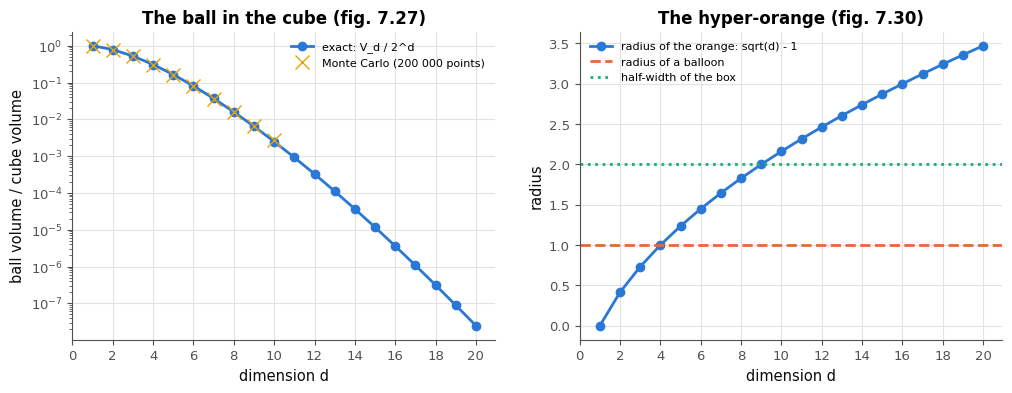

✅ Ex 7.21 : les points de Monte-Carlo tombent sur la courbe exacte.


In [50]:
def ball_ratio_21(d_max):
    """The ratios V_d / 2^d for d = 1, ..., d_max (an array of length d_max)."""
    volumes = {1: 2.0, 2: np.pi}
    for d in range(3, d_max + 1):
        volumes[d] = 2 * np.pi / d * volumes[d - 2]
    return np.array([volumes[d] / 2 ** d for d in range(1, d_max + 1)])


def orange_radius_21(d):
    """The radius of the hyper-orange in dimension d (a number or an array of dimensions)."""
    return np.sqrt(d) - 1


if True:
    dims_21 = np.arange(1, 21)
    q_21, r_21 = ball_ratio_21(20), orange_radius_21(dims_21)
    if returned("7.21", "ball_ratio_21", q_21) and returned("7.21", "orange_radius_21", r_21):
        q_21, r_21 = np.asarray(q_21, dtype=float), np.asarray(r_21, dtype=float)
        exact_21 = [np.pi / 4, np.pi / 6, np.pi ** 2 / 32]
        verdict("7.21", q_21.shape == (20,) and np.allclose(q_21[1:4], exact_21) and abs(q_21[0] - 1) < 1e-12,
                "ball_ratio_21 donne les valeurs exactes (1, π/4, π/6, π²/32…).",
                "ball_ratio_21(20) doit renvoyer 20 rapports V_d / 2^d, de d = 1 à 20 (1, puis π/4 ≈ 0,785…).")
        verdict("7.21", r_21.shape == (20,) and np.allclose(r_21, np.sqrt(dims_21) - 1),
                "orange_radius_21 est juste pour d = 1 à 20.",
                "orange_radius_21(d) doit valoir √d − 1, pour un tableau de dimensions aussi.")
        if q_21.shape == (20,) and r_21.shape == (20,):
            rng_21 = np.random.default_rng(721)
            monte_carlo_21 = [np.mean((rng_21.uniform(-1, 1, (200_000, d)) ** 2).sum(axis=1) <= 1) for d in range(1, 11)]
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].semilogy(dims_21, q_21, "o-", label="exact: V_d / 2^d")
            axes[0].semilogy(range(1, 11), monte_carlo_21, "x", ms=10, color="C3", label="Monte Carlo (200 000 points)")
            axes[0].set(xlabel="dimension d", ylabel="ball volume / cube volume", xticks=range(0, 21, 2),
                        title="The ball in the cube (fig. 7.27)")
            axes[0].legend(fontsize=8)
            axes[1].plot(dims_21, r_21, "o-", label="radius of the orange: sqrt(d) - 1")
            axes[1].axhline(1, color="C1", ls="--", label="radius of a balloon")
            axes[1].axhline(2, color="C2", ls=":", lw=2, label="half-width of the box")
            axes[1].set(xlabel="dimension d", ylabel="radius", xticks=range(0, 21, 2), title="The hyper-orange (fig. 7.30)")
            axes[1].legend(fontsize=8)
            plt.show()
            verdict("7.21", max(abs(m - q) for m, q in zip(monte_carlo_21, q_21[:10])) < 0.01,
                    "les points de Monte-Carlo tombent sur la courbe exacte.",
                    "les points de Monte-Carlo s'écartent de ta courbe : relis la récurrence de ∂ 7.6.")

💡 Les valeurs exactes de $q_d$ (1 ; 0,785 ; 0,524 ; 0,308 ; 0,164…) passent au-dessus des points de la figure 7.27 du livre, et la simulation tombe sur la courbe exacte. En dimension 15, $q_{15} \approx 1{,}2 \times 10^{-5}$ : sur 200 000 points, on en attend 2,3 en moyenne dans la boule, et le compte varie beaucoup d'un tirage à l'autre (aucun point environ une fois sur dix, 5 ou plus presque aussi souvent). En dimension 20, $q_{20} \approx 2{,}5 \times 10^{-8}$ : on n'en attend aucun (0,005 en moyenne), et l'estimation vaut presque toujours 0. Pour estimer une proportion $p$ minuscule, il faut bien plus de $\frac{1}{p}$ points : c'est une autre face de la malédiction de la dimension. Le rayon de l'orange atteint celui d'un ballon en dimension 4 et la demi-largeur de la boîte en dimension 9.

## Partie C · Un-contre-tous et un-contre-un génériques dans mylearn.multiclass

Fiche §7.4. Tu écris `mylearn.multiclass` : deux **méta-estimateurs**, qui transforment n'importe quel classifieur binaire en classifieur multi-classe, puis tu compares les trois stratégies sur des données réelles. Ces classes resserviront avec le perceptron (ch. 10) et les SVM (ch. 13). Les exercices réutilisent les quatre classes de 7.16 (`X_16`, `y_16`, `X_test_16`, `y_test_16`) : exécute d'abord les cellules de données des parties A et B. La cellule ci-dessous prépare l'exemple des docstrings.

In [51]:
X_DOC = np.array([[0.0, 0.0], [0.0, 1.0], [5.0, 0.0], [5.0, 1.0], [0.0, 5.0], [1.0, 5.0]])   # the docstring examples
Y_DOC = np.array([0, 0, 1, 1, 2, 2])
X_NEW_DOC = np.array([[0.5, 0.5], [5.0, 0.5], [0.5, 5.0]])
print("the four classes of Ex 7.16:", X_16.shape, "training points,", X_test_16.shape, "test points")

the four classes of Ex 7.16: (400, 2) training points, (1200, 2) test points


### Ex 7.22 — Un-contre-tous générique : OneVsRestClassifier 🔨 ★★★ ⏱️ 40 min
**Objectif :** écrire un méta-estimateur qui entraîne une copie d'un classifieur binaire par classe.  
**Prérequis :** Ex 7.14 · ✏️ 7.1 · 0A (classes ; alias et copies, §100.3.1 et §100.8.2) · fiche §7.4.1 · **Fil rouge :** synthétique · **mylearn :** `multiclass.py` · **Parcours :** C

> **mylearn** : ouvre `mon_travail/mylearn/multiclass.py` (créé par `python tools/start_chapter.py 7`). Mêmes règles qu'en 7.13 : NumPy et le module `copy` de Python sont permis ; les classes de `sklearn.multiclass` sont les **oracles** des tests. Enregistre, puis relance la cellule de vérification.

Écris la classe `OneVsRestClassifier` (lis ses docstrings). C'est un **méta-estimateur** : il reçoit un classifieur binaire **non entraîné**, `estimator`, et en entraîne une copie par classe.
- `fit(X, y)` : `classes_` est le tableau trié des labels distincts (`np.unique`). Lève une `ValueError` s'il y a moins de 3 classes (avec deux classes, on utilise directement le classifieur binaire), ou si `estimator` n'a ni `decision_function` ni `predict_proba` (`hasattr`). Puis, pour chaque classe `c` de `classes_`, une copie `copy.deepcopy(self.estimator)` (module `copy` : une copie indépendante de l'objet et de tout ce qu'il contient, si bien qu'entraîner la copie ne touche pas l'original) apprend les labels `(y == c).astype(int)` : 1 pour la classe `c`, 0 pour toutes les autres. `estimators_` garde ces modèles dans l'ordre de `classes_`. `estimator` lui-même n'est jamais entraîné ;
- `decision_function(X)` : une colonne par modèle, son `decision_function(X)`, ou la colonne 1 de son `predict_proba(X)` s'il n'a pas de `decision_function` ;
- `predict(X)` : la classe de la plus grande colonne (`np.argmax` garde la première en cas d'égalité) ;
- `score(X, y)` : l'accuracy, un `float`.

La vérification reprend l'exemple de la docstring, puis les quatre classes de 7.16 :
a) l'accuracy de ton un-contre-tous, autour de ton `NearestCentroid`, sur les points de test ;
elle vérifie ensuite qu'il donne les mêmes prédictions que le calcul fait à la main en 7.16, et lance les tests, qui comparent ta classe à `sklearn.multiclass.OneVsRestClassifier` autour d'autres classifieurs binaires de scikit-learn (`LinearSVC`, `LogisticRegression`, `GaussianNB` : tu les rencontreras au ch. 13).

Dans tes notes : pourquoi copier l'estimateur ? Que donnerait `self.estimators_.append(self.estimator.fit(X, labels))` à chaque tour de boucle (indice : `fit` renvoie `self`) ? Pourquoi faut-il un score, et pas seulement `predict` ?

In [52]:
ovr_22 = mylearn.multiclass.OneVsRestClassifier(mylearn.cluster.NearestCentroid()).fit(X_16, y_16)
print(len(ovr_22.estimators_), "binary models, for the classes", ovr_22.classes_.tolist())
print("decision_function of the first two test points:\n", ovr_22.decision_function(X_test_16[:2]).round(3))
print("a) accuracy of the one-versus-rest on the test points:", ovr_22.score(X_test_16, y_test_16))
run_mylearn_tests("multiclass", "test_one_vs_rest_", impl="ref")

4 binary models, for the classes ['A', 'B', 'C', 'D']
decision_function of the first two test points:
 [[ 33.02  -10.666 -78.447  -1.568]
 [ 52.523 -56.353 -53.055  -0.776]]
a) accuracy of the one-versus-rest on the test points: 0.885


pytest: 14 passed, 13 deselected in 1.17s


In [53]:
wb.record("7.22a", ovr_22.score(X_test_16, y_test_16), decimals=4, mistakes={
    "c'est l'accuracy du centroïde le plus proche multi-classe : on demande celle de l'un-contre-tous": mylearn.cluster.NearestCentroid().fit(X_16, y_16).score(X_test_16, y_test_16)})

WB_ANSWER {"decimals": 4, "hash": "7ea5f7f3e1a98ef771060d1ca272221bc2b7b8ba44bbaa5f9473c1569e9cee95", "hash_coarse": "727f1784c3a7123e877821aca93117329fd8b2af925dfc57d3de195147e17d77", "id": "7.22a", "kind": "float", "magnitude": -1, "mistakes": {"863e940c0379158d323b91425b80bbc795c37b91e80d4340979f719f6c4b14f9": "c'est l'accuracy du centroïde le plus proche multi-classe : on demande celle de l'un-contre-tous"}, "sign": 1}
📝 Ex 7.22a : réponse enregistrée (float, 4 décimale(s)).


💡 Accuracy de 0,885 : les prédictions de 7.16, D sacrifiée. Sans copie, la boucle entraînerait **le même** objet quatre fois : comme `fit` renvoie `self`, la liste contiendrait quatre fois ce même modèle, entraîné en dernier (« D contre le reste »). Les quatre colonnes de `decision_function` seraient identiques, et `argmax` choisirait toujours la première classe. Le score sert à départager : plusieurs modèles peuvent répondre « oui » pour un même point (ou aucun), et seul un score dit lequel est le plus sûr. La référence est dans `solutions/mylearn_ref/multiclass.py`.

### Ex 7.23 — Un-contre-un générique : OneVsOneClassifier 🔨 ★★★ ⏱️ 45 min
**Objectif :** écrire le méta-estimateur des duels et de leurs votes, et comprendre ce qu'il fait des centroïdes.  
**Prérequis :** Ex 7.22 · ✏️ 7.2 · fiche §7.4.2 · **Fil rouge :** synthétique · **mylearn :** `multiclass.py` · **Parcours :** C

> **mylearn** : toujours dans `mon_travail/mylearn/multiclass.py`, mêmes règles qu'en 7.22.

Écris la classe `OneVsOneClassifier` (lis ses docstrings) :
- `fit(X, y)` : `classes_` comme en 7.22 (une `ValueError` s'il y a moins de 3 classes) ; `pairs_` est la liste des couples d'**indices** de classes `(i, j)` avec `i < j`, dans l'ordre (0, 1), (0, 2)… (1, 2)… ; pour chaque couple, une copie de l'estimateur apprend sur les **seuls** échantillons des classes `classes_[i]` et `classes_[j]` (dans l'ordre que tu veux), avec le label 1 pour la classe `j` et 0 pour la classe `i` ; `estimators_[m]` est le modèle du couple `pairs_[m]` ;
- `votes(X)` : un tableau d'**entiers** de forme (n, K) ; chaque modèle donne une voix à la classe `j` de son couple quand son `predict` vaut 1, à la classe `i` sinon. Chaque ligne totalise donc $\frac{K(K-1)}{2}$ voix ;
- `predict(X)` : la classe qui a le plus de voix (`np.argmax` : en cas d'égalité, le plus petit indice) ;
- `score(X, y)` : l'accuracy.

La vérification reprend l'exemple de la docstring, puis les quatre classes de 7.16 :
a) les voix des cinq premiers points de test (`votes`, un tableau de forme (5, 4)) ;
b) l'accuracy de ton un-contre-un sur les points de test ;
elle compare ensuite tes prédictions à celles du centroïde le plus proche multi-classe, dessine les régions de l'un-contre-tous et de l'un-contre-un, et lance les tests.

Dans tes notes : avec des centroïdes, l'un-contre-un donne **exactement** les prédictions du centroïde le plus proche multi-classe. Pourquoi ? Combien de voix reçoit toujours la classe prédite ? Pourquoi la classe sacrifiée en 7.16 ne l'est-elle plus ? Dans `votes`, pourquoi parler d'indices de classes plutôt que de labels ?

pairs_ of the four classes: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
a) votes of the first five test points (columns A, B, C, D):
 [[3 1 0 2]
 [3 0 1 2]
 [3 1 0 2]
 [3 0 1 2]
 [3 0 1 2]]
b) accuracy of the one-versus-one on the test points: 0.915
same predictions as the multi-class nearest centroid: True


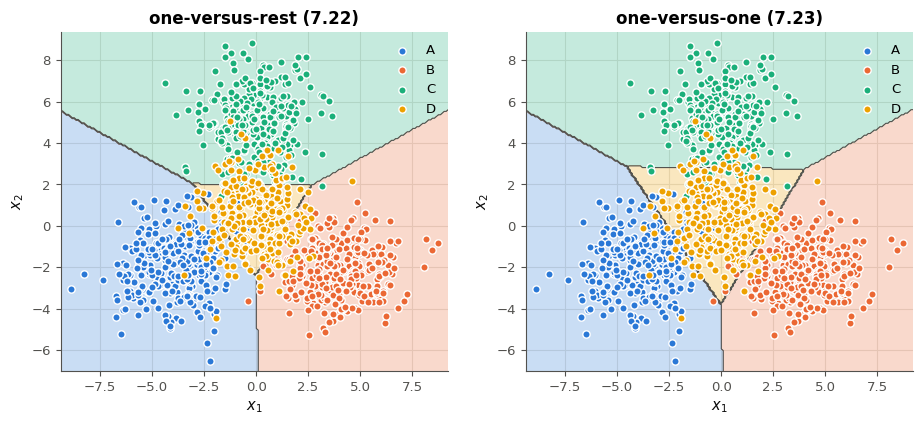

pytest: 13 passed, 14 deselected in 1.45s


In [54]:
ovo_23 = mylearn.multiclass.OneVsOneClassifier(mylearn.cluster.NearestCentroid()).fit(X_16, y_16)
print("pairs_ of the four classes:", ovo_23.pairs_)
print("a) votes of the first five test points (columns A, B, C, D):\n", ovo_23.votes(X_test_16[:5]))
print("b) accuracy of the one-versus-one on the test points:", ovo_23.score(X_test_16, y_test_16))
native_23 = mylearn.cluster.NearestCentroid().fit(X_16, y_16)
print("same predictions as the multi-class nearest centroid:",
      np.array_equal(ovo_23.predict(X_test_16), native_23.predict(X_test_16)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (title, model) in zip(axes, [("one-versus-rest (7.22)", ovr_22), ("one-versus-one (7.23)", ovo_23)]):
    wb.plot.plot_decision_boundary(model, X_test_16, y_test_16, ax=ax, class_names=list(np.unique(y_16)))
    ax.set_title(title)
plt.show()
run_mylearn_tests("multiclass", "test_one_vs_one_", impl="ref")

In [55]:
wb.record("7.23a", ovo_23.votes(X_test_16[:5]), mistakes={
    "c'est le nombre de duels PERDUS : une voix va au gagnant de chaque duel": 3 - ovo_23.votes(X_test_16[:5])})
wb.record("7.23b", ovo_23.score(X_test_16, y_test_16), decimals=4, mistakes={
    "c'est l'accuracy de l'un-contre-tous (7.22) : on demande celle de l'un-contre-un": ovr_22.score(X_test_16, y_test_16)})

WB_ANSWER {"decimals": 0, "element_hashes": ["8116136cc0f6e42385c3156fa49898f0bd2e6c7cdd9db5529a45debe8df0fb3a", "d8a829d31c3a1107e75cd88e0cd9a3731bd5d2f7e7740dfdc29d39c47addef42", "5445fe56d6211b171bbb41cc2b942d91cfd19768388a2bcded7c11188d2bb701", "c220b479be2b059f721a70c3de37690dd574ca163875599cfacab9c76312e25a", "7d9d22b307fa397bc436234566fb56ee1c96faa803a90cd5b49ba0c49b34e7ab", "be87a24694e09df1caa09a74342f80a4be8079fea374966e8bb337155e2984f0", "8d7fcaca1e2e2a68322ac1d2b443c006645e0d72b9ee12ca1a5322d248b57056", "f7ba6ca2e813aca54ad45ca59e860465c97db2c534024d803b828edba25096cd", "ff9a7f1133f365085b80579a3a84df8e2b8a7bde4530cf8a1f5032da9cba2189", "6655dc96cc21f61de4516a5b0b14366f56641b5fa02d047cd5d8e31c8161618c", "67124edf88807e881251ace9bd72f3b52345b0ee8cc8d8a219f9382b3ccb6177", "f4af1e393bb5047e379ff40ad732f9d6b8c424c58a8738fa166764fa9390b3a8", "5967bcdc53a731c69edec1f892a832064669c745331e0564c892a0674c98b92c", "90dbacd99dc4edcade2eac22bdd00a44043ed3af52611de2cacf9cf4a2e912d2", "3e

💡 Les cinq premiers points de test sont des A : la classe A reçoit 3 voix sur 6, toutes celles de ses duels. Accuracy de 0,915, celle du centroïde le plus proche multi-classe. Le duel « $i$ contre $j$ » compare les distances aux centroïdes de $i$ et de $j$ : la classe du centroïde le plus proche gagne ses $K - 1$ duels, et reçoit $K - 1 = 3$ voix ; toute autre classe perd au moins son duel contre elle. Chaque duel n'utilise que les deux classes concernées : il n'y a plus de centroïde de « tout le reste », et D n'est plus sacrifiée. `classes_` peut contenir des chaînes (`"A"`) : `votes` range les voix par indice de colonne, `predict` traduit ensuite l'indice gagnant en label.

### Ex 7.24 — OvR, OvO ou multi-classe natif : accuracy, nombre de modèles, temps 🔬 ★★★ ⏱️ 35 min
**Objectif :** comparer les trois stratégies sur deux jeux réels, et relier le coût d'entraînement à la taille des données.  
**Prérequis :** Ex 7.22 · Ex 7.23 · ✏️ 7.1 · ch. 1 (jeux d'entraînement et de test) · fiche §7.3 et §7.4 · **Fil rouge :** Penguins/MNIST · **Parcours :** C

On compare trois façons de traiter plusieurs classes avec **ton** `NearestCentroid` : le modèle multi-classe natif, l'un-contre-tous (7.22) et l'un-contre-un (7.23). Deux jeux réels : les manchots (3 espèces, 4 mesures ; 233 pour l'entraînement, `TRAIN_PENG`, et 100 pour le test, `TEST_PENG`, le découpage du ch. 1) et MNIST (10 chiffres, 784 pixels ; 10 000 images pour l'entraînement, 2 000 pour le test).

a) `Z_train_24`, `Z_test_24` : les mesures des manchots d'entraînement et de test, standardisées avec la moyenne et l'écart-type (`ddof=0`) des manchots d'**entraînement** seulement. Le jeu de test ne doit rien apprendre au modèle, pas même sa moyenne (ch. 1, et le ch. 8 y reviendra) ;
b) écris `compare_24(X_train, y_train, X_test, y_test)`, qui renvoie un `DataFrame` de trois lignes, dont l'**index** (le nom des lignes) est `"native"`, `"OvR"` et `"OvO"`, et quatre colonnes : `n_models` (le nombre de modèles entraînés : 1 pour le modèle natif, `len(model.estimators_)` pour les deux autres), `accuracy` (sur le jeu de test), `fit_s` et `predict_s` (les durées de `fit` et de `predict`, en secondes, mesurées avec `time.perf_counter()`).

La vérification lance `compare_24` sur les manchots et sur MNIST, puis affiche le recall de chaque espèce de manchot avec les trois stratégies.

Dans tes notes : combien de modèles pour $K$ classes avec chaque stratégie (✏️ 7.1) ? Sur MNIST, l'un-contre-un entraîne 45 modèles et l'un-contre-tous 10 : pourquoi l'un-contre-un ne met-il pas 4,5 fois plus de temps à s'entraîner ? (compte les lignes que voit chaque modèle) Qu'est-ce qui coûte, à la prédiction ? Quelle espèce l'un-contre-tous sacrifie-t-il, et pourquoi (7.16) ? Quand préférer l'un-contre-un (fiche §7.4.2) ?

In [56]:
X_mnist_24, y_mnist_24 = wb.datasets.load_mnist("train", n=10_000, flatten=True, normalize=True, seed=0)
X_mnist_test_24, y_mnist_test_24 = wb.datasets.load_mnist("test", n=2_000, flatten=True, normalize=True, seed=0)


def table_problem_24(table):
    """'' when compare_24 returned the DataFrame of the statement, otherwise what is wrong with it."""
    if table is None:
        return "compare_24 renvoie None : as-tu oublié le return ?"
    if not isinstance(table, pd.DataFrame):
        return f"compare_24 doit renvoyer un DataFrame, pas un objet de type {type(table).__name__}."
    if not {"native", "OvR", "OvO"} <= set(table.index):
        return f"l'index (les noms des lignes) doit être native, OvR, OvO ; j'obtiens {list(table.index)}."
    if not {"n_models", "accuracy", "fit_s", "predict_s"} <= set(table.columns):
        return f"les colonnes doivent être n_models, accuracy, fit_s, predict_s ; j'obtiens {list(table.columns)}."
    return ""

print("MNIST:", X_mnist_24.shape, X_mnist_test_24.shape, "· penguins:", len(TRAIN_PENG), "for training,",
      len(TEST_PENG), "for the test")

MNIST: (10000, 784) (2000, 784) · penguins: 233 for training, 100 for the test


In [57]:
mean_train_24, std_train_24 = X_peng[TRAIN_PENG].mean(axis=0), X_peng[TRAIN_PENG].std(axis=0)
Z_train_24 = (X_peng[TRAIN_PENG] - mean_train_24) / std_train_24
Z_test_24 = (X_peng[TEST_PENG] - mean_train_24) / std_train_24


def compare_24(X_train, y_train, X_test, y_test):
    """DataFrame, one row per strategy ("native", "OvR", "OvO"), columns n_models, accuracy, fit_s, predict_s."""
    rows = {}
    for name, model in [("native", mylearn.cluster.NearestCentroid()),
                        ("OvR", mylearn.multiclass.OneVsRestClassifier(mylearn.cluster.NearestCentroid())),
                        ("OvO", mylearn.multiclass.OneVsOneClassifier(mylearn.cluster.NearestCentroid()))]:
        start = time.perf_counter()
        model.fit(X_train, y_train)
        fitted = time.perf_counter()
        predicted = model.predict(X_test)
        done = time.perf_counter()
        rows[name] = {"n_models": len(getattr(model, "estimators_", [model])),
                      "accuracy": float(np.mean(predicted == np.asarray(y_test))),
                      "fit_s": fitted - start, "predict_s": done - fitted}
    return pd.DataFrame.from_dict(rows, orient="index")      # one row per strategy, n_models stays an integer


if True:
    tables_24 = {}
    if filled(Z_train_24, Z_test_24):
        mean_24, std_24 = X_peng[TRAIN_PENG].mean(axis=0), X_peng[TRAIN_PENG].std(axis=0)
        verdict("7.24", np.shape(Z_train_24) == (len(TRAIN_PENG), 4) and np.shape(Z_test_24) == (len(TEST_PENG), 4)
                and np.allclose(Z_train_24, (X_peng[TRAIN_PENG] - mean_24) / std_24)
                and np.allclose(Z_test_24, (X_peng[TEST_PENG] - mean_24) / std_24),
                "a) les deux tableaux sont standardisés avec la moyenne et l'écart-type des manchots d'entraînement.",
                "a) standardise X_peng[TRAIN_PENG] et X_peng[TEST_PENG] avec la moyenne et l'écart-type (ddof=0) des "
                "manchots d'ENTRAÎNEMENT seulement.")
        tables_24["penguins"] = compare_24(Z_train_24, species[TRAIN_PENG], Z_test_24, species[TEST_PENG])
    else:
        print("⏳ Ex 7.24 : remplis Z_train_24 et Z_test_24 (question a) pour comparer aussi les manchots.")
    tables_24["MNIST"] = compare_24(X_mnist_24, y_mnist_24, X_mnist_test_24, y_mnist_test_24)
    problems_24 = [table_problem_24(table) for table in tables_24.values()]
    if any(problems_24):
        print("❌ Ex 7.24 :", next(problem for problem in problems_24 if problem))
    else:
        for name, table in tables_24.items():
            print(f"--- {name}\n{table.round(4)}")
        expected_24 = {"penguins": [1, 3, 3], "MNIST": [1, 10, 45]}
        verdict("7.24", all(list(t.loc[["native", "OvR", "OvO"], "n_models"]) == expected_24[name]
                            for name, t in tables_24.items()),
                "le bon nombre de modèles : 1, K et K(K - 1)/2.",
                "n_models doit valoir 1 pour le modèle natif, len(model.estimators_) pour les deux autres.")
        verdict("7.24", all(t.loc["OvO", "accuracy"] == t.loc["native", "accuracy"] for t in tables_24.values()),
                "l'un-contre-un a exactement l'accuracy du modèle natif (7.23).",
                "l'un-contre-un avec des centroïdes devrait avoir l'accuracy du modèle natif (7.23) : relis compare_24, "
                "puis ton OneVsOneClassifier.")
    if "penguins" in tables_24:
        recalls_24 = {}
        for name, model in [("native", mylearn.cluster.NearestCentroid()),
                            ("OvR", mylearn.multiclass.OneVsRestClassifier(mylearn.cluster.NearestCentroid())),
                            ("OvO", mylearn.multiclass.OneVsOneClassifier(mylearn.cluster.NearestCentroid()))]:
            predicted = np.asarray(fitted(model, Z_train_24, species[TRAIN_PENG]).predict(Z_test_24))
            recalls_24[name] = {s: np.mean(predicted[species[TEST_PENG] == s] == s) for s in np.unique(species)}
        print("--- recall of each species of penguin (100 test penguins)\n", pd.DataFrame(recalls_24).T.round(3))

✅ Ex 7.24 : a) les deux tableaux sont standardisés avec la moyenne et l'écart-type des manchots d'entraînement.


--- penguins
        n_models  accuracy   fit_s  predict_s
native         1      0.98  0.0002     0.0001
OvR            3      0.95  0.0004     0.0001
OvO            3      0.98  0.0008     0.0002
--- MNIST
        n_models  accuracy   fit_s  predict_s
native         1    0.8295  0.0368     0.0110
OvR           10    0.8290  0.5039     0.0825
OvO           45    0.8295  0.2993     0.3142
✅ Ex 7.24 : le bon nombre de modèles : 1, K et K(K - 1)/2.
✅ Ex 7.24 : l'un-contre-un a exactement l'accuracy du modèle natif (7.23).
--- recall of each species of penguin (100 test penguins)
         Adelie  Chinstrap  Gentoo
native   0.975      0.947     1.0
OvR      1.000      0.737     1.0
OvO      0.975      0.947     1.0


💡 Manchots : 1, 3 et 3 modèles ; accuracy de 0,98 pour le modèle natif et l'un-contre-un, de 0,95 pour l'un-contre-tous, qui sacrifie les Chinstrap (recall 0,74 au lieu de 0,95). Comme D en 7.16, ils sont « au milieu » : leur bec long les rapproche des Gentoo, leur bec épais et leur petite taille des Adélie, si bien que le centroïde de « tout sauf Chinstrap » tombe près du leur. MNIST : 1, 10 et 45 modèles ; les trois accuracies sont presque égales (0,83). L'un-contre-un entraîne 4,5 fois plus de modèles, mais chacun ne voit que deux chiffres, environ 2 000 images : il voit en tout $(K - 1)\,n$ lignes, contre $K\,n$ pour l'un-contre-tous, et ne coûte donc pas plus cher ici. Avec un algorithme dont le coût croît plus vite que $n$ (un SVM à noyau, ch. 13), l'un-contre-un devient même le moins cher : c'est pourquoi `SVC` de scikit-learn l'utilise. À la prédiction, chaque modèle coûte : 45 duels coûtent plus que 10 scores, et bien plus qu'un seul modèle natif. Les durées varient d'une machine et d'une exécution à l'autre : compare leurs ordres de grandeur.

## Partie D · k-means de zéro, silhouette, choix de k, phénomène de Hughes, défi

Fiche §7.5 (Lloyd, k-means++, « Combien de clusters ? ») et §7.6. Tu écris k-means dans `mylearn.cluster` : l'initialisation k-means++, puis la classe `KMeans` ; tu débusques les bugs d'un k-means écrit par un collègue, tu programmes la silhouette, tu choisis $k$ sans labels, tu mesures le phénomène de Hughes, et tu relèves le défi des manchots. La cellule ci-dessous standardise les 333 manchots de la partie B.

In [58]:
Z_peng = (X_peng - X_peng.mean(axis=0)) / X_peng.std(axis=0)   # the 333 penguins, standardised (as in 7.17 c)
years = penguins["year"].to_numpy()
print(Z_peng.shape, {int(year): int(count) for year, count in zip(*np.unique(years, return_counts=True))})

(333, 4) {2007: 103, 2008: 113, 2009: 117}


### Ex 7.25 — Initialisation k-means++ 🔨 ★★★ ⏱️ 35 min
**Objectif :** programmer le tirage pondéré de k-means++ et mesurer ce qu'il apporte face à des centres tirés au hasard.  
**Prérequis :** Ex 7.13 · ✏️ 7.3 · ch. 2 (générateur aléatoire) · fiche §7.5 (encadré 🧮 sur k-means++) · **Fil rouge :** synthétique · **mylearn :** `cluster.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/cluster.py`, mêmes règles qu'en 7.13 (NumPy permis, SciPy et scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `kmeans_plusplus(X, n_clusters, rng=None)` (lis sa docstring), la version d'origine de k-means++ (fiche, encadré 🧮) :
- convertis `X` en tableau de flottants à deux dimensions ; lève une `ValueError` si `n_clusters` n'est pas entre 1 et le nombre de lignes **distinctes** de `X` (`len(np.unique(X, axis=0))`) ; si `rng` vaut `None`, prends `np.random.default_rng()` ;
- le premier centre est une ligne tirée uniformément (`rng.integers(len(X))`) ;
- garde à jour le tableau des $D(\mathbf{x})^2$, le carré de la distance de chaque point au centre déjà choisi le plus proche : après chaque nouveau centre, `np.minimum` avec les carrés des distances à ce centre ;
- chaque centre suivant est la ligne d'indice `rng.choice(len(X), p=d2 / d2.sum())` ;
- renvoie les lignes choisies, dans l'ordre du tirage : `X[indices]`, avec la liste des indices tirés (l'indexation par une liste crée une copie).

La vérification tire 300 fois six centres sur les six paquets ci-dessous, avec ton k-means++ et avec six lignes tirées au hasard. Elle compte les paquets qui reçoivent au moins un centre, puis lance l'algorithme de Lloyd (le `KMeans` de scikit-learn, depuis ces centres) et compte les départs qui mènent au meilleur découpage connu. Elle lance enfin les tests, qui vérifient tes tirages par un test du khi-deux.

Dans tes notes : pourquoi des lignes tirées au hasard laissent-elles souvent des paquets sans centre ? Que fait l'algorithme de Lloyd d'un paquet sans centre de départ ? Pourquoi un point déjà choisi ne peut-il pas être tiré une seconde fois ?

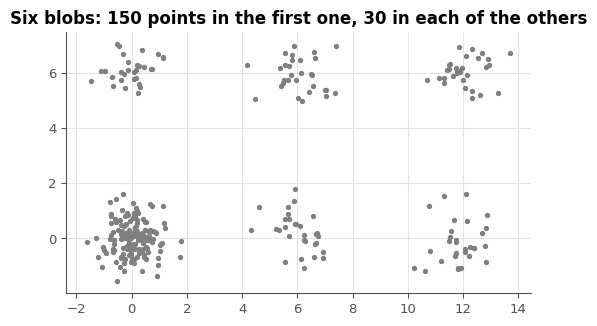

In [59]:
BLOB_CENTRES_25 = np.array([[0.0, 0.0], [6.0, 0.0], [12.0, 0.0], [0.0, 6.0], [6.0, 6.0], [12.0, 6.0]])
BLOB_SIZES_25 = [150, 30, 30, 30, 30, 30]                     # one big blob and five small ones
rng_25 = np.random.default_rng(725)
X_25 = np.vstack([rng_25.normal(centre, 0.6, (size, 2)) for centre, size in zip(BLOB_CENTRES_25, BLOB_SIZES_25)])
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.scatter(X_25[:, 0], X_25[:, 1], s=8, color="gray")
ax.set(title="Six blobs: 150 points in the first one, 30 in each of the others", aspect="equal")
plt.show()

docstring example: [[10.1, 0.0], [0.0, 0.0]]


             blobs covered (mean)  all 6 blobs covered  \
k-means++                   5.407                0.453   
random rows                 3.303                0.000   

             best partition after Lloyd  
k-means++                         0.637  
random rows                       0.150  
✅ Ex 7.25 : k-means++ couvre en moyenne bien plus de paquets que des points tirés au hasard.


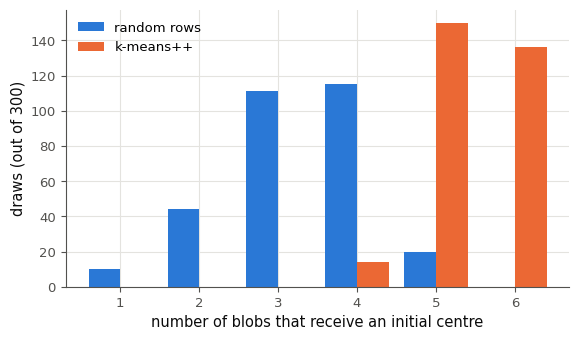

pytest: 10 passed, 79 deselected in 1.89s


In [60]:
if True:
    X_doc_25 = np.array([[0.0, 0.0], [0.1, 0.0], [10.0, 0.0], [10.1, 0.0]])
    doc_25 = mylearn.cluster.kmeans_plusplus(X_doc_25, 2, rng=np.random.default_rng(0))
    if returned("7.25", "kmeans_plusplus", doc_25) and np.shape(doc_25) != (2, 2):
        print(f"❌ Ex 7.25 : kmeans_plusplus doit renvoyer les lignes de X choisies, un tableau de forme "
              f"(n_clusters, n_features) ; sur l'exemple de la docstring, j'attends (2, 2), j'obtiens {np.shape(doc_25)}.")
    elif doc_25 is not None:
        print("docstring example:", np.asarray(doc_25).tolist())
        best_25 = SklearnKMeans(n_clusters=6, n_init=50, random_state=0).fit(X_25).inertia_   # the best partition known
        rng_draws_25 = np.random.default_rng(7250)
        covered_25 = {"k-means++": [], "random rows": []}
        best_found_25 = {"k-means++": [], "random rows": []}
        with threadpool_limits(limits=1):                  # 600 tiny fits: one thread each is faster
            for _ in range(300):
                starts = {"k-means++": np.asarray(mylearn.cluster.kmeans_plusplus(X_25, 6, rng=rng_draws_25), dtype=float),
                          "random rows": X_25[rng_draws_25.choice(len(X_25), size=6, replace=False)]}
                for name, centres in starts.items():
                    blobs = ((centres[:, None, :] - BLOB_CENTRES_25[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)
                    covered_25[name].append(len(np.unique(blobs)))
                    lloyd = SklearnKMeans(n_clusters=6, init=centres, n_init=1).fit(X_25)   # Lloyd from this start
                    best_found_25[name].append(lloyd.inertia_ <= best_25 * 1.001)
        table_25 = pd.DataFrame({name: {"blobs covered (mean)": np.mean(covered_25[name]),
                                        "all 6 blobs covered": np.mean(np.array(covered_25[name]) == 6),
                                        "best partition after Lloyd": np.mean(best_found_25[name])}
                                 for name in covered_25}).T
        print(table_25.round(3))
        verdict("7.25", table_25.loc["k-means++", "blobs covered (mean)"]
                >= table_25.loc["random rows", "blobs covered (mean)"] + 1,
                "k-means++ couvre en moyenne bien plus de paquets que des points tirés au hasard.",
                "ton k-means++ ne couvre pas plus de paquets que le hasard : chaque nouveau centre doit être tiré avec "
                "une probabilité proportionnelle à D(x)², le carré de la distance au centre déjà choisi le plus proche.")
        fig, ax = plt.subplots(figsize=(6.5, 3.6))
        ax.hist([covered_25["random rows"], covered_25["k-means++"]], bins=np.arange(0.5, 7.5),
                label=["random rows", "k-means++"])
        ax.set(xlabel="number of blobs that receive an initial centre", ylabel="draws (out of 300)")
        ax.legend()
        plt.show()
    run_mylearn_tests("cluster", "test_kmeans_plusplus_", impl="ref")

💡 Avec des lignes tirées au hasard, la moitié des centres tombe dans le gros paquet : seuls 3,3 paquets reçoivent un centre en moyenne, jamais les six, et Lloyd ne trouve le meilleur découpage qu'une fois sur sept environ. Avec k-means++, 5,4 paquets en moyenne, les six près d'une fois sur deux, et le meilleur découpage près de deux fois sur trois. Lloyd ne déplace un centre que vers les points qui le rejoignent : un paquet sans centre de départ ne s'en voit attribuer un que si un centre voisin est « libéré », ce qui arrive rarement. Un point déjà choisi a $D = 0$, donc une probabilité nulle. Les nombres exacts dépendent de l'ordre dans lequel ton code consomme le générateur : ils varient un peu d'une version correcte à l'autre (scikit-learn ajoute en plus des essais locaux, fiche 🕰️).

### Ex 7.26 — k-means de Lloyd : la classe KMeans 🔨 ★★★★ ⏱️ 120 min
**Objectif :** écrire un k-means complet : plusieurs départs, l'algorithme de Lloyd et sa règle d'arrêt, les attributs appris.  
**Prérequis :** ✏️ 7.3 · Ex 7.13 · Ex 7.25 · fiche §7.5 (encadré 🧮 sur l'algorithme de Lloyd) · **Fil rouge :** synthétique · **mylearn :** `cluster.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/cluster.py`, mêmes règles qu'en 7.13 (NumPy permis, SciPy et scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris la classe `KMeans` (lis ses docstrings ; `__init__` est fourni). Le plus long est `fit(X, y=None)` :
- convertis `X` (deux dimensions, flottants) et valide les hyperparamètres : `ValueError` si `n_clusters` n'est pas un entier entre 1 et le nombre de lignes, si `n_init < 1`, si `max_iter < 1`, si `init` est une chaîne autre que `"k-means++"` et `"random"`, ou un tableau qui n'a pas la forme `(n_clusters, n_features)` ;
- crée **un** générateur, `rng = np.random.default_rng(self.random_state)`, utilisé par toutes les initialisations, et la tolérance absolue `tol = self.tol * np.mean(np.var(X, axis=0))` (la règle de scikit-learn) ;
- fais `n_init` **exécutions** (une seule si `init` est un tableau). Chacune part de centres initiaux : `kmeans_plusplus(X, k, rng=rng)` (7.25) pour `"k-means++"`, `X[rng.choice(n, size=k, replace=False)]` pour `"random"`, une **copie** du tableau sinon ;
- une exécution répète, au plus `max_iter` fois : (1) l'**affectation** de chaque point au centre le plus proche (`pairwise_sq_distances`) ; (2) la **mise à jour** de chaque centre, moyenne de ses points (un centre que personne n'a rejoint ne bouge pas), et le déplacement total des centres, la somme des carrés de leurs déplacements ; puis elle s'arrête si l'affectation est identique à celle de l'itération précédente, ou si le déplacement total est inférieur ou égal à `tol`. `n_iter_` est le nombre d'itérations faites, la dernière comprise. Si l'arrêt ne vient pas d'une affectation inchangée, recalcule l'affectation avec les centres finaux ;
- l'inertie d'une exécution est la somme des carrés des distances de chaque point à son centre ; garde l'exécution d'inertie **strictement** plus faible (la première en cas d'égalité), et ses `cluster_centers_`, `labels_`, `inertia_` (un `float`) et `n_iter_` (un `int`). `fit` renvoie `self`.

Puis `predict` (le centre le plus proche), `fit_predict` (une ligne), `transform` (les distances, **sans** carré, à chaque centre) et `score` (moins l'inertie de `X` par rapport aux centres appris).

La vérification reprend l'exemple de la docstring, puis lance ton `KMeans` sur les manchots standardisés, à partir du premier Adélie, du premier Chinstrap et du premier Gentoo du tableau. Elle vérifie :
a) l'inertie finale ;
b) le nombre d'itérations ;
puis compare ton résultat au `KMeans` de scikit-learn (même départ, `n_init=1`, `algorithm="lloyd"`), relance ton `KMeans` avec k-means++ et 10 exécutions, et lance les tests.

Dans tes notes : pourquoi l'inertie ne peut-elle pas augmenter d'une itération à l'autre (fiche, encadré 🧮) ? Pourquoi un **seul** générateur pour toutes les exécutions, et pas `np.random.default_rng(self.random_state)` à chaque exécution ?

In [61]:
INIT_26 = Z_peng[[0, 265, 146]]                         # the first Adelie, Chinstrap and Gentoo of the table
km_26 = mylearn.cluster.KMeans(n_clusters=3, init=INIT_26).fit(Z_peng)
print("a) inertia:", km_26.inertia_, "· b) iterations:", km_26.n_iter_)
sk_26 = SklearnKMeans(n_clusters=3, init=INIT_26, n_init=1, algorithm="lloyd").fit(Z_peng)
print("scikit-learn: same labels", np.array_equal(km_26.labels_, sk_26.labels_), "· same centres",
      np.allclose(km_26.cluster_centers_, sk_26.cluster_centers_), "· n_iter_", sk_26.n_iter_)
km10_26 = mylearn.cluster.KMeans(n_clusters=3, random_state=0).fit(Z_peng)   # k-means++ and 10 runs
print("with k-means++ and 10 runs: inertia", round(km10_26.inertia_, 4))
print(pd.crosstab(km10_26.labels_, species, rownames=["cluster"], colnames=["species"]))
run_mylearn_tests("cluster", "test_kmeans_ and not plusplus", impl="ref")

a) inertia: 370.7702482112261 · b) iterations: 5
scikit-learn: same labels True · same centres True · n_iter_ 5
with k-means++ and 10 runs: inertia 370.7661
species  Adelie  Chinstrap  Gentoo
cluster                           
0           124          5       0
1             0          0     119
2            22         63       0


pytest: 30 passed, 59 deselected in 1.31s


In [62]:
wb.record("7.26a", km_26.inertia_, decimals=4, mistakes={
    "c'est la racine de l'inertie : l'inertie est la somme des CARRÉS des distances": float(np.sqrt(km_26.inertia_))})
wb.record("7.26b", km_26.n_iter_, mistakes={
    "tu ne comptes pas la dernière itération, celle qui constate que l'affectation ne change plus": km_26.n_iter_ - 1})

ℹ️ Ex 7.26a : valeur à une limite d'arrondi ; les deux arrondis sont acceptés.
WB_ANSWER {"alt_hashes": ["abe2066a6f9a8151ef94344128e737ddcba8aa7b40e0e167880f556bb7598764"], "decimals": 4, "hash": "720ca68e73b7b6d7a0dd23f0ca331302398bc4f01d554906a5e6265649dc20d7", "hash_coarse": "470d5d192d605a16510d05b79abb69eb73a2224d166e4021e03ee7efb93edddf", "id": "7.26a", "kind": "float", "magnitude": 2, "mistakes": {"59e8a012bf5e094efd3ed80b58580b562cc0938f1b96792641fe13fc31d6efa2": "c'est la racine de l'inertie : l'inertie est la somme des CARRÉS des distances"}, "sign": 1}
📝 Ex 7.26a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"hash": "317025668def1fb59f94df5b8baab520d47386233f8664b90632cba97862d92e", "id": "7.26b", "kind": "int", "magnitude": 0, "mistakes": {"018151685679e75da1379551f80d3f4ff5ad65f9fe80b62415a974617286286d": "tu ne comptes pas la dernière itération, celle qui constate que l'affectation ne change plus"}, "sign": 1}
📝 Ex 7.26b : réponse enregistrée (int).


💡 Inertie de 370,7702 en 5 itérations, exactement comme scikit-learn. Avec k-means++ et 10 exécutions, une inertie à peine plus basse, 370,7661 : un autre minimum local, presque le même découpage (le tableau croisé est celui de 7.17 : les Gentoo à part, 22 Adélie avec les Chinstrap). L'affectation choisit pour chaque point le centre le plus proche, et la moyenne est le point qui minimise la somme des carrés des écarts : aucune étape ne peut augmenter $J$. Un générateur recréé à chaque exécution avec la même graine donnerait dix fois **le même** départ : dix exécutions identiques, pour rien.

### Ex 7.27 — k-means piégé : quatre bugs à débusquer 🐛 ★★★ ⏱️ 30 min
**Objectif :** trouver et corriger quatre bugs classiques d'un k-means, en les isolant l'un après l'autre.  
**Prérequis :** Ex 7.26 · ✏️ 7.3 · 0A (copies et vues, réductions par axe) · **Fil rouge :** synthétique · **Parcours :** C

Un collègue a écrit son propre k-means, `kmeans_colleague_27` (cellule ci-dessous). Il contient **quatre bugs**. La cellule le lance sur les manchots standardisés, depuis les centres initiaux de 7.26, et affiche son résultat à côté de celui de scikit-learn.

Écris `kmeans_fixed_27(X, init, max_iter=100)` : la fonction du collègue, corrigée en changeant le moins de lignes possible. Elle renvoie `(centres, labels, inertia, n_iter)` et ne doit jamais modifier `init`.

La vérification isole chaque bug : elle contrôle que `init` n'est pas modifié ; elle compare tes centres après **une** itération (`max_iter=1`) aux moyennes attendues ; elle lance ta fonction sur l'exemple de la fiche (§7.5 : les points 0, 2, 3, 9, 11, 12, centres de départ 0 et 3) ; elle recalcule l'inertie avec tes centres et tes labels. Puis elle compare ta version à scikit-learn.

Dans tes notes : pour chaque bug, le symptôme qui l'a trahi, et la correction. Pourquoi le bug de la moyenne ne se voit-il pas sur l'exemple de la fiche, en dimension 1 ?

In [63]:
def kmeans_colleague_27(X, init, max_iter=100):
    """Lloyd's algorithm from the given initial centres: (centres, labels, inertia, n_iter)."""
    X = np.asarray(X, dtype=float)
    centres = init
    old_labels = None
    for n_iter in range(1, max_iter + 1):
        labels = ((X[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)   # (1) assignment
        for j in range(len(centres)):                                                     # (2) update
            if np.any(labels == j):
                centres[j] = X[labels == j].mean()
        old_labels = labels
        if np.array_equal(labels, old_labels):                    # the assignment did not change: converged
            break
    inertia = np.sqrt(((X - centres[labels]) ** 2).sum(axis=1)).sum()
    return centres, labels, inertia, n_iter


init_27 = Z_peng[[0, 265, 146]].copy()                         # the initial centres of Ex 7.26
start_27 = init_27.copy()                                      # kept aside, for scikit-learn
centres_c27, labels_c27, inertia_c27, n_iter_c27 = kmeans_colleague_27(Z_peng, init_27)
sk_27 = SklearnKMeans(n_clusters=3, init=start_27, n_init=1, algorithm="lloyd", tol=0).fit(Z_peng)
print("colleague:    inertia", round(float(inertia_c27), 3), "· n_iter", n_iter_c27, "· centres\n", centres_c27.round(3))
print("scikit-learn: inertia", round(sk_27.inertia_, 3), "· n_iter", sk_27.n_iter_, "· centres\n", sk_27.cluster_centers_.round(3))

colleague:    inertia 581.546 · n_iter 1 · centres
 [[-0.508 -0.508 -0.508 -0.508]
 [ 0.128  0.128  0.128  0.128]
 [ 0.454  0.454  0.454  0.454]]
scikit-learn: inertia 370.77 · n_iter 5 · centres
 [[-1.042  0.488 -0.875 -0.759]
 [ 0.685  0.807 -0.293 -0.386]
 [ 0.655 -1.103  1.162  1.101]]


In [64]:
def kmeans_fixed_27(X, init, max_iter=100):
    """The colleague's function, corrected: (centres, labels, inertia, n_iter); init is never modified."""
    X = np.asarray(X, dtype=float)
    centres = np.array(init, dtype=float)                      # bug 1: a COPY, in floats
    old_labels = None
    for n_iter in range(1, max_iter + 1):
        labels = ((X[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)   # (1) assignment
        for j in range(len(centres)):                                                     # (2) update
            if np.any(labels == j):
                centres[j] = X[labels == j].mean(axis=0)       # bug 2: the mean of each feature (axis=0)
        if np.array_equal(labels, old_labels):                 # bug 3: compare BEFORE remembering
            break
        old_labels = labels
    inertia = ((X - centres[labels]) ** 2).sum()               # bug 4: the sum of the SQUARED distances
    return centres, labels, inertia, n_iter


if True:
    received_27 = Z_peng[[0, 265, 146]].copy()
    kept_27 = received_27.copy()
    result_27 = kmeans_fixed_27(Z_peng, received_27)
    if returned("7.27", "kmeans_fixed_27", result_27) and (not isinstance(result_27, (tuple, list))
                                                          or len(result_27) != 4):
        print("❌ Ex 7.27 : kmeans_fixed_27 doit renvoyer quatre valeurs : (centres, labels, inertia, n_iter).")
        result_27 = None
    if result_27 is not None:
        centres_27, labels_27, inertia_27, n_iter_27 = result_27
        verdict("7.27", np.array_equal(received_27, kept_27),
                "bug 1 corrigé : les centres initiaux reçus (init) ne sont plus modifiés.",
                "bug 1 : ta fonction modifie encore le tableau init qu'elle reçoit.")
        first_27 = ((Z_peng[:, None, :] - kept_27[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)
        expected_27 = np.array([Z_peng[first_27 == j].mean(axis=0) for j in range(3)])   # after ONE iteration
        one_27 = np.asarray(kmeans_fixed_27(Z_peng, kept_27.copy(), max_iter=1)[0])
        verdict("7.27", one_27.shape == (3, 4) and np.allclose(one_27, expected_27),
                "bug 2 corrigé : après une itération, chaque centre est la moyenne de ses points, feature par feature.",
                "bug 2 : après une itération (max_iter=1), un centre n'est pas la moyenne de ses points, feature par feature.")
        line_27 = np.array([[0.0], [2.0], [3.0], [9.0], [11.0], [12.0]])         # the example of the course sheet (§7.5)
        final_27 = np.ravel(kmeans_fixed_27(line_27, np.array([[0.0], [3.0]]))[0])
        verdict("7.27", np.allclose(final_27, [5 / 3, 32 / 3]),
                "bug 3 corrigé : sur l'exemple de la fiche (0, 2, 3, 9, 11, 12), les centres arrivent à 5/3 et 32/3.",
                f"bug 3 : sur l'exemple de la fiche (0, 2, 3, 9, 11, 12, centres de départ 0 et 3), j'attends les centres "
                f"5/3 et 32/3, j'obtiens {final_27.round(3).tolist()} : l'algorithme s'arrête trop tôt.")
        verdict("7.27", np.isclose(inertia_27, ((Z_peng - np.asarray(centres_27)[labels_27]) ** 2).sum()),
                "bug 4 corrigé : l'inertie est la somme des CARRÉS des distances.",
                "bug 4 : l'inertie renvoyée n'est pas la somme des carrés des distances de chaque point à son centre.")
        verdict("7.27", np.allclose(centres_27, sk_27.cluster_centers_) and np.array_equal(labels_27, sk_27.labels_)
                and np.isclose(inertia_27, sk_27.inertia_),
                "ta version donne les centres, les labels et l'inertie de scikit-learn.",
                "ta version ne donne pas encore les centres, les labels et l'inertie de scikit-learn.")

✅ Ex 7.27 : bug 1 corrigé : les centres initiaux reçus (init) ne sont plus modifiés.
✅ Ex 7.27 : bug 2 corrigé : après une itération, chaque centre est la moyenne de ses points, feature par feature.
✅ Ex 7.27 : bug 3 corrigé : sur l'exemple de la fiche (0, 2, 3, 9, 11, 12), les centres arrivent à 5/3 et 32/3.
✅ Ex 7.27 : bug 4 corrigé : l'inertie est la somme des CARRÉS des distances.
✅ Ex 7.27 : ta version donne les centres, les labels et l'inertie de scikit-learn.


💡 Bug 1 : `centres = init` ne copie pas ; la mise à jour `centres[j] = ...` modifie le tableau de l'appelant (et, si `init` est un tableau d'entiers, tronque les moyennes) : `np.array(init, dtype=float)`. Bug 2 : `X[labels == j].mean()` fait la moyenne de **toutes** les valeurs du groupe, toutes features confondues : un seul nombre, recopié dans chaque coordonnée du centre ; il faut `mean(axis=0)`. En dimension 1, il n'y a qu'une feature : les deux calculs coïncident. Bug 3 : `old_labels = labels` avant la comparaison rend le test toujours vrai, et la boucle s'arrête après une itération ; il faut comparer, **puis** mémoriser. Bug 4 : l'inertie est la somme des carrés des distances, pas la somme des distances. Chaque test isole un bug : c'est la méthode à retenir pour déboguer (0A).

### Ex 7.28 — Coefficient de silhouette 🔨 ★★★ ⏱️ 40 min
**Objectif :** programmer la silhouette, point par point puis en moyenne, et l'utiliser pour juger un découpage.  
**Prérequis :** Ex 7.13 · fiche §7.5 (encadré 🧮 sur la silhouette) · **Fil rouge :** synthétique · **mylearn :** `cluster.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/cluster.py`, mêmes règles qu'en 7.13 (NumPy permis, SciPy et scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `silhouette_samples(X, labels)` puis `silhouette_score(X, labels)` (lis leurs docstrings et l'encadré 🧮 de la fiche) :
- valide les entrées : `ValueError` si le nombre de labels distincts n'est pas entre 2 et $n - 1$ (la silhouette n'a pas de sens avec un seul cluster, ni avec un point par cluster) ;
- calcule la matrice des distances (la racine carrée de `pairwise_sq_distances(X, X)`) et mets sa diagonale à 0 (`np.fill_diagonal`) ;
- $a(i)$ : la distance moyenne de $i$ aux **autres** points de son cluster (divise par la taille du cluster moins 1) ; $b(i)$ : la plus petite des distances moyennes de $i$ aux points de chacun des **autres** clusters ; un masque booléen par cluster suffit ;
- $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$, avec $s(i) = 0$ pour un point seul dans son cluster, et 0 (pas `nan`) quand $a(i) = b(i) = 0$ (des points confondus) ;
- `silhouette_score` est la moyenne des $s(i)$, un `float`.

La vérification reprend l'exemple de la docstring, puis calcule la silhouette des manchots standardisés, découpés par le `KMeans` de scikit-learn :
a) avec $k = 3$ ;
b) avec $k = 2$ ;
elle compare ta silhouette à celle de scikit-learn, trace la silhouette de chaque manchot pour $k = 3$, et lance les tests.

Dans tes notes : la silhouette préfère $k = 2$, alors qu'il y a trois espèces. Pourquoi ? Lis la figure : quel cluster a les silhouettes les plus basses, et quelles espèces contient-il ?

a) k = 3: 0.4462 · b) k = 2: 0.5308 · scikit-learn, k = 3: 0.4462


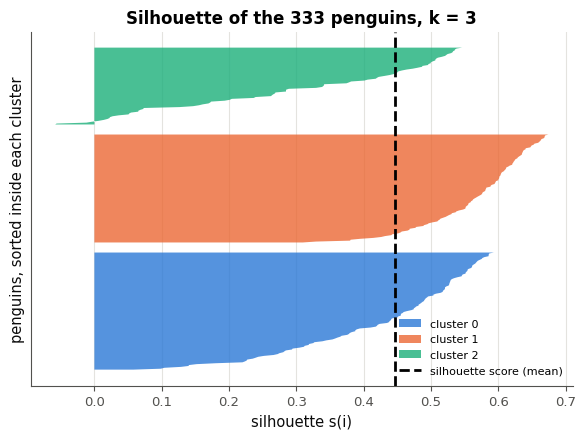

species          Adelie  Chinstrap  Gentoo
cluster (k = 3)                           
0                   124          5       0
1                     0          0     119
2                    22         63       0


pytest: 16 passed, 73 deselected in 1.03s


In [65]:
labels3_28 = SklearnKMeans(n_clusters=3, n_init=10, random_state=0).fit(Z_peng).labels_
labels2_28 = SklearnKMeans(n_clusters=2, n_init=10, random_state=0).fit(Z_peng).labels_
score3_28 = mylearn.cluster.silhouette_score(Z_peng, labels3_28)
score2_28 = mylearn.cluster.silhouette_score(Z_peng, labels2_28)
print(f"a) k = 3: {score3_28:.4f} · b) k = 2: {score2_28:.4f} · scikit-learn, k = 3: "
      f"{sklearn_silhouette_score(Z_peng, labels3_28):.4f}")
values_28 = mylearn.cluster.silhouette_samples(Z_peng, labels3_28)
fig, ax = plt.subplots(figsize=(7, 4.6))
low_28 = 0
for c in range(3):
    ranked = np.sort(values_28[labels3_28 == c])
    ax.fill_betweenx(np.arange(low_28, low_28 + len(ranked)), 0, ranked, alpha=0.8, label=f"cluster {c}")
    low_28 += len(ranked) + 10
ax.axvline(score3_28, color="black", ls="--", label="silhouette score (mean)")
ax.set(xlabel="silhouette s(i)", ylabel="penguins, sorted inside each cluster", yticks=[],
       title="Silhouette of the 333 penguins, k = 3")
ax.legend(fontsize=8)
plt.show()
print(pd.crosstab(labels3_28, species, rownames=["cluster (k = 3)"], colnames=["species"]))
run_mylearn_tests("cluster", "test_silhouette_", impl="ref")

In [66]:
def wrong_a_28(X, labels):
    """Silhouette with a(i) divided by the size of the cluster (the point itself counted): a classic slip."""
    labels = np.asarray(labels)
    D = np.sqrt(mylearn.cluster.pairwise_sq_distances(X, X))
    a = np.array([D[i, labels == labels[i]].mean() for i in range(len(X))])
    b = np.array([min(D[i, labels == c].mean() for c in set(labels.tolist()) - {labels[i]}) for i in range(len(X))])
    return float(np.mean((b - a) / np.maximum(a, b)))


wb.record("7.28a", score3_28, decimals=4, mistakes={"a(i) se divise par la taille du cluster MOINS 1 : le point ne compte pas parmi les autres": wrong_a_28(Z_peng, labels3_28)})
wb.record("7.28b", score2_28, decimals=4, mistakes={"c'est la silhouette pour k = 3 : b) porte sur k = 2": score3_28,
                                                   "a(i) se divise par la taille du cluster MOINS 1 : le point ne compte pas parmi les autres": wrong_a_28(Z_peng, labels2_28)})

WB_ANSWER {"decimals": 4, "hash": "a201b4f52f5380fb2e30b7b1d1c64c8b7520742147c44c689fa10cc879bb527d", "hash_coarse": "6a527dcfbefb453127dbc1603ea1def44f82e60414dbab9d59c3fbe659aacd98", "id": "7.28a", "kind": "float", "magnitude": -1, "mistakes": {"9ca15cfde12709109cc2e8993aa16fbd18c0d42c92fcff6517b0a87ba92c7979": "a(i) se divise par la taille du cluster MOINS 1 : le point ne compte pas parmi les autres"}, "sign": 1}
📝 Ex 7.28a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "2c0634e4c3cbce2d4c4b2d4cd3c7908bfe8837dd3fe553f68bb8e2c3b6ef8878", "hash_coarse": "013344e64b789d6e7831dd0f6034b0c925631fd261256739529488d986054a1a", "id": "7.28b", "kind": "float", "magnitude": -1, "mistakes": {"2e8af0e4576d5e64df8a3564e85d8daf1f3526c3da09aa2fa5be78a0e2353d90": "a(i) se divise par la taille du cluster MOINS 1 : le point ne compte pas parmi les autres", "45d2f06916f68483cbc1e6657086a2b48e6d912c92d45c84319266c2a28cf778": "c'est la silhouette pour k = 3 : b) porte sur 

💡 Silhouette de 0,4462 pour $k = 3$ et de 0,5308 pour $k = 2$. Avec $k = 2$, k-means sépare les Gentoo de tous les autres, deux groupes très bien séparés. Avec $k = 3$, il doit couper le groupe des Adélie et des Chinstrap, qui se touchent : les points de la frontière ont des silhouettes proches de 0, voire négatives, et la moyenne baisse. La silhouette mesure une séparation géométrique, pas des espèces : elle n'a pas tort, elle répond à une autre question. Sur la figure, le cluster des Gentoo a les silhouettes les plus hautes (0,57 en moyenne) ; celui des 124 Adélie et 5 Chinstrap suit (0,43) ; celui des 63 Chinstrap et 22 Adélie a les plus basses (0,31), et les seules négatives (4 manchots).

### Ex 7.29 — Choisir k : coude de l'inertie et silhouette, de k = 2 à 7 🔬 ★★★ ⏱️ 35 min
**Objectif :** choisir un nombre de clusters sans labels avec deux critères, et voir ce qu'ils ne peuvent pas dire.  
**Prérequis :** Ex 7.26 · Ex 7.28 · fiche §7.5 (« Combien de clusters ? ») · **Fil rouge :** synthétique · **Parcours :** R, C

Les 320 points de `X_29` n'ont pas de labels. Combien de clusters faut-il demander à k-means ?

Écris `scan_29(X, ks)`, qui renvoie deux dictionnaires `{k: valeur}`, pour chaque $k$ de `ks` : l'inertie de `mylearn.cluster.KMeans(n_clusters=k, n_init=10, random_state=0)` entraîné sur `X`, et la silhouette de ses labels (`mylearn.cluster.silhouette_score`). La vérification l'appelle pour $k$ de 2 à 7 (`K_29`) et contrôle :
a) l'inertie pour $k = 3$ ;
b) la silhouette pour $k = 3$ ;
c) la silhouette pour $k = 4$ ;
puis elle affiche le tableau et trace les deux courbes. Lis-les, puis réponds :
d) `best_k_29` : le $k$ de la plus grande silhouette (un entier) ;
e) `elbow_k_29` : le $k$ du coude, lu sur la courbe de l'inertie : le point après lequel elle ne baisse plus que lentement (un entier).

Dans tes notes : combien de paquets vois-tu sur la figure des données ? Lis la cellule qui les fabrique : combien le générateur en a-t-il utilisé ? Que disent les deux critères, et pourquoi ? Si un client te demandait quatre groupes, lui dirais-tu non ?

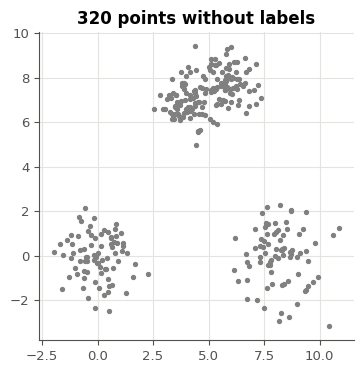

In [67]:
rng_29 = np.random.default_rng(729)
BLOBS_29 = [((0.0, 0.0), 1.0), ((8.0, 0.0), 1.0), ((4.0, 7.0), 0.7), ((5.8, 7.8), 0.7)]   # (centre, standard deviation)
X_29 = np.vstack([rng_29.normal(centre, spread, (80, 2)) for centre, spread in BLOBS_29])
K_29 = range(2, 8)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_29[:, 0], X_29[:, 1], s=8, color="gray")
ax.set(title="320 points without labels", aspect="equal")
plt.show()

     inertia  silhouette
2  3326.0183      0.5989
3   637.7045      0.7765
4   463.6504      0.6300
5   378.6180      0.5496
6   327.6670      0.4369
7   295.3617      0.4143


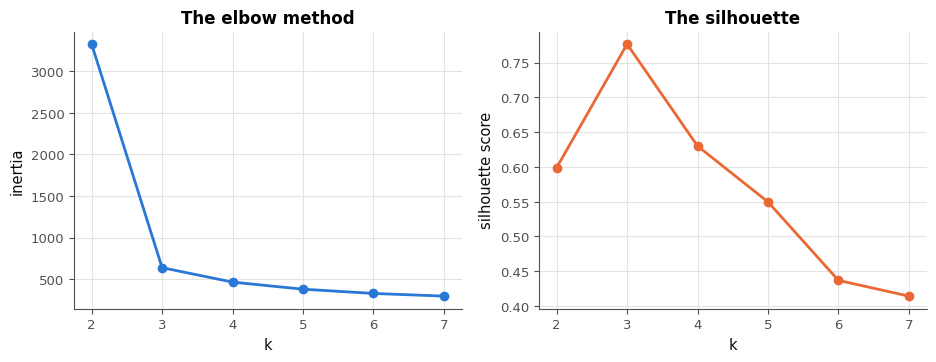

In [68]:
def scan_29(X, ks):
    """({k: inertia_}, {k: silhouette score}) of mylearn's KMeans(n_clusters=k, n_init=10, random_state=0) on X."""
    inertias, silhouettes = {}, {}
    for k in ks:
        model = mylearn.cluster.KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
        inertias[k] = model.inertia_
        silhouettes[k] = mylearn.cluster.silhouette_score(X, model.labels_)
    return inertias, silhouettes


inertias_29, silhouettes_29 = scan_29(X_29, K_29)
print(pd.DataFrame({"inertia": inertias_29, "silhouette": silhouettes_29}).round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(list(K_29), [inertias_29[k] for k in K_29], "o-")
axes[0].set(xlabel="k", ylabel="inertia", title="The elbow method")
axes[1].plot(list(K_29), [silhouettes_29[k] for k in K_29], "o-", color="C1")
axes[1].set(xlabel="k", ylabel="silhouette score", title="The silhouette")
plt.show()

In [69]:
wb.record("7.29a", inertias_29[3], decimals=4, mistakes={"c'est l'inertie pour k = 4 : on demande k = 3": inertias_29[4]})
wb.record("7.29b", silhouettes_29[3], decimals=4, mistakes={"c'est la silhouette pour k = 4 : on demande k = 3": silhouettes_29[4]})
wb.record("7.29c", silhouettes_29[4], decimals=4, mistakes={"c'est la silhouette pour k = 3 : on demande k = 4": silhouettes_29[3]})

WB_ANSWER {"decimals": 4, "hash": "f3798019d9c1f39ca00db340eb15f1f95ab5fdccad219090a0b3044dbdddc4c0", "hash_coarse": "44a43a03c20c40f767536fc85e96096f982a84e6fa3ee31f28f2335619638f5c", "id": "7.29a", "kind": "float", "magnitude": 2, "mistakes": {"c4bb428a5a6625ca9fbfa4b4c57baf91e6c7f6def46b4fcaa45f6679a3837838": "c'est l'inertie pour k = 4 : on demande k = 3"}, "sign": 1}
📝 Ex 7.29a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "83a8455d5e1738ccd8244151f84b7dee5dce68925feaf7a800b9540f1ea38a28", "hash_coarse": "b1ba1db99659c6365eeda0bde2b27ab176b81d9e9c7b0014c752225499392990", "id": "7.29b", "kind": "float", "magnitude": -1, "mistakes": {"3ca2ff654be0b724d0cdd43ac2fd904aa1d9d8a365fd2dd89489c65771a5d0e7": "c'est la silhouette pour k = 4 : on demande k = 3"}, "sign": 1}
📝 Ex 7.29b : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "5cc40ebc8e9bb0e3973c7a54feeb31cd9ae72afcc79daa5d33ff1f99569c64b5", "hash_coarse": "8dcd8edeae4e2

Lis le tableau et les deux courbes, puis réponds à d) et e).

In [70]:
best_k_29 = max(silhouettes_29, key=silhouettes_29.get)
elbow_k_29 = 3                                        # read on the curve: the decrease slows down after k = 3
drops_29 = {k: inertias_29[k - 1] - inertias_29[k] for k in list(K_29)[1:]}
print("best silhouette for k =", best_k_29)
print("decrease of the inertia from k - 1 to k:", {k: round(v, 1) for k, v in drops_29.items()})

best silhouette for k = 3
decrease of the inertia from k - 1 to k: {3: 2688.3, 4: 174.1, 5: 85.0, 6: 51.0, 7: 32.3}


In [71]:
wb.record("7.29d", best_k_29, mistakes={
    "on cherche le k de la plus grande silhouette du tableau, pas le nombre de paquets du générateur": 4,
    "relis la colonne des silhouettes : laquelle est la plus grande ?": 2,
    "la plus grande silhouette du tableau n'est pas sur cette ligne : relis la colonne": 5,
    "relis le tableau : quelle ligne a la plus grande silhouette ?": 6,
    "c'est le k de la plus PETITE silhouette : on cherche la plus grande": min(silhouettes_29, key=silhouettes_29.get)})
wb.record("7.29e", elbow_k_29, mistakes={
    "le coude n'est pas l'inertie la plus basse : c'est le point après lequel elle ne baisse plus que lentement": 7,
    "compare les baisses successives de l'inertie (de 2 à 3, de 3 à 4…) : le coude est le dernier k atteint par une grande baisse": 4,
    "le coude est le dernier k atteint par une grande baisse : calcule de combien l'inertie baisse à chaque nouveau k": 2,
    "après le coude, l'inertie ne baisse plus que lentement : cherche le dernier k atteint par une grande baisse": 5,
    "regarde la courbe de l'inertie : le coude est le dernier k atteint par une grande baisse": 6})

WB_ANSWER {"hash": "54c131ee16c541e0003173f9a1baf7d9a785f2ae3a1beaa458794bd2c6d00f9b", "id": "7.29d", "kind": "int", "magnitude": 0, "mistakes": {"4552f7b80c10d3b74b8d11f909deedcbe3805058ed4748e9f68fd64a5258862c": "on cherche le k de la plus grande silhouette du tableau, pas le nombre de paquets du générateur", "55c0b17c784e3a79dda58211475f2e666cf04bec28bd0be8ad9ca623bb2f0caf": "relis la colonne des silhouettes : laquelle est la plus grande ?", "61b6181bf352e252fbf22d2cedf411458b3e4375328c52476d1fa31b7884c9a6": "relis le tableau : quelle ligne a la plus grande silhouette ?", "cbc3442ece3f78d068ddf8d74879d26dd2c2f567c6dddb78f0f06dccc412de93": "c'est le k de la plus PETITE silhouette : on cherche la plus grande", "f33b8631130735aa2ea792572c46360f2ebd652d4bb078a4e9a32230e0bdd05f": "la plus grande silhouette du tableau n'est pas sur cette ligne : relis la colonne"}, "sign": 1}
📝 Ex 7.29d : réponse enregistrée (int).
WB_ANSWER {"hash": "5ca21f201b2c486c92c799970ecf63a03cf0cce2b3216a73477b55

💡 Inertie de 637,705 pour $k = 3$ ; silhouette de 0,7765 pour $k = 3$, et de 0,63 pour $k = 4$. Les deux critères choisissent $k = 3$ : de 2 à 3, l'inertie baisse de 2 688, puis de 174 seulement de 3 à 4. Le générateur a pourtant utilisé **quatre** paquets, mais deux d'entre eux sont si proches qu'ils forment un seul groupe pour l'inertie, la silhouette et la plupart des critères internes : couper ce groupe en deux crée une frontière au milieu des points, ce que la silhouette pénalise. Aucun critère interne ne connaît la « vérité » : il mesure une forme. Si le besoin métier demande quatre groupes, on peut les donner ($k = 4$ reste un découpage raisonnable), en sachant que deux d'entre eux seront proches (fiche §7.5, E3).

### Ex 7.30 — Phénomène de Hughes : des features de bruit qui font chuter l'accuracy 🔬 ★★★ ⏱️ 40 min
**Objectif :** mesurer l'effet de features sans information sur deux classifieurs, et relier la baisse à la concentration des distances.  
**Prérequis :** Ex 7.14 · Ex 7.20 · ch. 1 (jeux d'entraînement et de test) · fiche §7.6 · **Fil rouge :** Penguins · **Parcours :** C

On classe les manchots (233 pour l'entraînement, 100 pour le test, le découpage du ch. 1) avec des features de plus en plus nombreuses : d'abord 1 à 4 vraies mesures (standardisées avec les manchots d'entraînement, dans l'ordre de `FEATURES`), puis les 4 mesures suivies de 2 à 1 000 features de **bruit pur**, tirées d'une loi normale, sans aucun lien avec l'espèce. `features_30(n_real, n_noise)` (fourni) renvoie ce tableau pour les 333 manchots. Deux classifieurs : ton `NearestCentroid` et le **1-plus-proche-voisin** (1-NN), qui donne à chaque point le label du point d'entraînement le plus proche.

Écris deux fonctions :
- `nn1_predict_30(X_train, y_train, X_test)` : le 1-NN, avec ta `pairwise_sq_distances` (7.13) et `argmin` ;
- `hughes_30(n_real, n_noise)`, qui renvoie la liste `[accuracy du centroïde le plus proche, accuracy du 1-NN]`, entraînés sur les lignes `TRAIN_PENG` de `features_30(n_real, n_noise)` et évalués sur les lignes `TEST_PENG`.

La vérification calcule la courbe pour toutes les configurations de `CONFIGS_30`, puis vérifie les deux accuracies dans quatre d'entre elles :
a) 2 vraies mesures ;
b) les 4 vraies mesures ;
c) les 4 mesures et 100 features de bruit ;
d) les 4 mesures et 1 000 features de bruit ;
et trace la courbe.

Dans tes notes : où est le sommet de la courbe ? Pourquoi le 1-NN s'effondre-t-il bien plus vite que le centroïde le plus proche ? (pense à la moyenne des features de bruit sur les dizaines de manchots d'une classe, puis à 7.20) « Plus de features, c'est toujours mieux » : vrai ou faux ?

In [72]:
mean_30, std_30 = X_peng[TRAIN_PENG].mean(axis=0), X_peng[TRAIN_PENG].std(axis=0)
Z_30 = (X_peng - mean_30) / std_30                             # standardised with the training penguins only
NOISE_30 = np.random.default_rng(730).normal(size=(len(X_peng), 1000))   # 1000 features of pure noise
CONFIGS_30 = [(1, 0), (2, 0), (3, 0), (4, 0), (4, 2), (4, 5), (4, 10), (4, 20), (4, 50), (4, 100), (4, 200), (4, 500),
              (4, 1000)]                                       # (number of real features, number of noise features)


def features_30(n_real, n_noise):
    """The first n_real measurements (standardised), then n_noise features of noise, for the 333 penguins."""
    return np.hstack([Z_30[:, :n_real], NOISE_30[:, :n_noise]])

 real  noise  features  nearest centroid  1-NN
    1      0         1              0.70  0.67
    2      0         2              0.95  0.94
    3      0         3              0.98  0.99
    4      0         4              0.98  0.99
    4      2         6              0.98  0.99
    4      5         9              0.96  0.96
    4     10        14              0.96  0.91
    4     20        24              0.94  0.81
    4     50        54              0.92  0.68
    4    100       104              0.86  0.62
    4    200       204              0.89  0.53
    4    500       504              0.77  0.51
    4   1000      1004              0.71  0.49


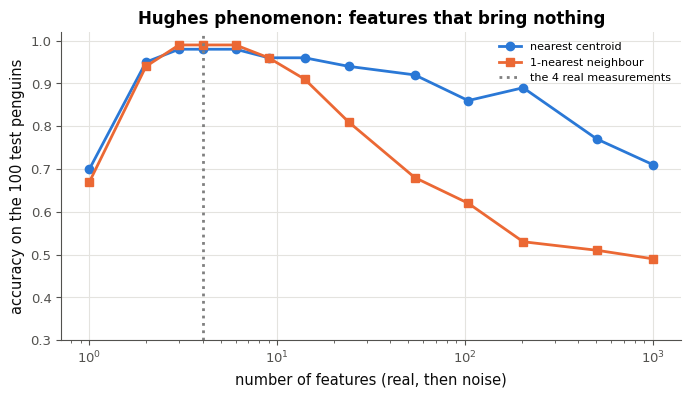

In [73]:
def nn1_predict_30(X_train, y_train, X_test):
    """1-nearest neighbour: for every row of X_test, the label of the closest row of X_train."""
    nearest = mylearn.cluster.pairwise_sq_distances(X_test, X_train).argmin(axis=1)
    return np.asarray(y_train)[nearest]


def hughes_30(n_real, n_noise):
    """[accuracy of NearestCentroid, accuracy of the 1-NN] on TEST_PENG, trained on TRAIN_PENG of features_30(...)."""
    F = features_30(n_real, n_noise)
    y_train, y_test = species[TRAIN_PENG], species[TEST_PENG]
    nc = mylearn.cluster.NearestCentroid().fit(F[TRAIN_PENG], y_train).score(F[TEST_PENG], y_test)
    nn = float(np.mean(nn1_predict_30(F[TRAIN_PENG], y_train, F[TEST_PENG]) == y_test))
    return [nc, nn]


curve_30 = {config: hughes_30(*config) for config in CONFIGS_30}
print(pd.DataFrame([[r, m, r + m, *curve_30[(r, m)]] for r, m in CONFIGS_30],
                   columns=["real", "noise", "features", "nearest centroid", "1-NN"]).to_string(index=False))
total_30 = [r + m for r, m in CONFIGS_30]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(total_30, [curve_30[c][0] for c in CONFIGS_30], "o-", label="nearest centroid")
ax.plot(total_30, [curve_30[c][1] for c in CONFIGS_30], "s-", label="1-nearest neighbour")
ax.axvline(4, color="gray", ls=":", label="the 4 real measurements")
ax.set(xscale="log", xlabel="number of features (real, then noise)", ylabel="accuracy on the 100 test penguins",
       ylim=(0.3, 1.02), title="Hughes phenomenon: features that bring nothing")
ax.legend(fontsize=8)
plt.show()

In [74]:
wb.record("7.30a", curve_30[(2, 0)], decimals=4, mistakes={"l'ordre est [centroïde le plus proche, 1-NN]": curve_30[(2, 0)][::-1]})
wb.record("7.30b", curve_30[(4, 0)], decimals=4, mistakes={"l'ordre est [centroïde le plus proche, 1-NN]": curve_30[(4, 0)][::-1]})
wb.record("7.30c", curve_30[(4, 100)], decimals=4, mistakes={"l'ordre est [centroïde le plus proche, 1-NN]": curve_30[(4, 100)][::-1]})
wb.record("7.30d", curve_30[(4, 1000)], decimals=4, mistakes={"l'ordre est [centroïde le plus proche, 1-NN]": curve_30[(4, 1000)][::-1]})

WB_ANSWER {"decimals": 4, "element_coarse": [["aa4c5611258ae00dac8e8c09d339754ccea38723edb81245b7af3d873e4b0853"], ["ed707239cf4a587283c6bb5436ee8d21608ad29eb680ac21a5bef9418141e436"]], "element_hashes": ["4317fc588eab0fe7cba8f49b10f49c2b0e293f307bd7054733c60168fd55f12f", "c4b8168e45ac28914f1b848aacc11a6ead7f4b7243311029126b8f3132f00f11"], "hash": "c3e746110757bc7bde9965c647ab8b2738e9504e44f229da1048fa99281db689", "id": "7.30a", "kind": "array", "mistakes": {"e07d04ea6c3ff3c33cde5cdd67d41ea136887600953165300f971ae0941caa1d": "l'ordre est [centroïde le plus proche, 1-NN]"}, "shape": [2]}
📝 Ex 7.30a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["dc31ab9eed5bebff283c862bab4819ddee4e2cce1551fe1531646cf20eca2085"], ["63028c5042446de09f5ee72e9ce8e57e5723efafe917446b44b6f7e18c1f72c4"]], "element_hashes": ["82f0f392bff1eaa59fa63062b3a24673fcdb0e4769bcccdf783452cdbb7c993a", "f74c4e59451c609b8dee3e9d43e4e7f1f681b6522aa5f4152cc736cb662c2ef2"], "hash":

💡 Le sommet est à 3 ou 4 vraies mesures (0,98 et 0,99), puis tout baisse : avec 100 features de bruit, 0,86 et 0,62 ; avec 1 000, 0,71 et 0,49. Une feature de bruit n'apporte rien, mais elle ajoute sa part aux distances. Pour le centroïde le plus proche, la coordonnée de bruit d'un centroïde est une moyenne sur les manchots d'entraînement de sa classe (de 49 à 106), donc proche de 0 : le bruit ajoute à peu près la même quantité aux distances vers les trois centroïdes, et la vraie différence ne se noie que lentement. « À peu près » : cette moyenne est d'autant moins proche de 0 que la classe est petite. Avec 1 000 features de bruit, le centroïde des 49 Chinstrap en garde la plus grande part, et le classifieur ne prédit presque plus « Chinstrap » (6 fois sur 100, pour 2 bonnes réponses sur 19). Pour le 1-NN, chaque point d'entraînement a son propre bruit, aussi grand que le signal : les distances se concentrent (7.20), et le plus proche voisin devient un manchot quelconque. Plus de features n'est donc pas toujours mieux, à nombre d'exemples fixé : c'est le phénomène de Hughes (fiche §7.6). Le ch. 12 apprendra à choisir ou à réduire les features.

### Ex 7.31 — Défi : retrouver les espèces de manchots sans labels 🏆 ★★★ ⏱️ 60 min
**Objectif :** trouver une représentation des données qui fait apparaître les espèces dans les clusters de k-means, et qui tient sur des données qu'elle n'a pas vues.  
**Prérequis :** Ex 7.17 · Ex 7.26 · ch. 2 (corrélation) · fiche §7.5 et §7.6 · **Fil rouge :** Penguins · **Parcours :** C

En 7.17 c), k-means sur les quatre mesures standardisées n'atteint pas une pureté de 0,95. Fais mieux, **sans** les espèces. Les règles :
- tu écris `cluster_31(X)`, qui reçoit les **4 mesures brutes** de manchots (un tableau de forme (n, 4), colonnes dans l'ordre de `FEATURES`) et renvoie un label de cluster par manchot ;
- le clustering lui-même est fait par **ton** `mylearn.cluster.KMeans`, avec `n_clusters=3` ; avant, tu peux choisir, combiner, transformer ou pondérer les mesures comme tu veux ;
- tes choix ne regardent jamais les espèces (ni le sexe, ni l'île) : pas de seuil réglé à la main sur les labels. Ta fonction recalcule ses statistiques (moyennes, écarts-types…) sur le `X` qu'elle reçoit ;
- `grade_31` (fourni) lance ta fonction sur les 333 manchots, puis sur les manchots de chaque année **séparément** (2007, 2008, 2009 : une centaine chacune), et calcule la pureté (7.17) par rapport aux espèces.

**Objectif : une pureté d'au moins 0,95 sur les 333 manchots, et d'au moins 0,90 pour chaque année.** Le point de départ fourni, celui de 7.17 avec ton `KMeans`, n'y arrive pas.

Dans tes notes : ton idée, pourquoi elle marche, et ce qu'elle suppose. Une piste : la matrice de corrélation des quatre mesures (ch. 2), et ce qui distingue un Adélie d'un Chinstrap.

In [75]:
def purity(labels, truth):
    """Purity of a clustering (Ex 7.17): each cluster takes its most frequent true class."""
    table = pd.crosstab(np.asarray(labels), np.asarray(truth))
    return float(table.max(axis=1).sum() / len(labels))


def grade_31(cluster):
    """(purities, "ok"): cluster(X) on the 333 penguins, then on each year clustered separately (X: the 4 raw
    measurements); (None, the reason) when the labels returned cannot be graded."""
    results = {}
    subsets = [("all years", np.arange(len(X_peng)))] + [(str(year), np.flatnonzero(years == year))
                                                           for year in (2007, 2008, 2009)]
    for name, rows in subsets:
        labels = cluster(X_peng[rows].copy())
        if labels is None:
            return None, "cluster_31 renvoie None : as-tu oublié le return ?"
        labels = np.asarray(labels)
        if labels.shape != (len(rows),):
            return None, (f"cluster_31 doit renvoyer un label par manchot : {len(rows)} labels attendus ({name}), "
                          f"j'obtiens un tableau de forme {labels.shape}.")
        if len(np.unique(labels)) != 3:
            return None, (f"cluster_31 doit renvoyer exactement 3 clusters ({name}) : j'en compte "
                          f"{len(np.unique(labels))}.")
        results[name] = purity(labels, species[rows])
    return results, "ok"

In [76]:
print("correlations between the 4 measurements:\n", pd.DataFrame(np.corrcoef(X_peng.T), index=FEATURES,
                                                               columns=FEATURES).round(2))
start_31, _ = grade_31(lambda X: mylearn.cluster.KMeans(n_clusters=3, n_init=10, random_state=0)
                       .fit((X - X.mean(axis=0)) / X.std(axis=0)).labels_)
print("the starting point:", {name: round(value, 3) for name, value in start_31.items()})


def cluster_31(X):
    """3 clusters of the penguins described by X (their 4 raw measurements), found by mylearn's KMeans."""
    kept = X[:, :3]                                             # the body mass repeats the flipper length (r = 0.87)
    Z = (kept - kept.mean(axis=0)) / kept.std(axis=0)
    return mylearn.cluster.KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z).labels_


if True:
    scores_31, message_31 = grade_31(cluster_31)
    if scores_31 is None:
        print("❌ Ex 7.31 :", message_31)
    else:
        print({name: round(value, 3) for name, value in scores_31.items()})
        verdict("7.31", scores_31["all years"] >= 0.95,
                f"pureté {fr(scores_31['all years'])} sur les 333 manchots : objectif 0,95 atteint.",
                f"pureté {fr(scores_31['all years'])} sur les 333 manchots : l'objectif est 0,95.")
        worst_31 = min(("2007", "2008", "2009"), key=scores_31.get)
        verdict("7.31", scores_31[worst_31] >= 0.90,
                f"pureté d'au moins 0,90 pour chaque année traitée seule (la plus basse : {worst_31}, "
                f"{fr(scores_31[worst_31])}).",
                f"pureté {fr(scores_31[worst_31])} pour les manchots de {worst_31}, traités seuls : l'objectif est "
                f"0,90 pour chaque année.")

correlations between the 4 measurements:
                    bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.23               0.65   
bill_depth_mm               -0.23           1.00              -0.58   
flipper_length_mm            0.65          -0.58               1.00   
body_mass_g                  0.59          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.59  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  
the starting point: {'all years': 0.919, '2007': 0.951, '2008': 0.885, '2009': 0.872}
{'all years': 0.97, '2007': 0.961, '2008': 0.973, '2009': 0.957}
✅ Ex 7.31 : pureté 0,970 sur les 333 manchots : objectif 0,95 atteint.
✅ Ex 7.31 : pureté d'au moins 0,90 pour chaque année traitée seule (la plus basse : 2009, 0,957).


💡 La longueur de la nageoire et la masse sont corrélées à 0,87 : elles mesurent presque la même chose, la **taille**. Standardisées toutes les deux, elles comptent deux fois dans les distances, et k-means découpe surtout selon la taille : il isole bien les Gentoo, grands, mais partage mal les Adélie et les Chinstrap, de même taille, que seul le bec distingue (long chez les Chinstrap). Sans la masse, la pureté atteint 0,970 (0,961 ; 0,973 ; 0,957 par année). Remplacer la nageoire et la masse, standardisées, par leur moyenne (une seule feature « taille ») marche aussi : environ 0,96. Ces choix supposent de savoir que la taille est redondante, ce que dit la corrélation, sans regarder les espèces. Garder les quatre mesures échoue (0,919, et 0,885 ou 0,872 certaines années) : ajouter une feature n'est pas neutre, même quand elle n'est pas du bruit (7.30).

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu choisir un seuil de décision d'après le coût des deux erreurs, et dire qui doit fixer ces coûts ?
2. Sais-tu compter et dépouiller les votes d'un un-contre-un, et dire quand le préférer à l'un-contre-tous ?
3. Sais-tu dérouler k-means à la main, et expliquer pourquoi la densité des exemples s'effondre quand on ajoute des features ?

**Pour aller plus loin** : les guides « Clustering » et « Multiclass and multioutput algorithms » de scikit-learn, cités dans la fiche. La suite : le ch. 8 (entraînement et test), où un jeu de validation fixe les seuils et les hyperparamètres comme $k$.